# Segmentation + Evaluation

2025-08-02 13:42:05 — INFO — Evaluation notebook start.
2025-08-02 13:42:05 — INFO — Installing python-dotenv (missing)
2025-08-02 13:42:06 — INFO — Installing Pillow (missing)
2025-08-02 13:42:08 — INFO — Installing google-genai (missing)
2025-08-02 13:42:09 — INFO — GenAI client initialized.
2025-08-02 13:42:09 — INFO — SLIM_ACR dataset found at D:\Projects\gemini_image_segmentation\data\SLIM_ACR
2025-08-02 13:42:09 — INFO — Starting evaluation run for model: gemini-2.5-flash-lite on SLIM_ACR dataset.
2025-08-02 13:42:09 — INFO — Loading positive case list from cache: D:\Projects\gemini_image_segmentation\data\SLIM_ACR\positive_cases_cache.txt
2025-08-02 13:42:09 — INFO — Found 2379 total positive pneumothorax cases.
2025-08-02 13:42:09 — INFO — Detailed predictions will be saved to: D:\Projects\gemini_image_segmentation\data\SLIM_ACR\predictions_gemini-2.5-flash-lite
2025-08-02 13:42:09 — INFO — Will evaluate a sample of 2379 images using up to 8 threads.
Evaluating gemini-2.5-flash
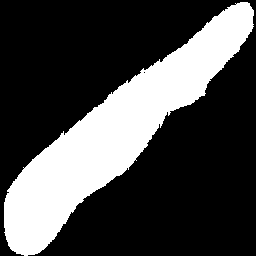
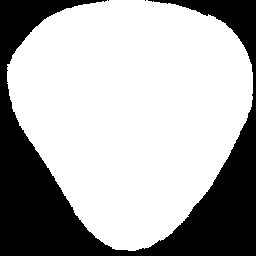
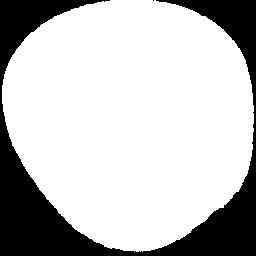
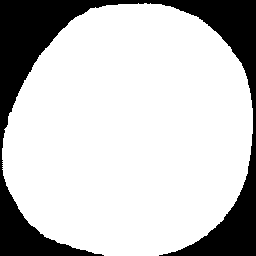
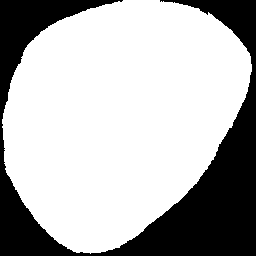
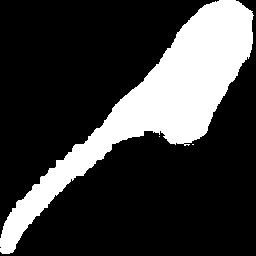
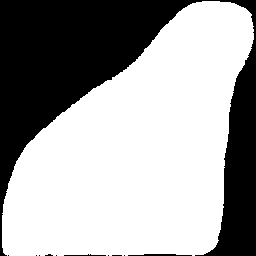
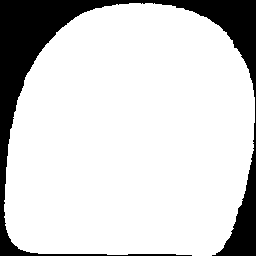
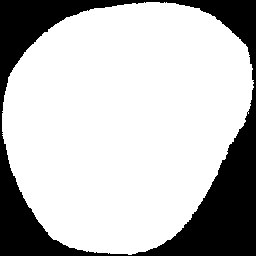
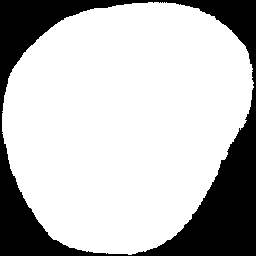
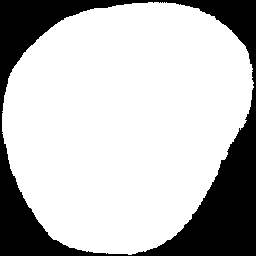
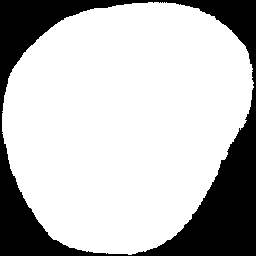
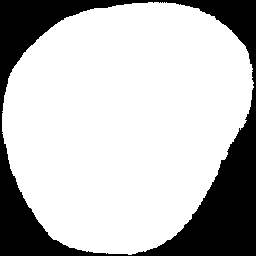
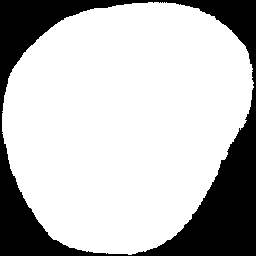
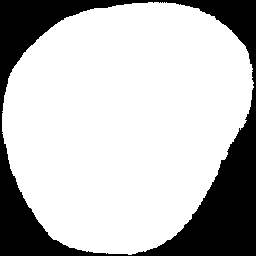
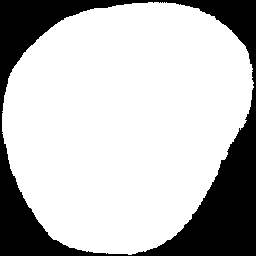
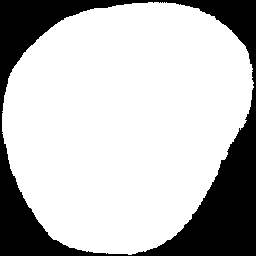
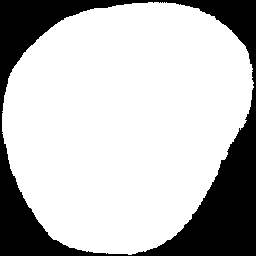
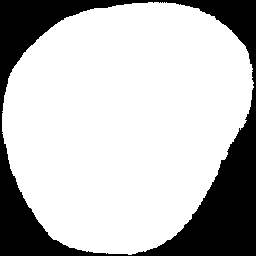
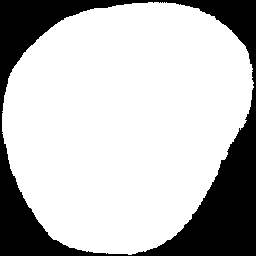
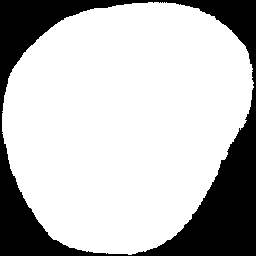
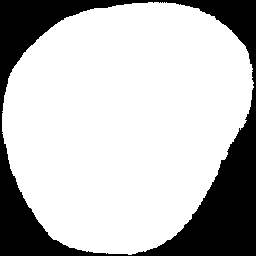
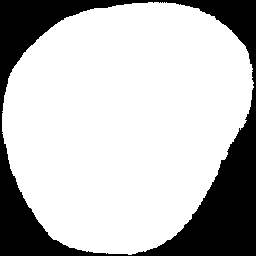
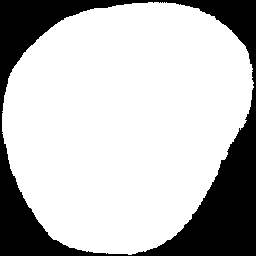
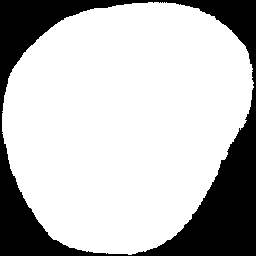
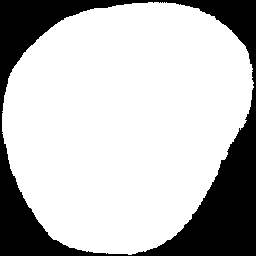
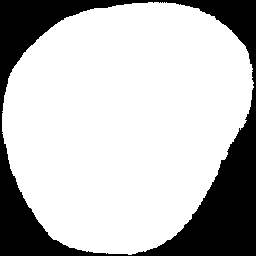
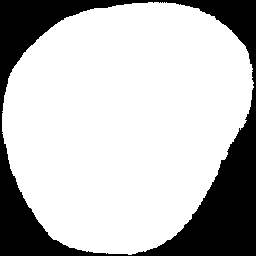
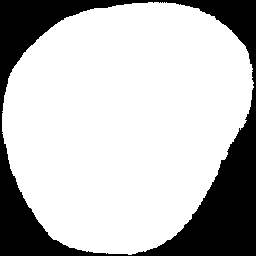
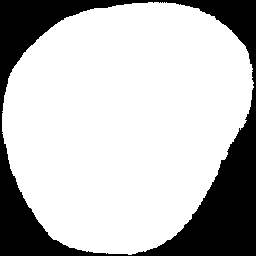
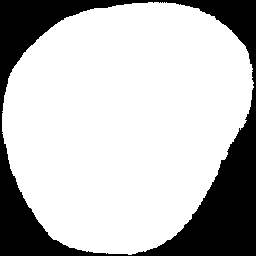
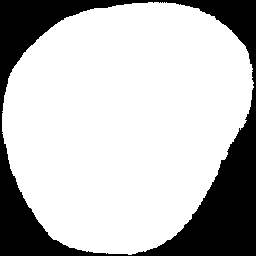
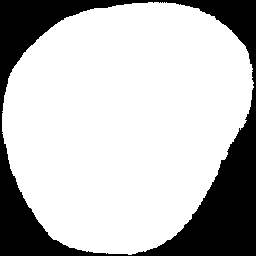
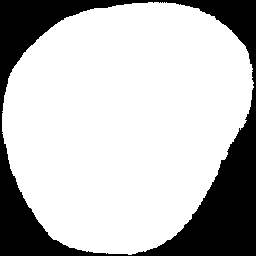
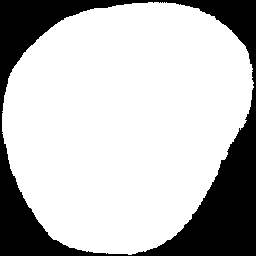
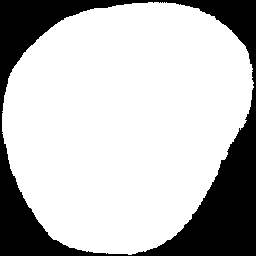
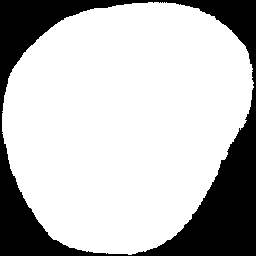
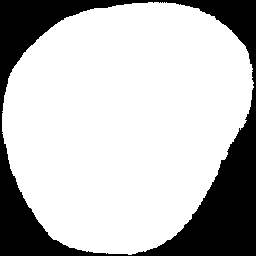
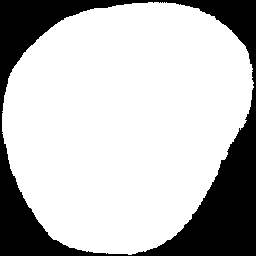
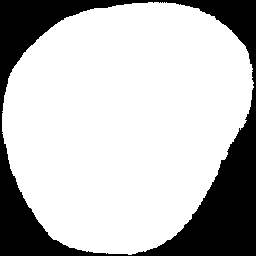
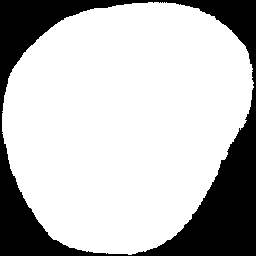
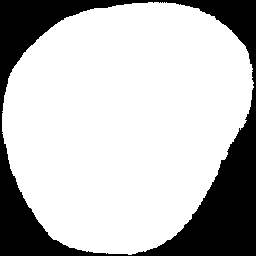
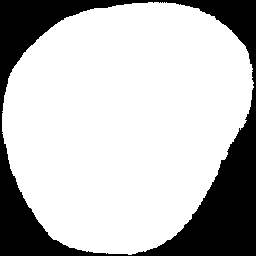
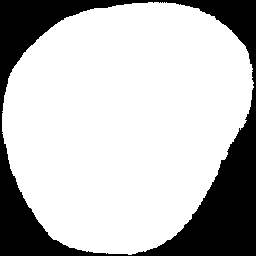
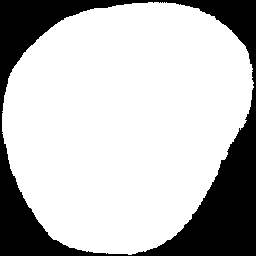
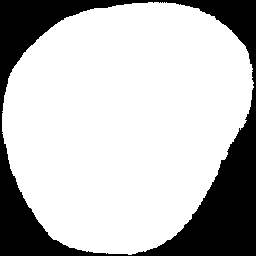
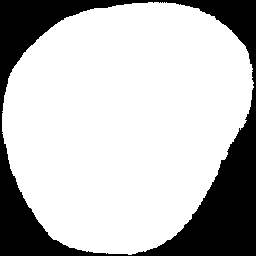
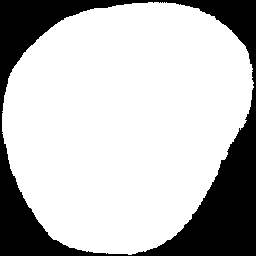
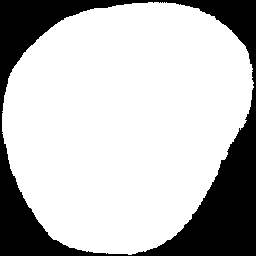
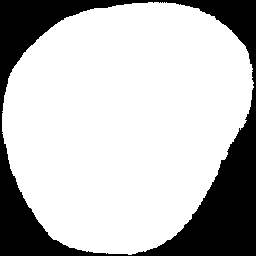
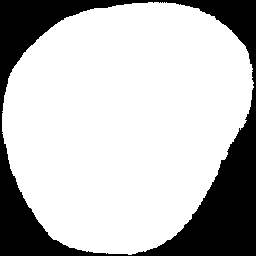
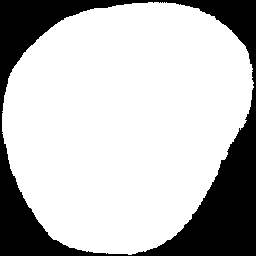
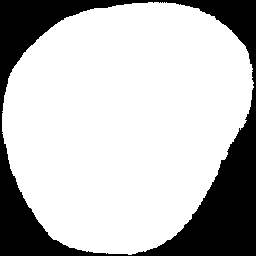
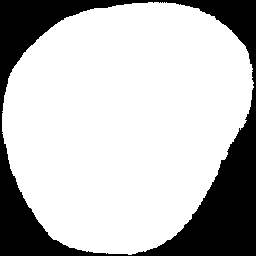
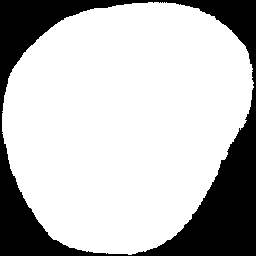
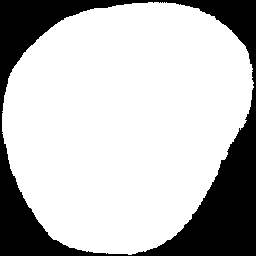
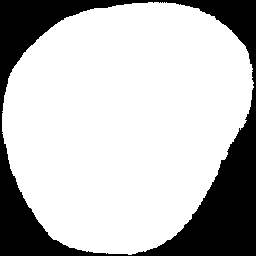
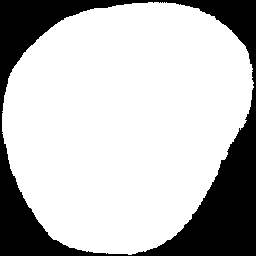
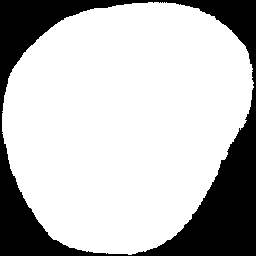
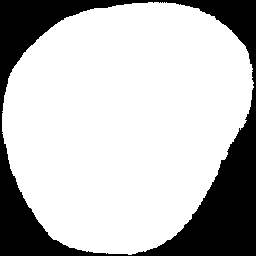
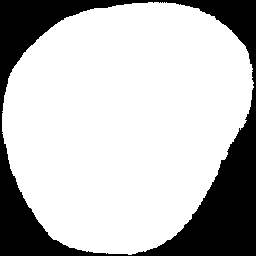
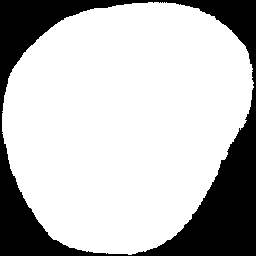
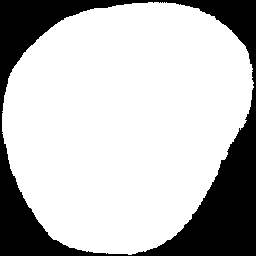
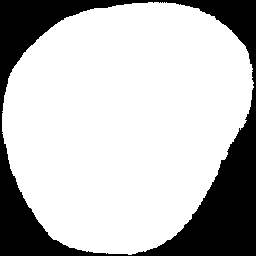
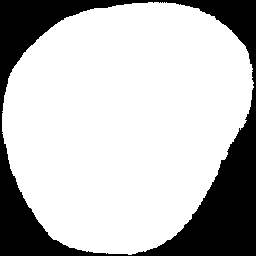
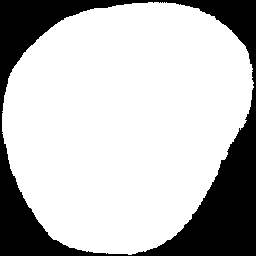
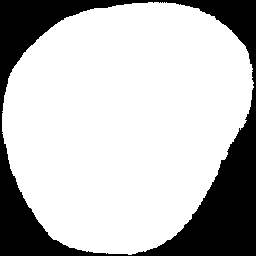
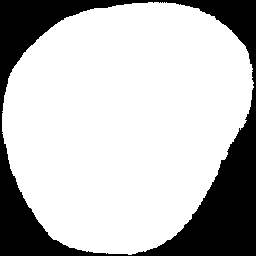
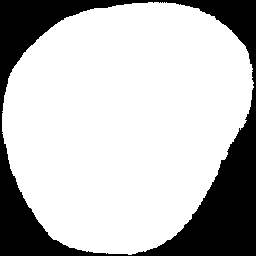
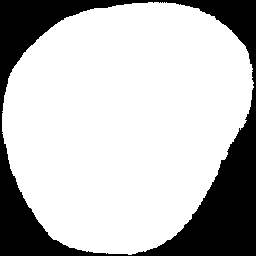
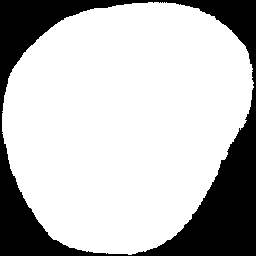
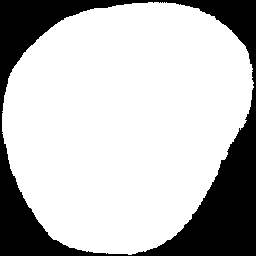
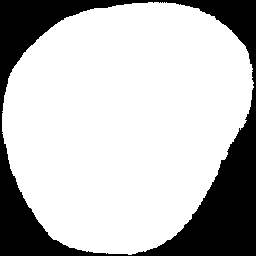
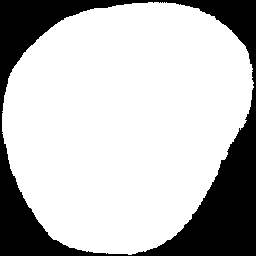
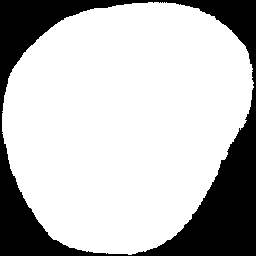
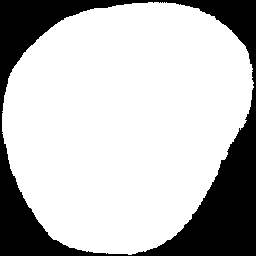
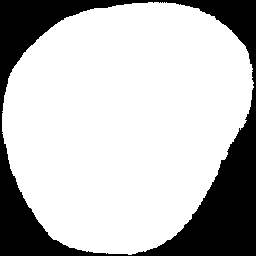
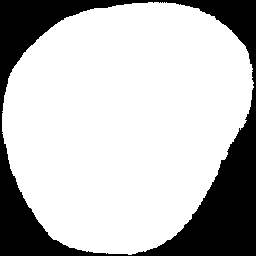
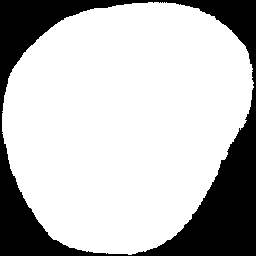
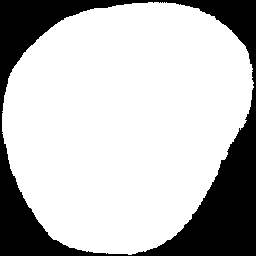
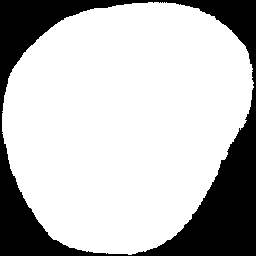
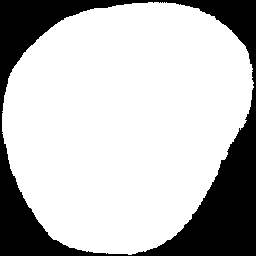
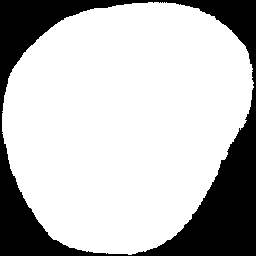
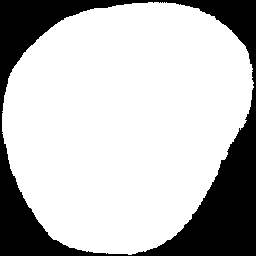
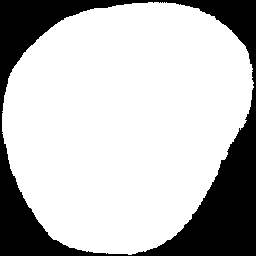
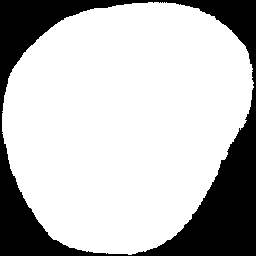
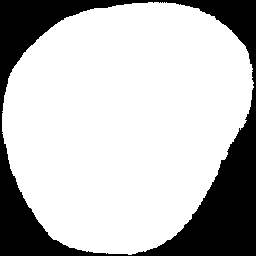
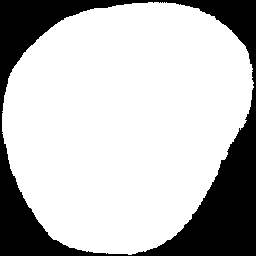
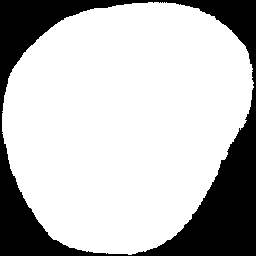
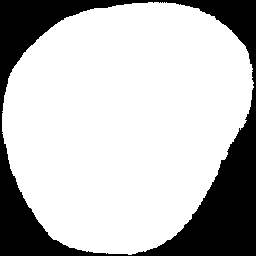
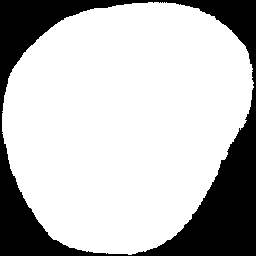
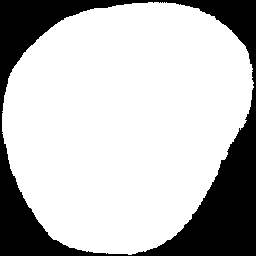
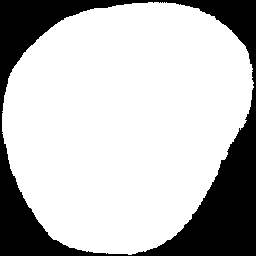
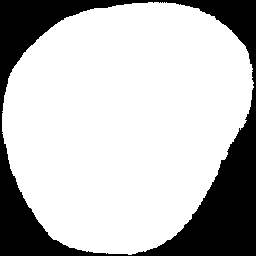
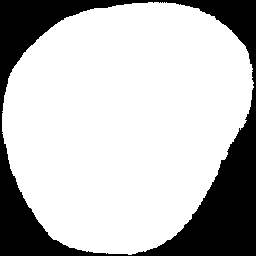
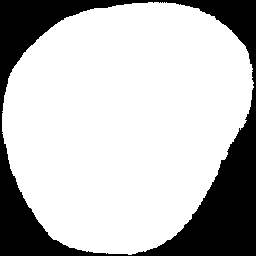
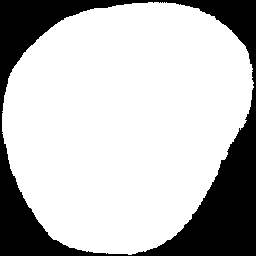
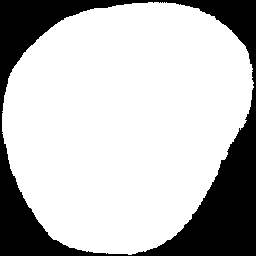
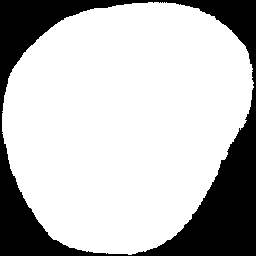
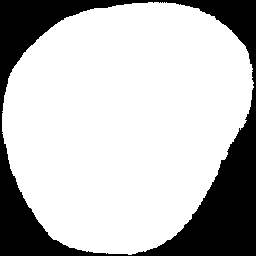
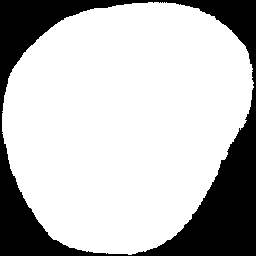
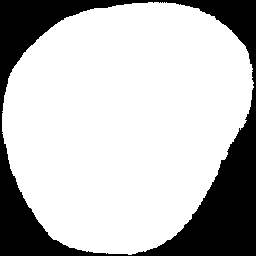
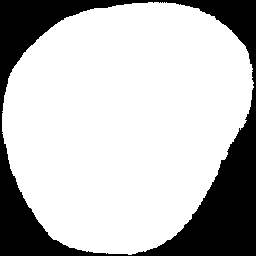
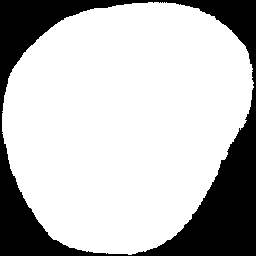
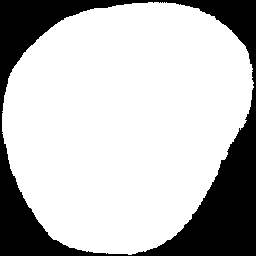
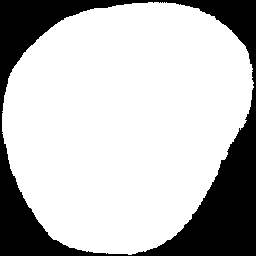
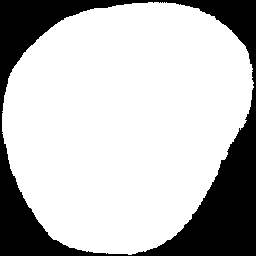
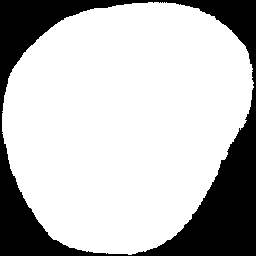
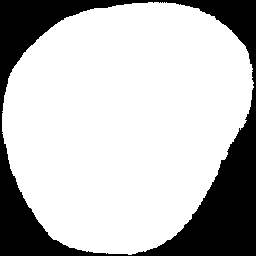
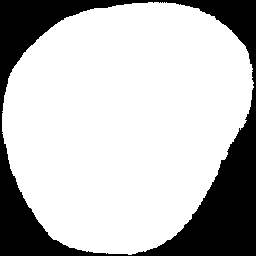
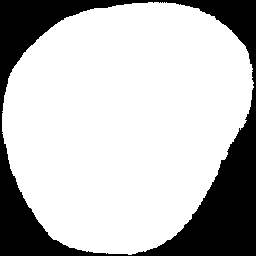
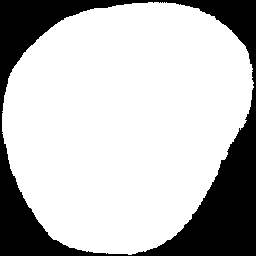
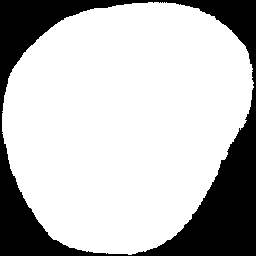
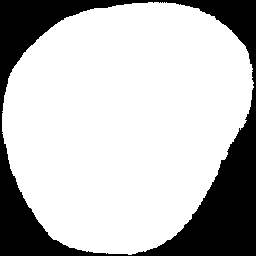
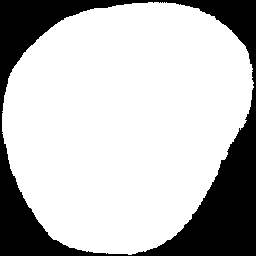
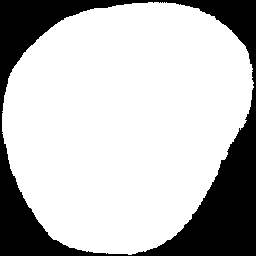
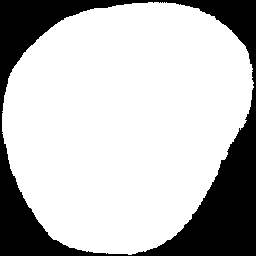
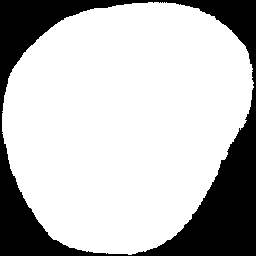
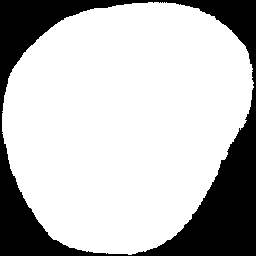
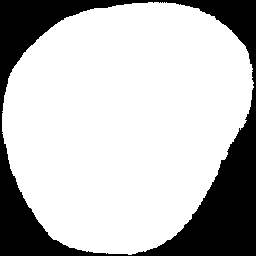
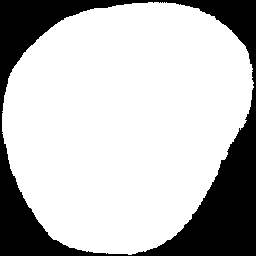
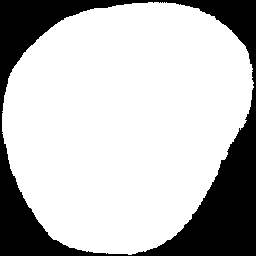
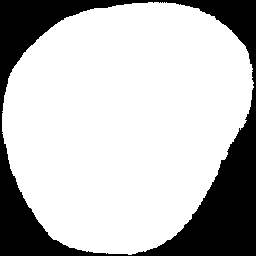
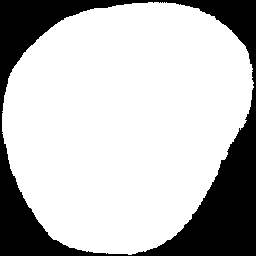
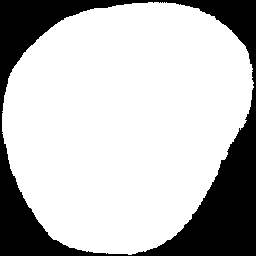
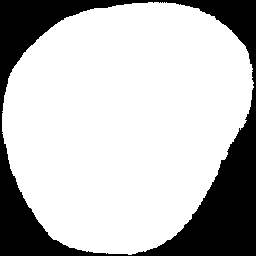
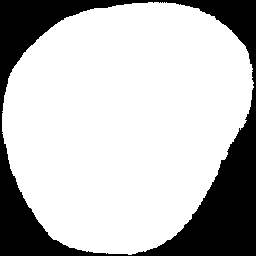
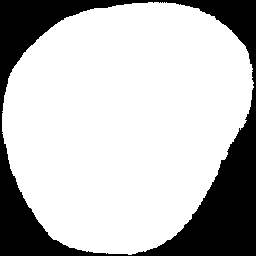
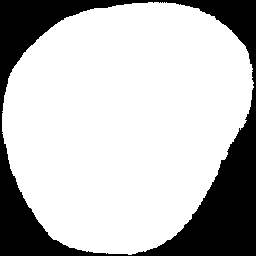
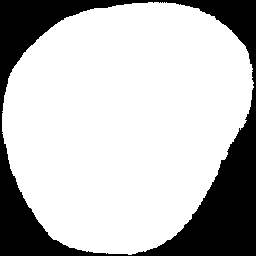
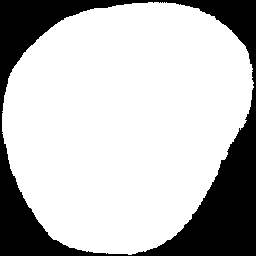
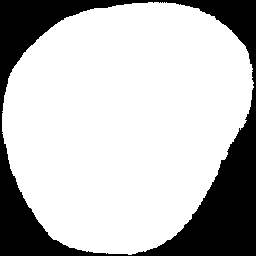
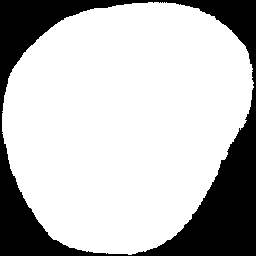
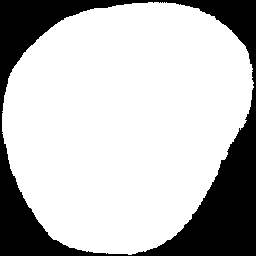
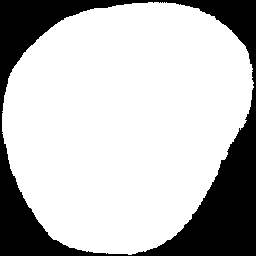
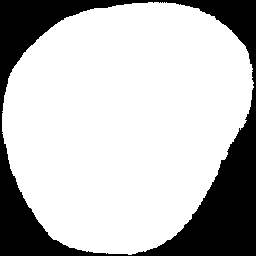
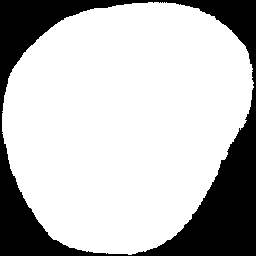
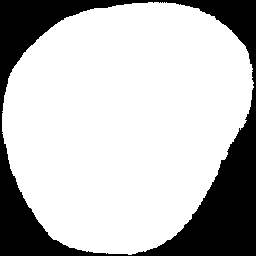
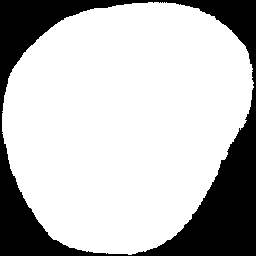
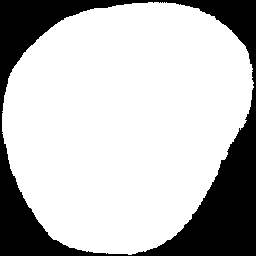
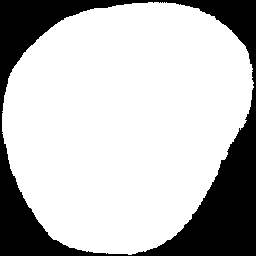
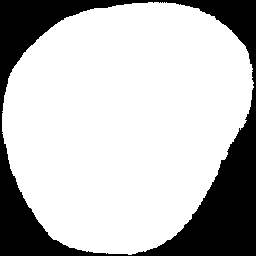
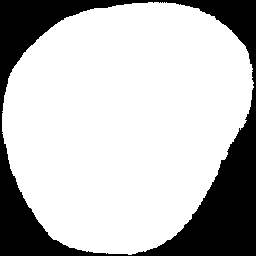
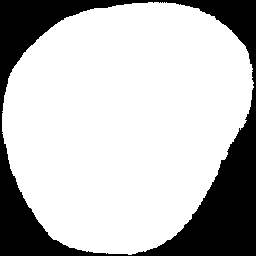
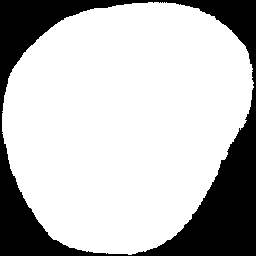
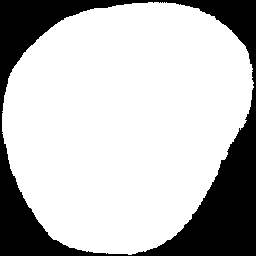
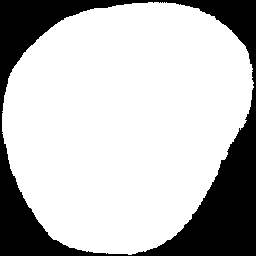
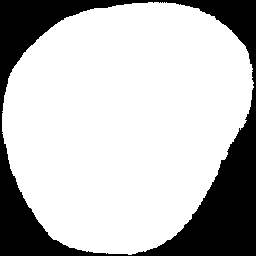
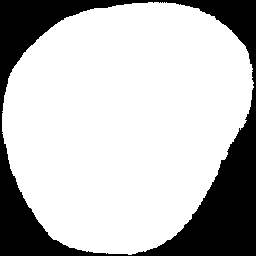
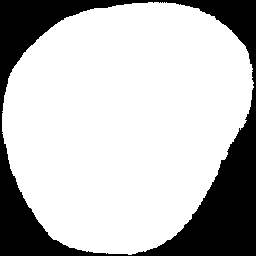
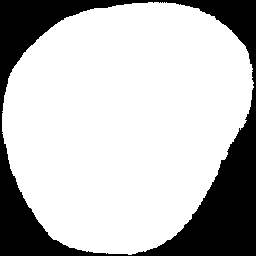
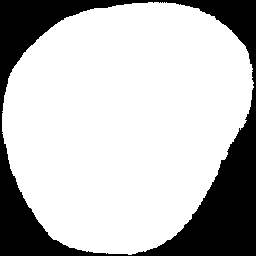
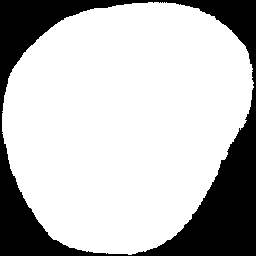
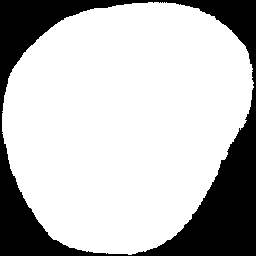
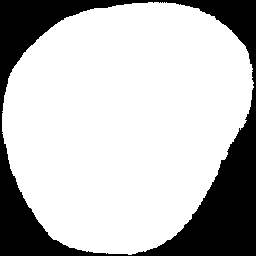
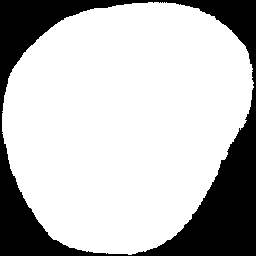
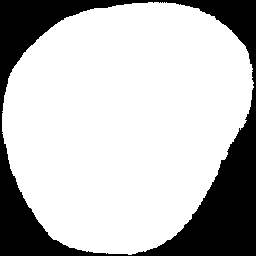
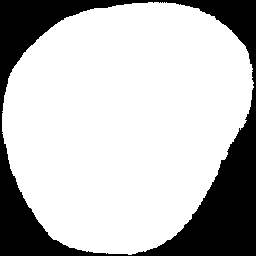
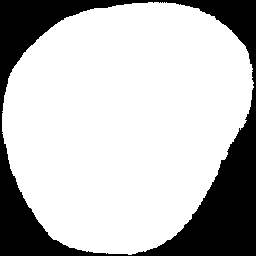
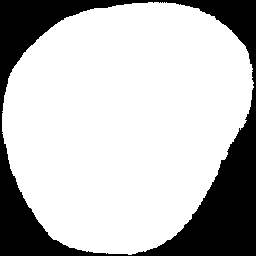
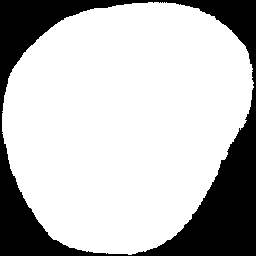
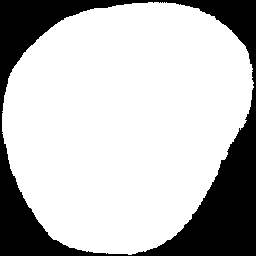
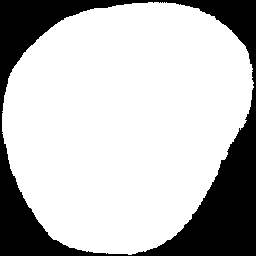
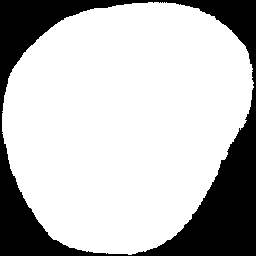
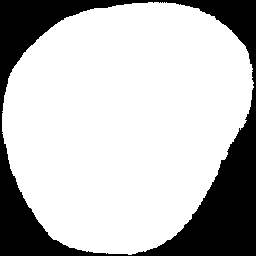
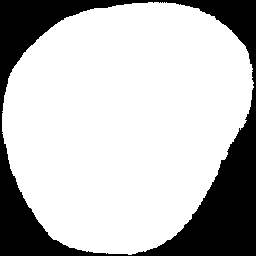
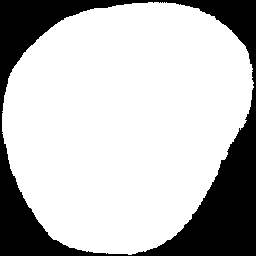
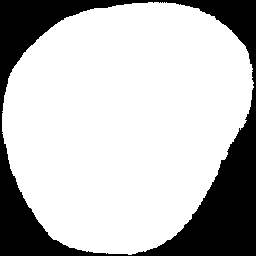
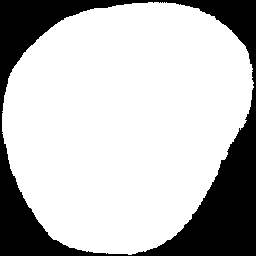
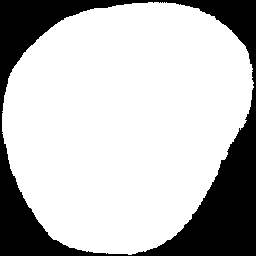
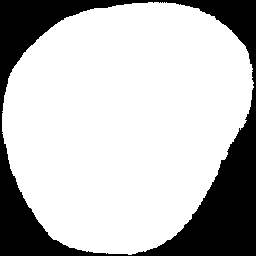
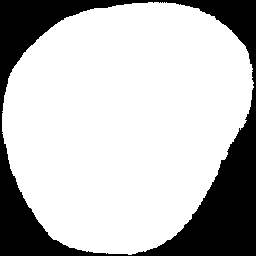
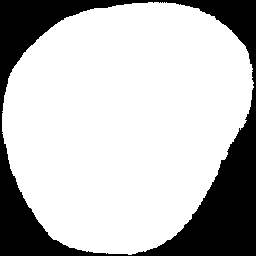
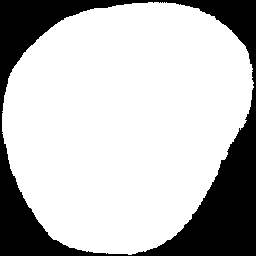
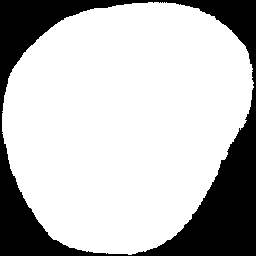
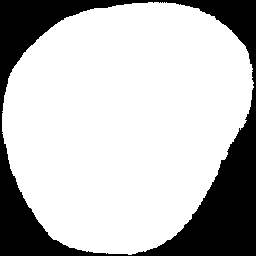
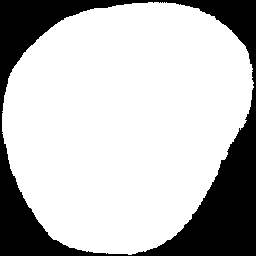
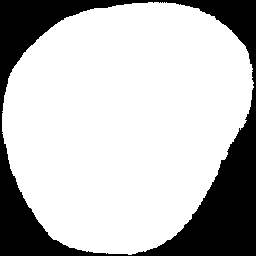
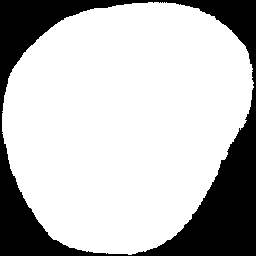
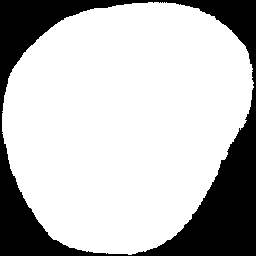
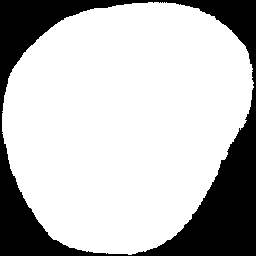
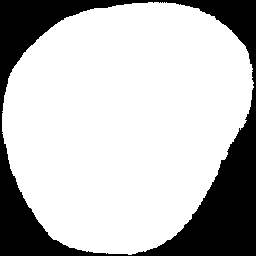
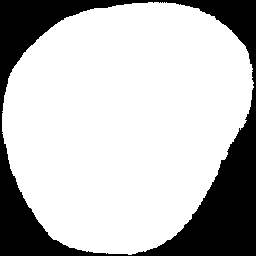
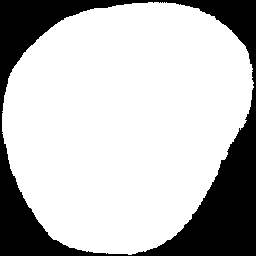
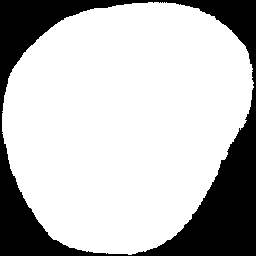
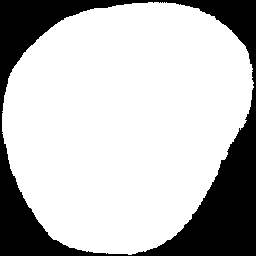
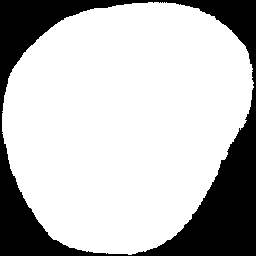
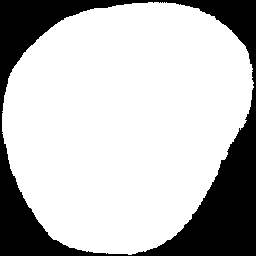
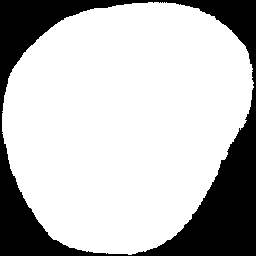
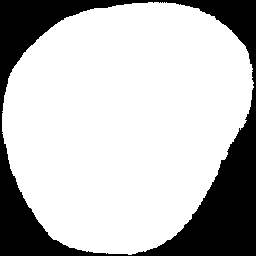
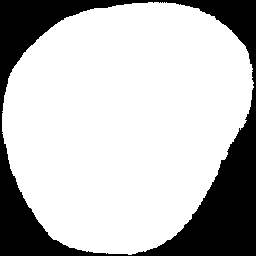
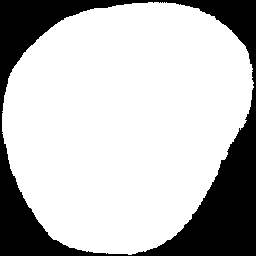
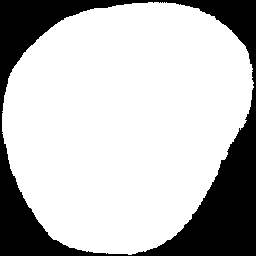
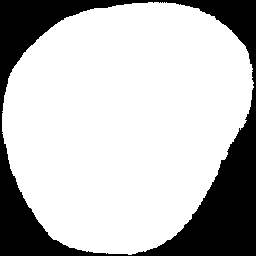
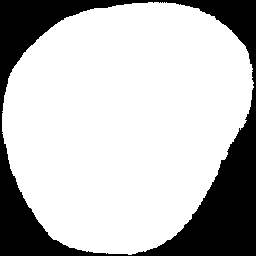
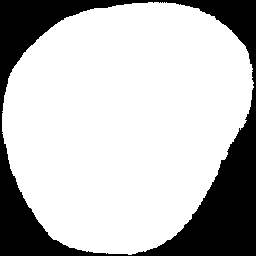
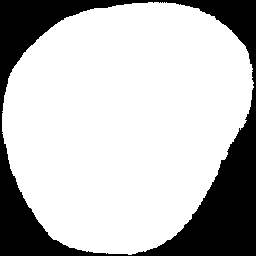
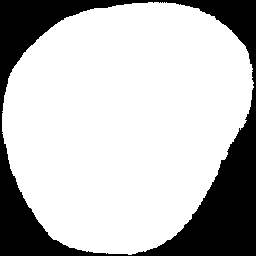
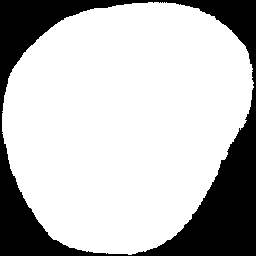
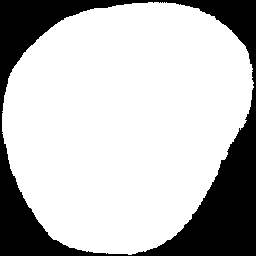
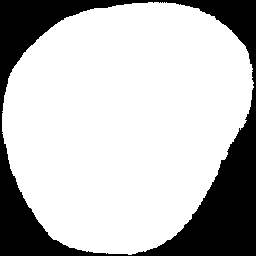
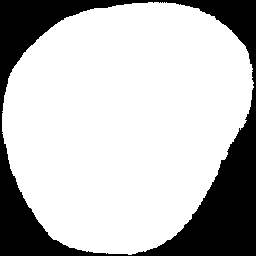
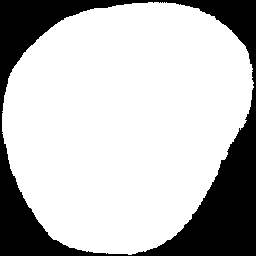
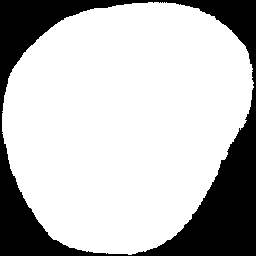
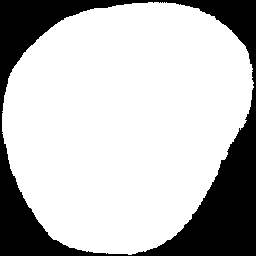
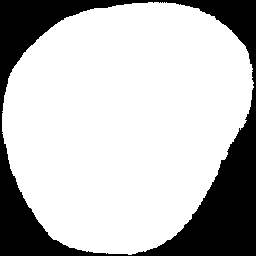
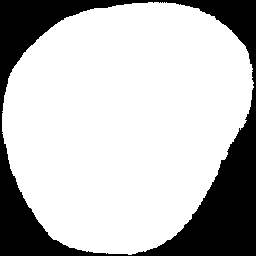
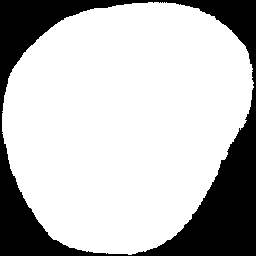
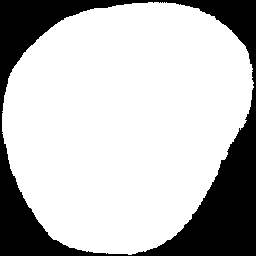
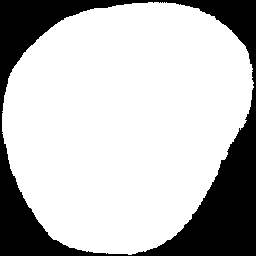
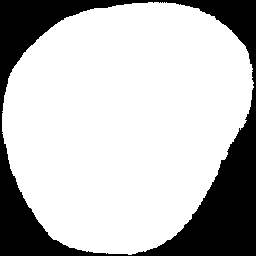
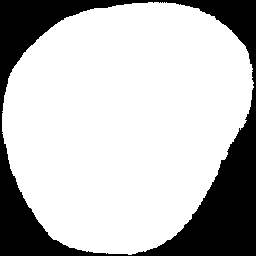
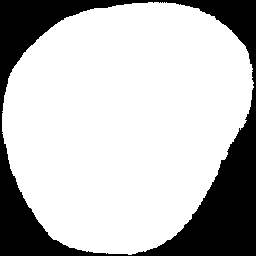
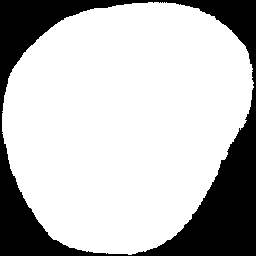
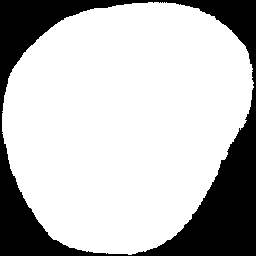
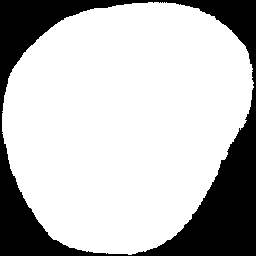
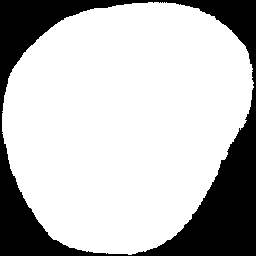
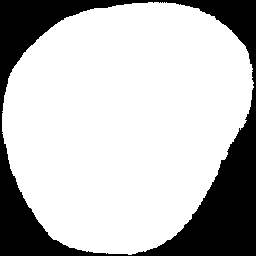
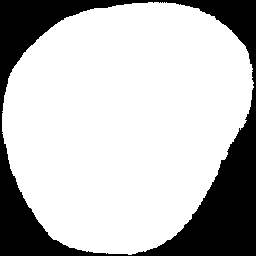
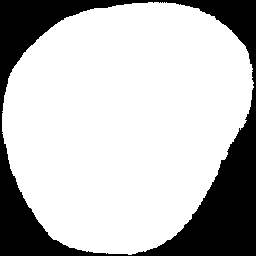
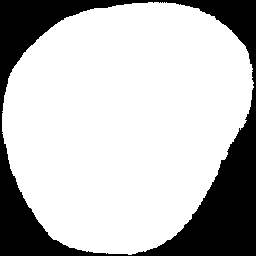
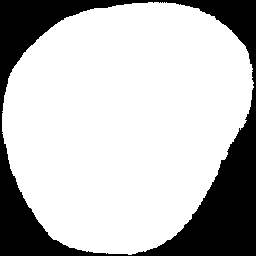
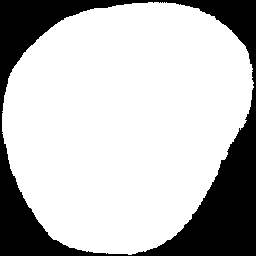
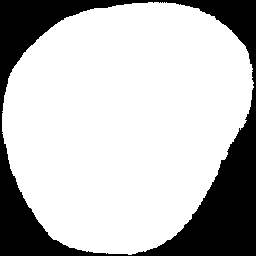
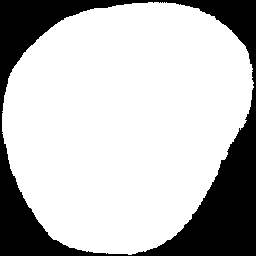
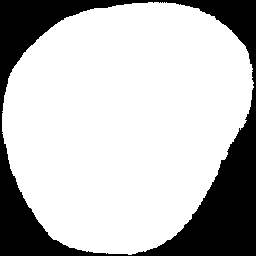
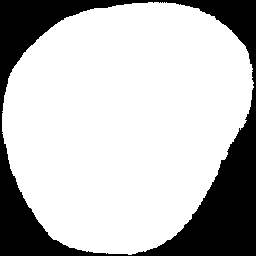
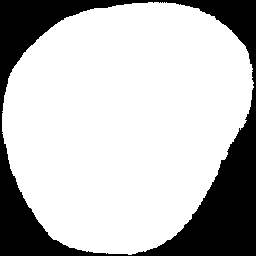
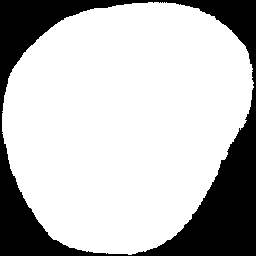
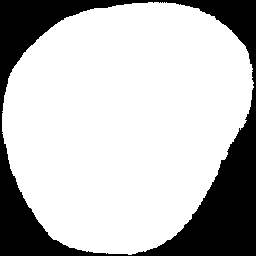
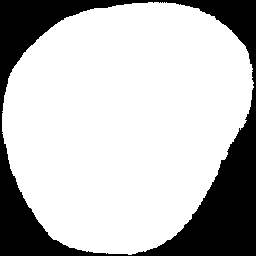
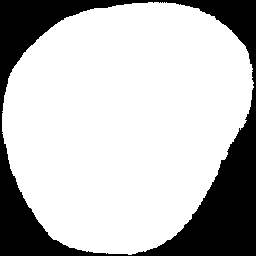
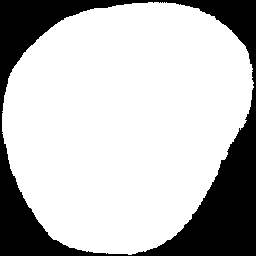
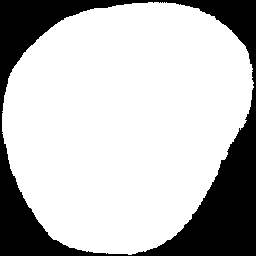
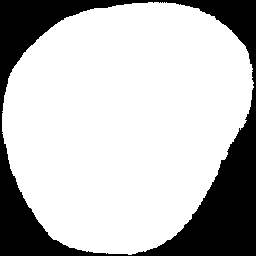
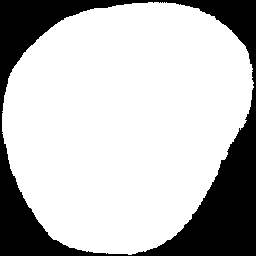
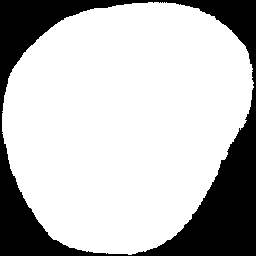
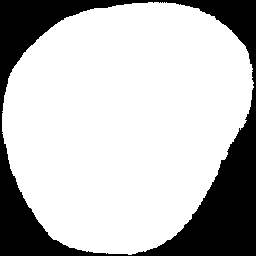
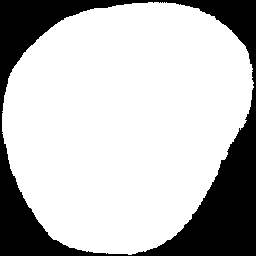
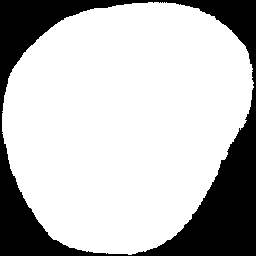
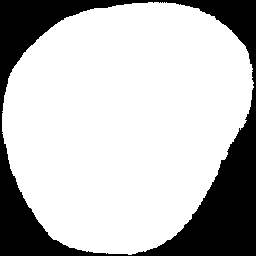
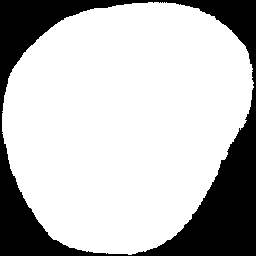
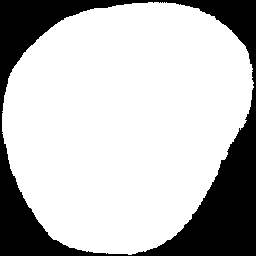
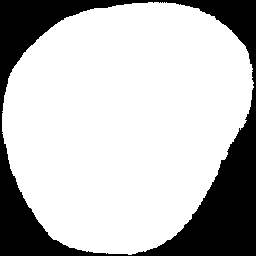
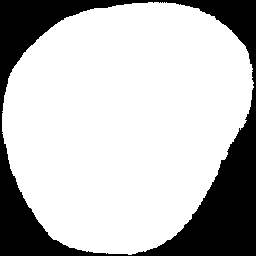
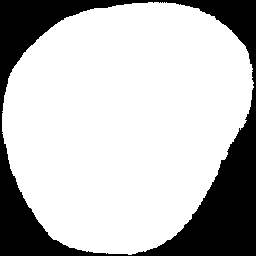
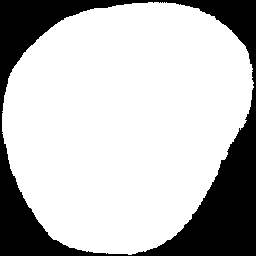
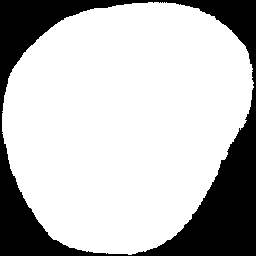
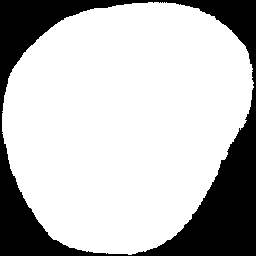
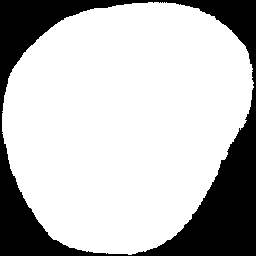
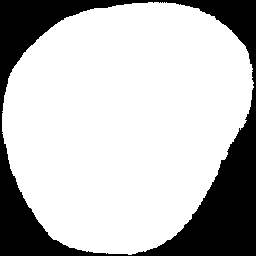
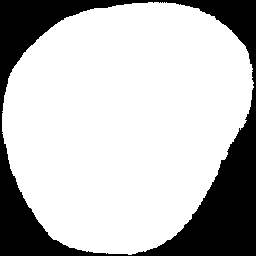
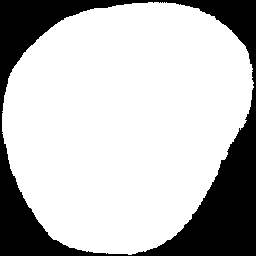
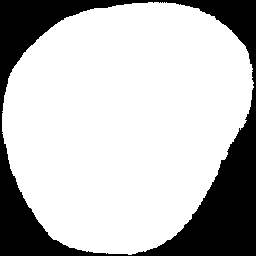
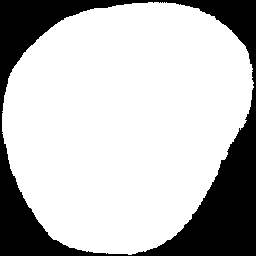
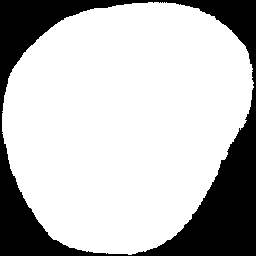
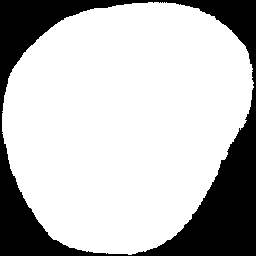
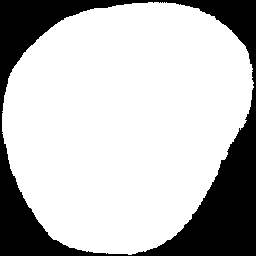
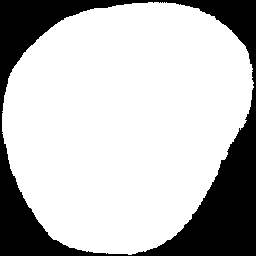
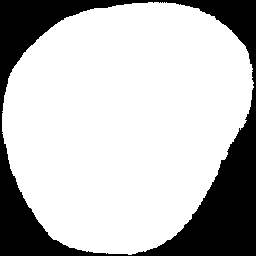
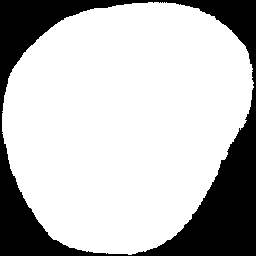
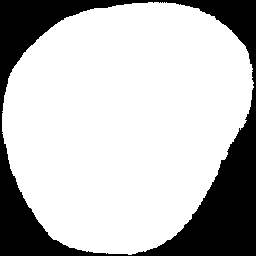
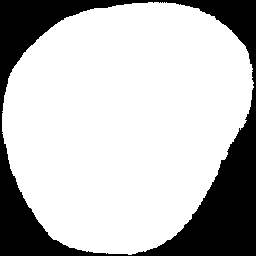
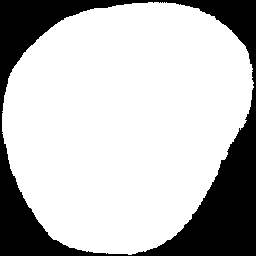
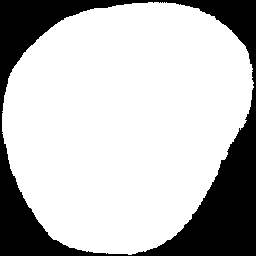
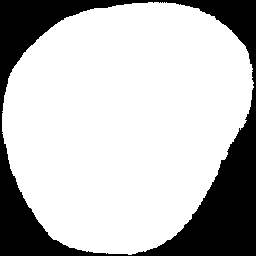
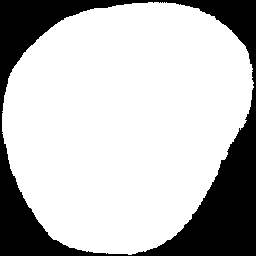
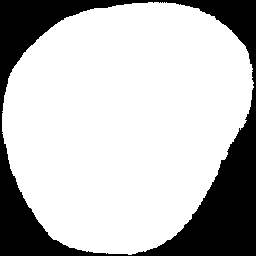
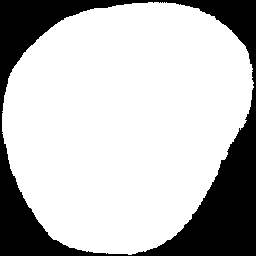
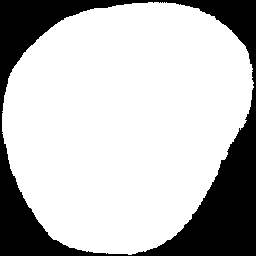
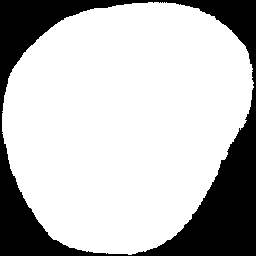
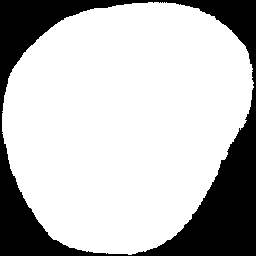
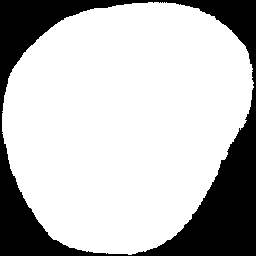
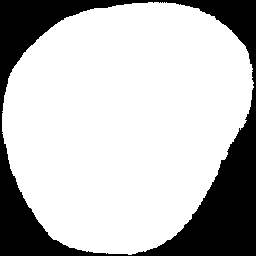
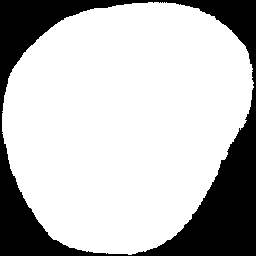
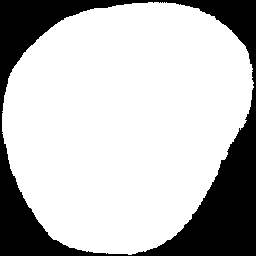
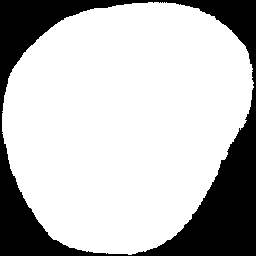
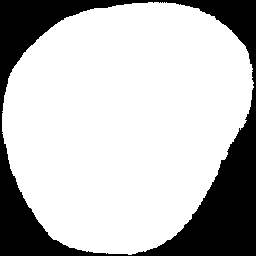
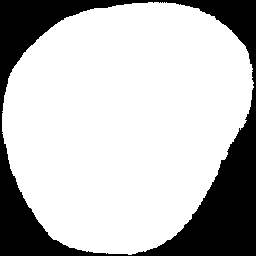
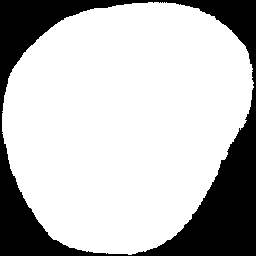
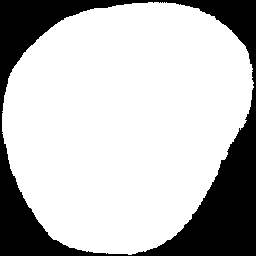
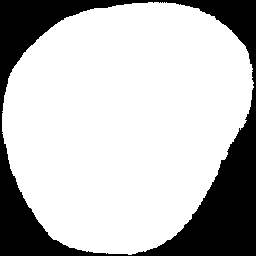
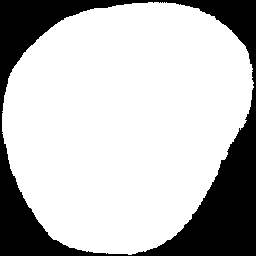
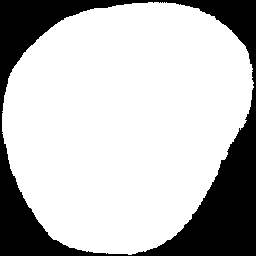
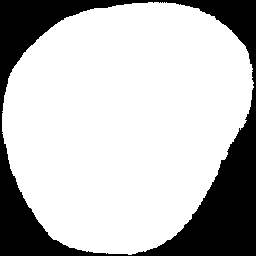
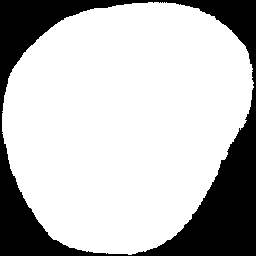
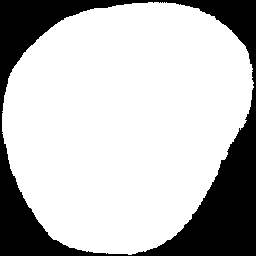
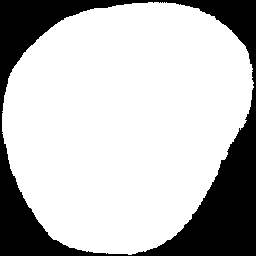
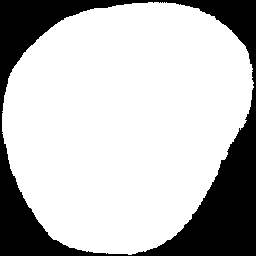
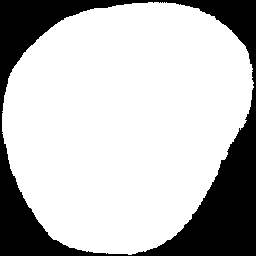
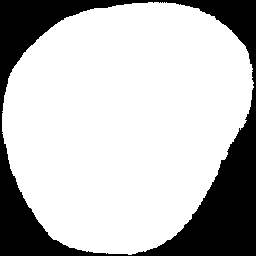
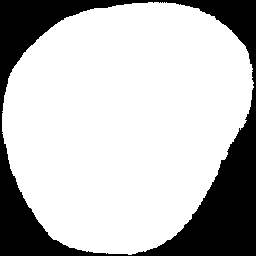
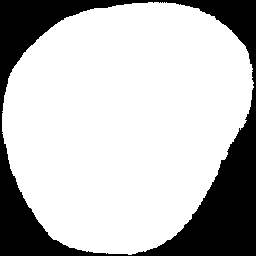
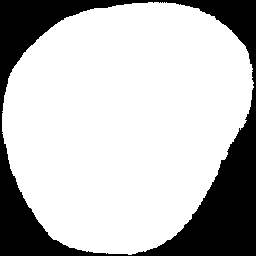
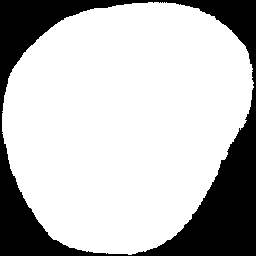
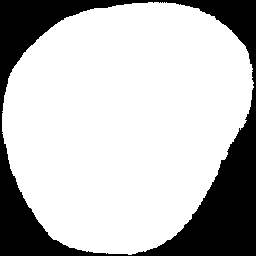
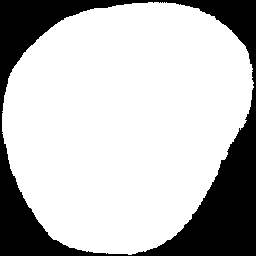
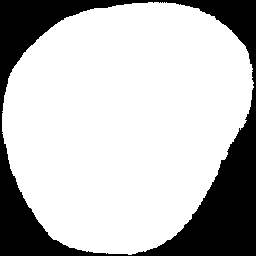
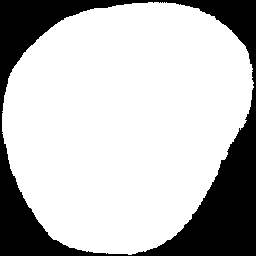
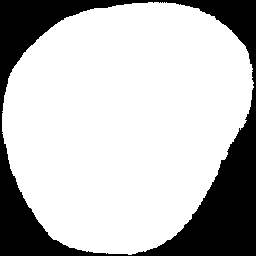
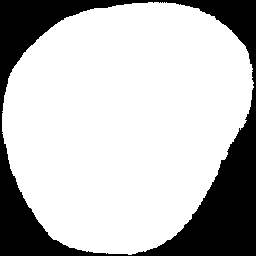
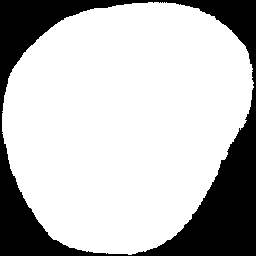
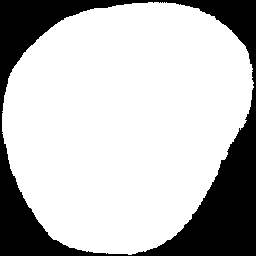
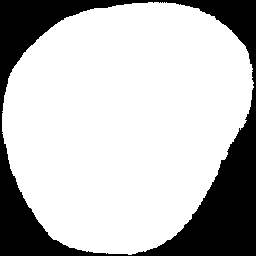
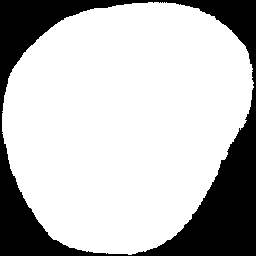
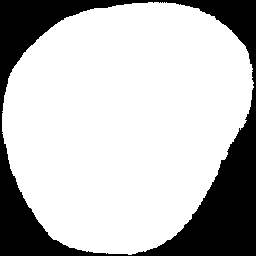
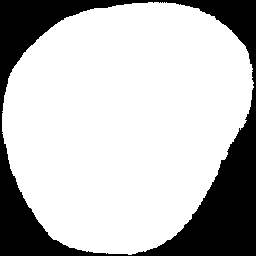
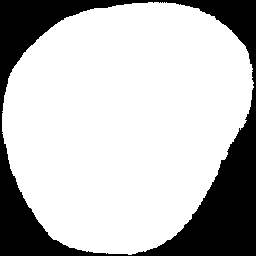
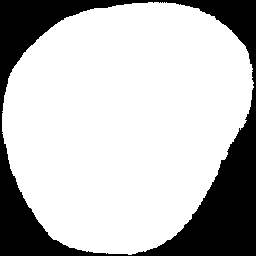
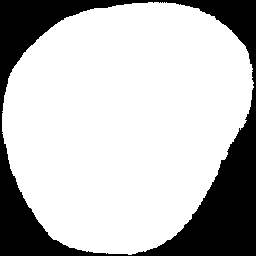
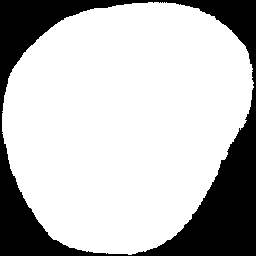
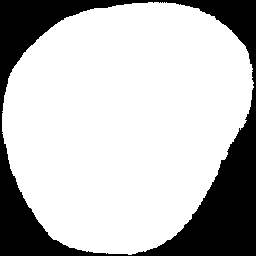
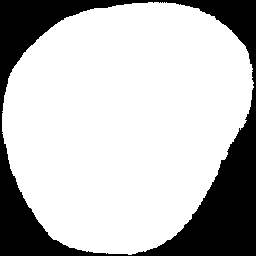
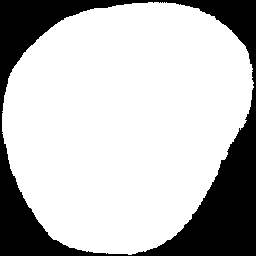
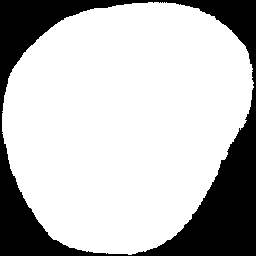
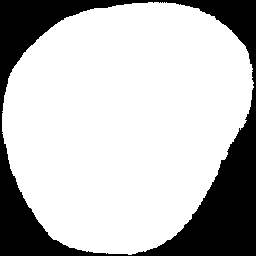
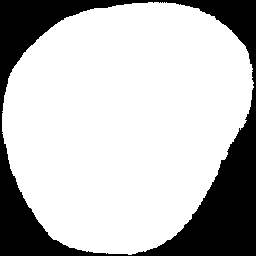
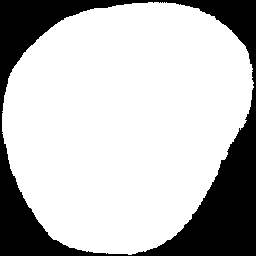
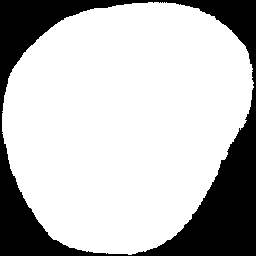
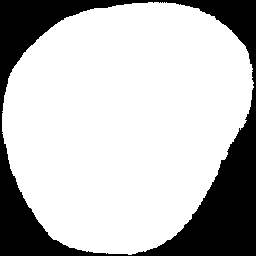
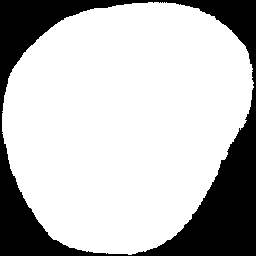
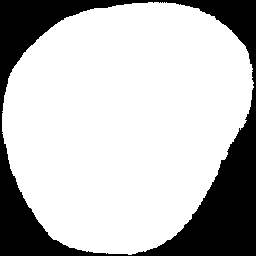
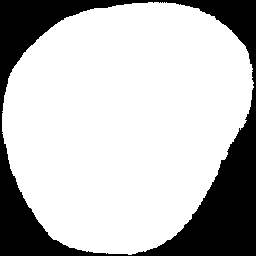
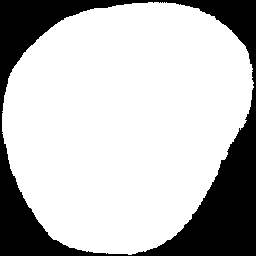
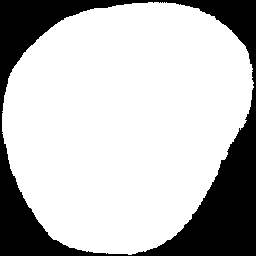
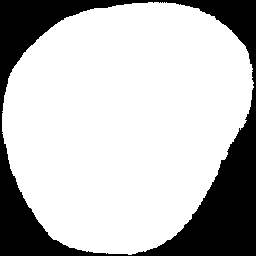
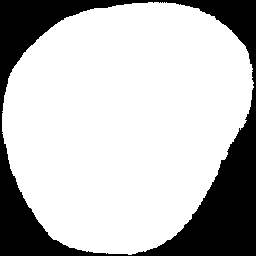
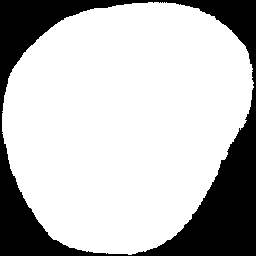
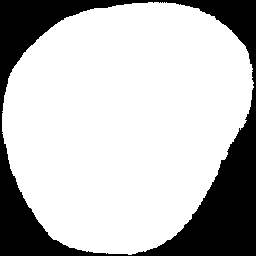
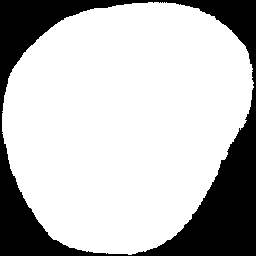
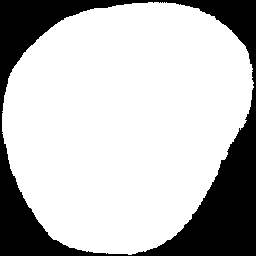
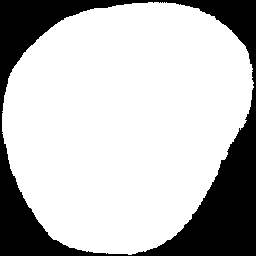
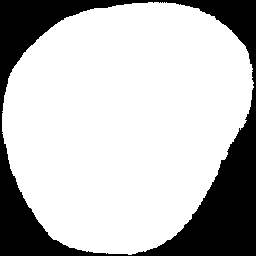
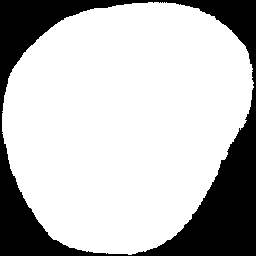
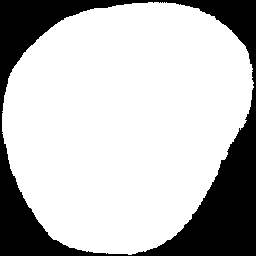
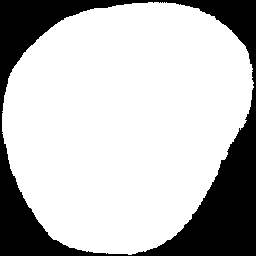
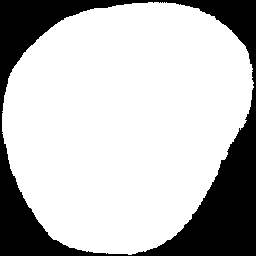
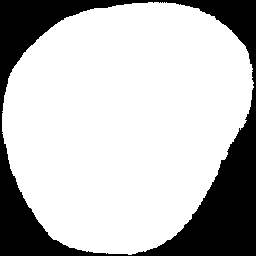
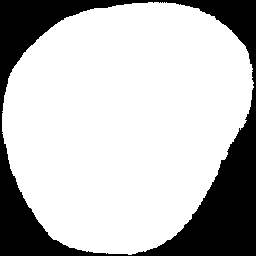
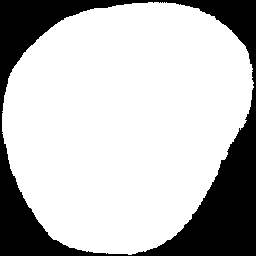
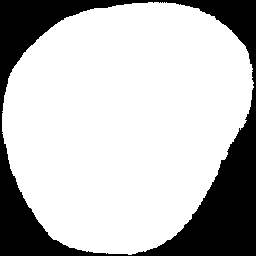
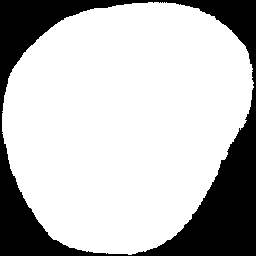
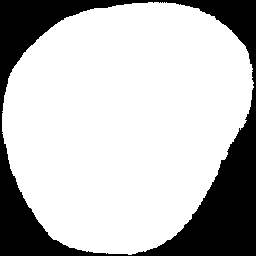
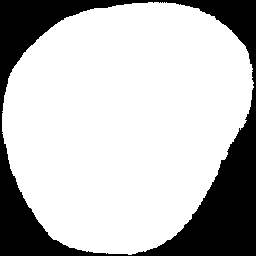
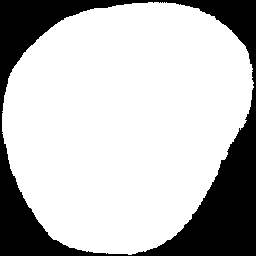
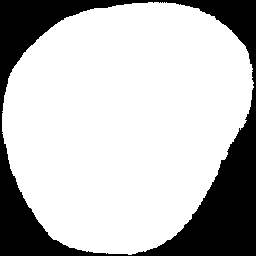
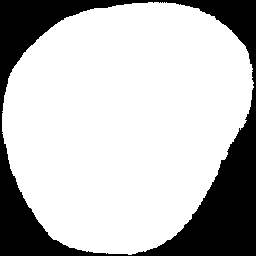
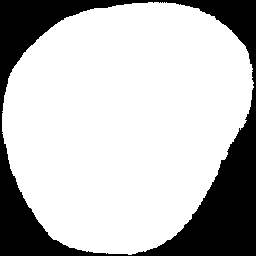
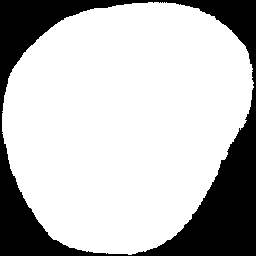
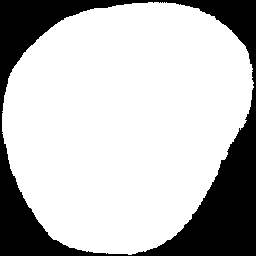
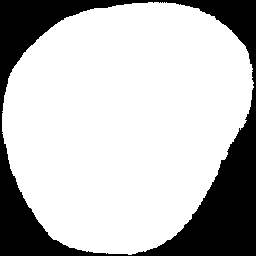
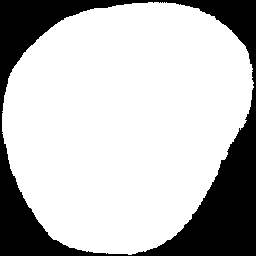
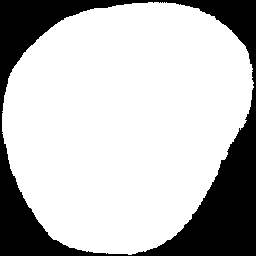
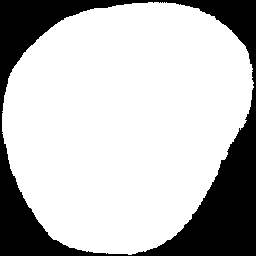
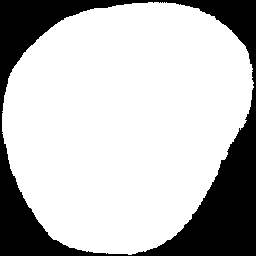
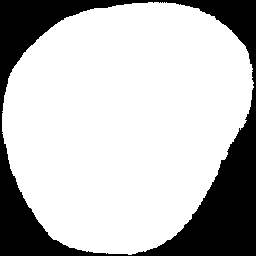
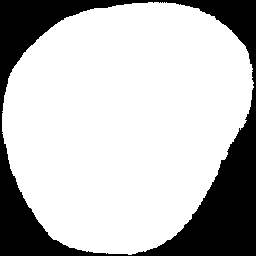
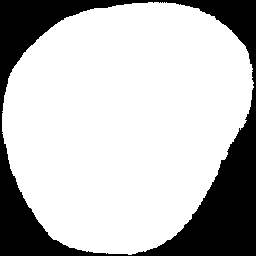
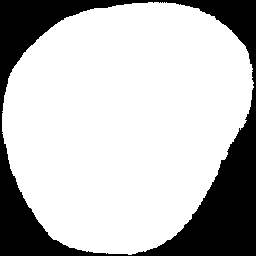
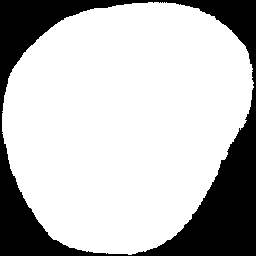
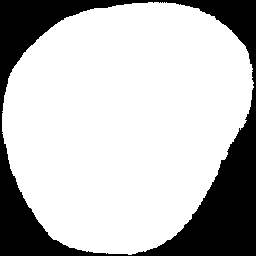
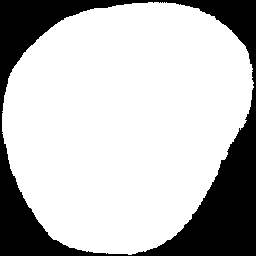
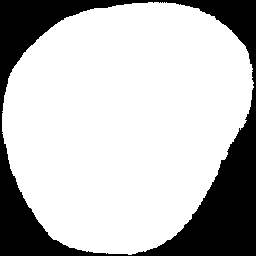
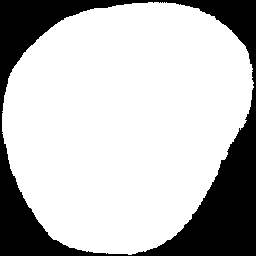
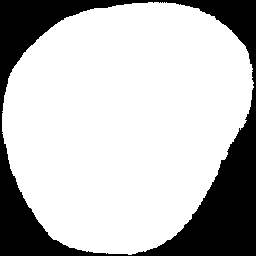
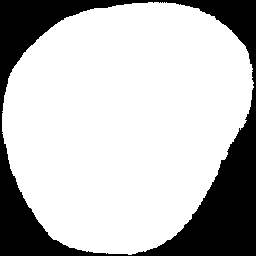
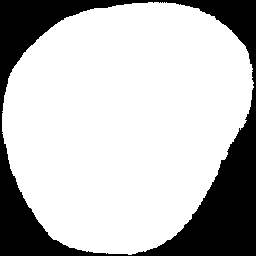
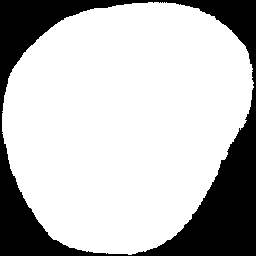
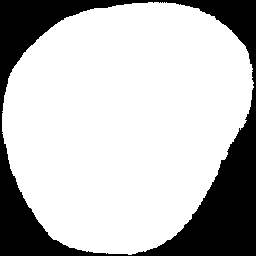
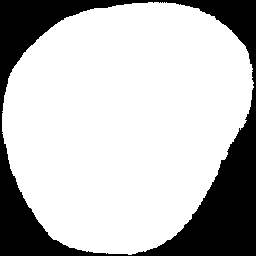
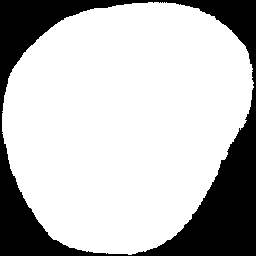
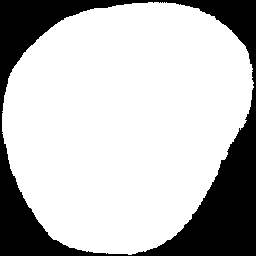
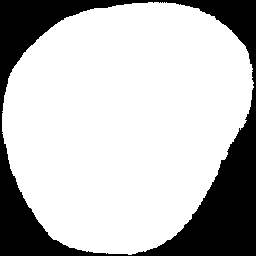
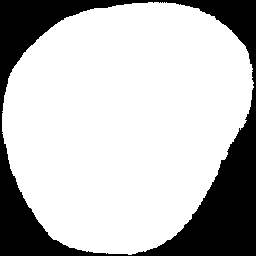
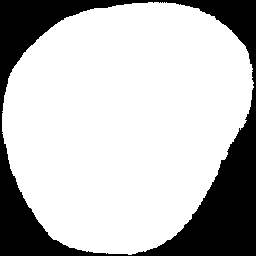
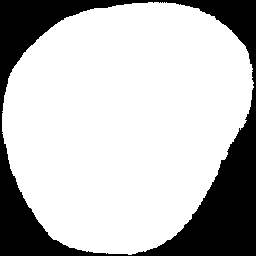
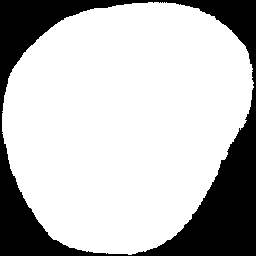
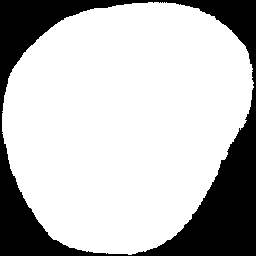
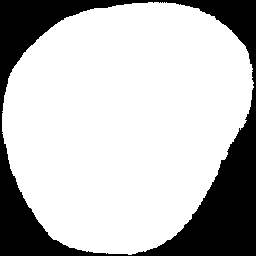
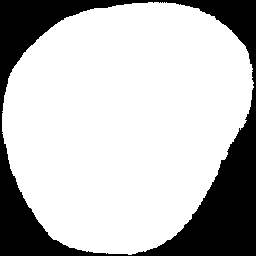
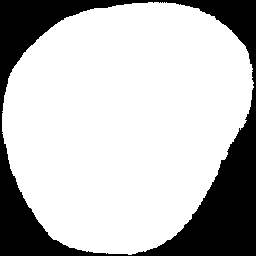
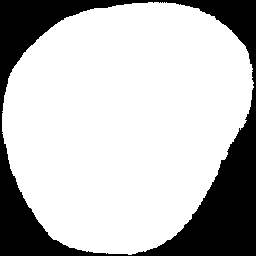
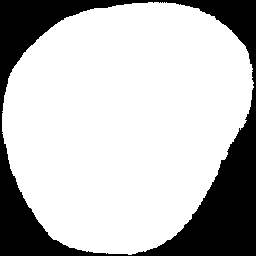
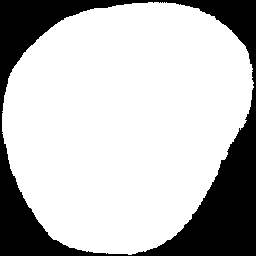
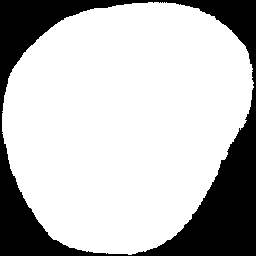
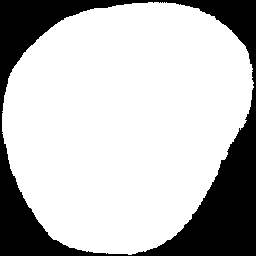
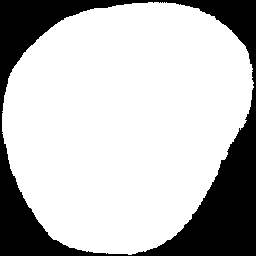
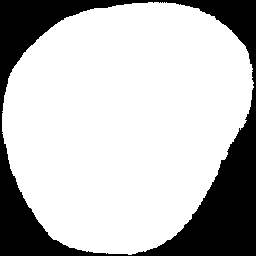
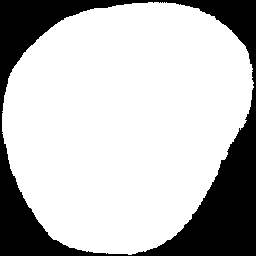
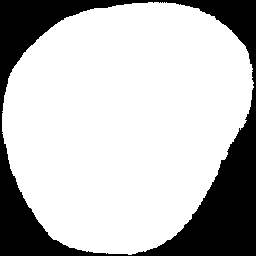
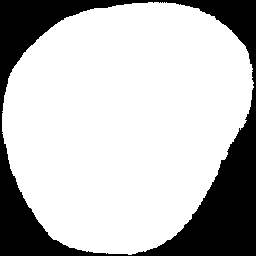
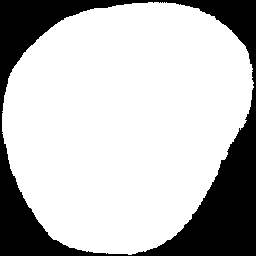
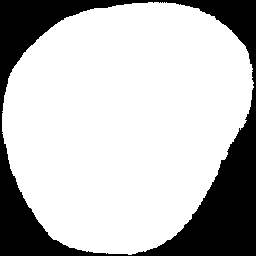
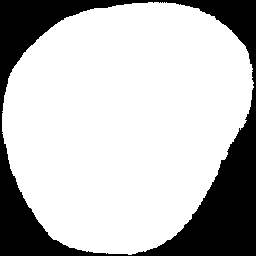
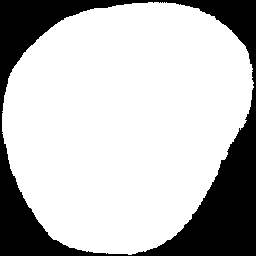
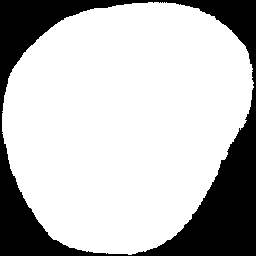
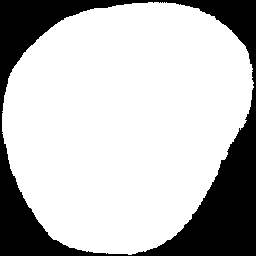
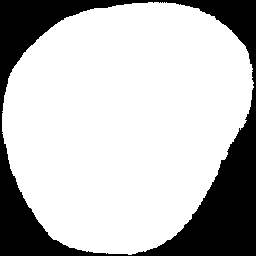
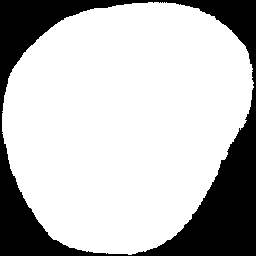
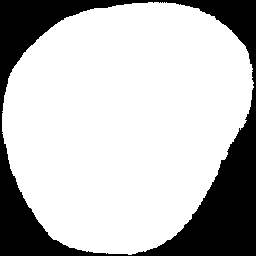
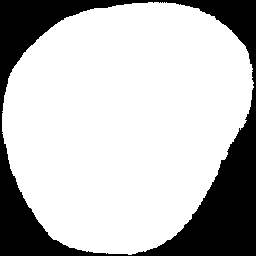
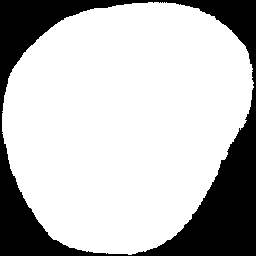
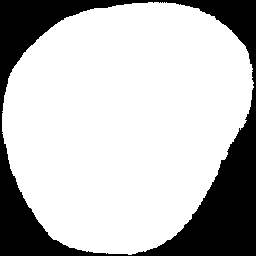
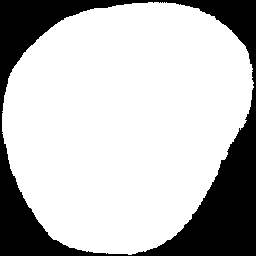
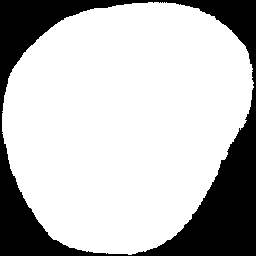
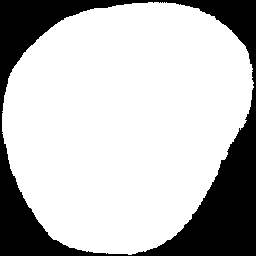
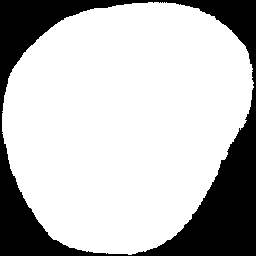
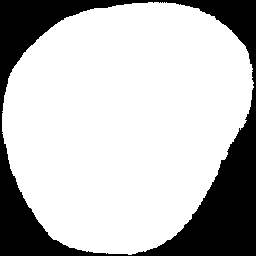
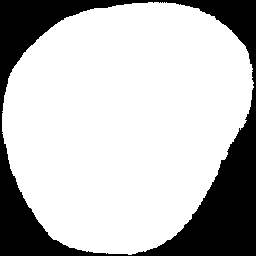
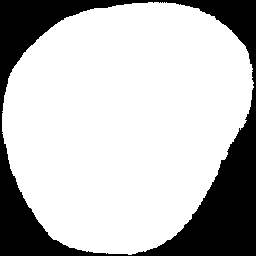
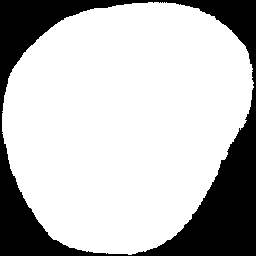
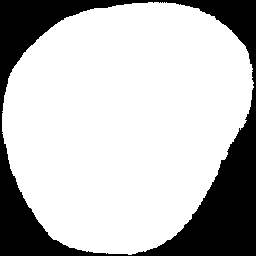
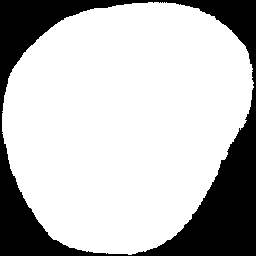
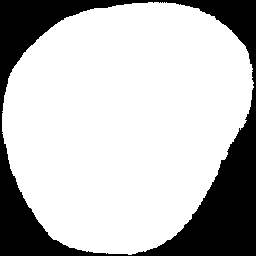
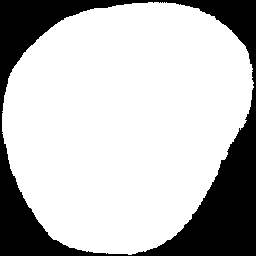
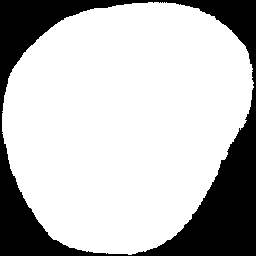
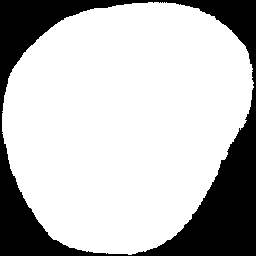
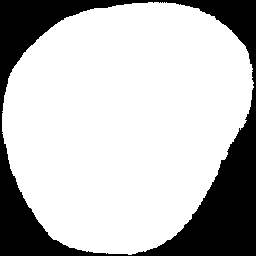
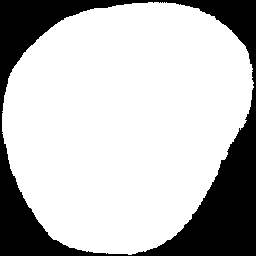
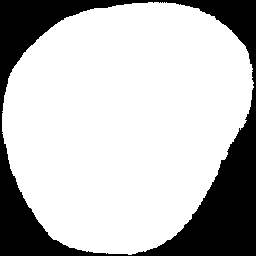
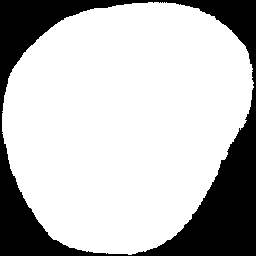
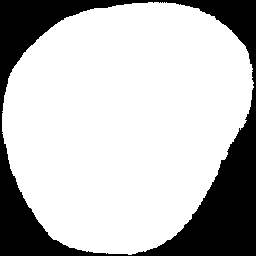
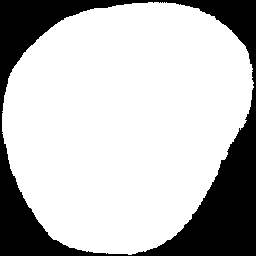
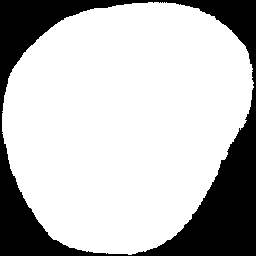
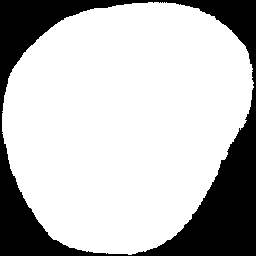
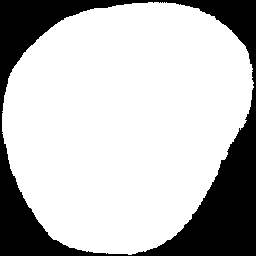
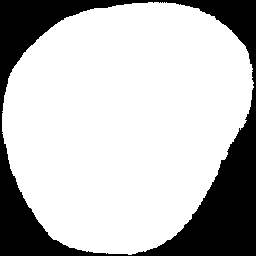
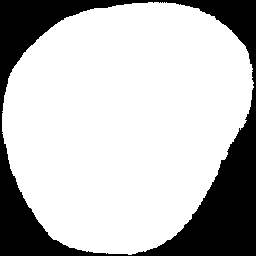
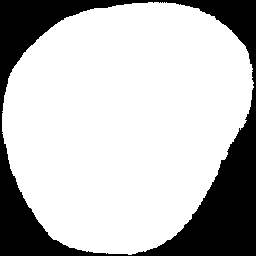
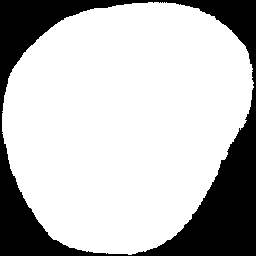
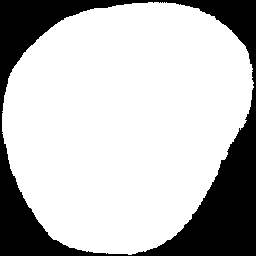
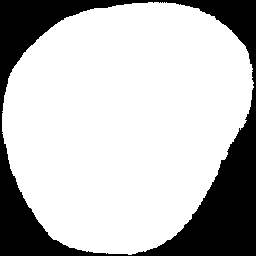
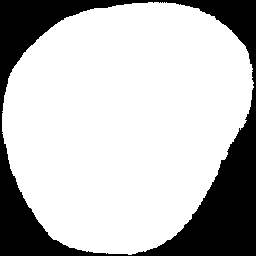
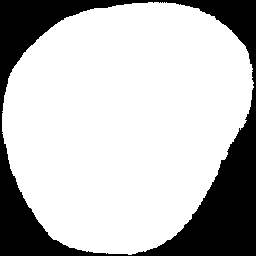
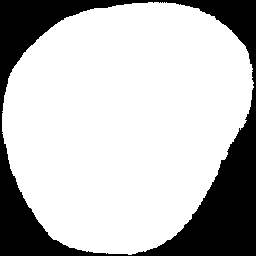
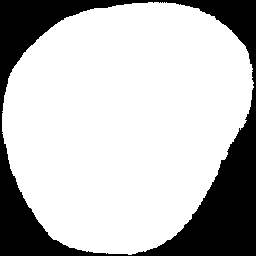
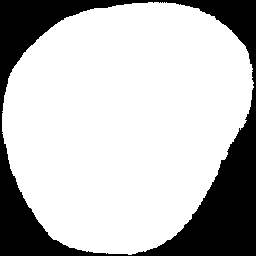
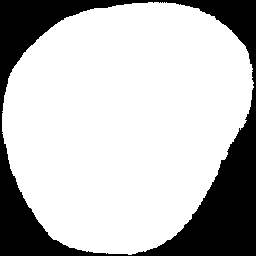
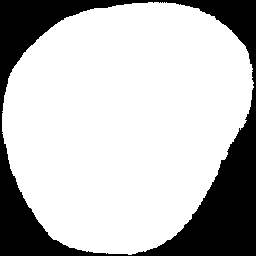
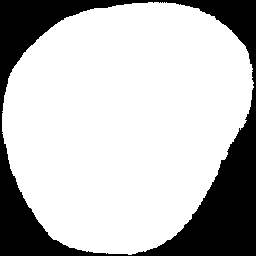
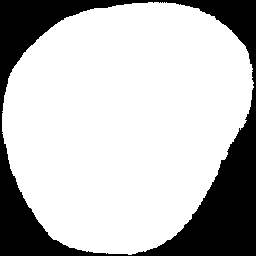
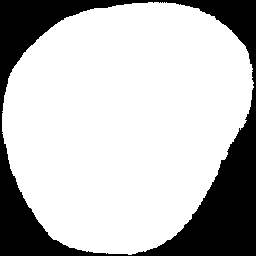
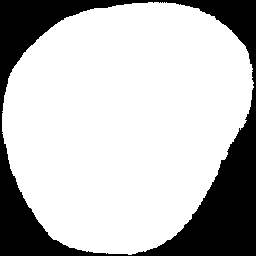
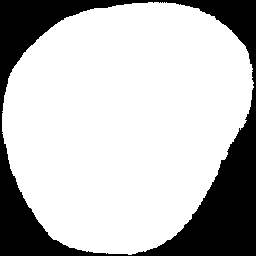
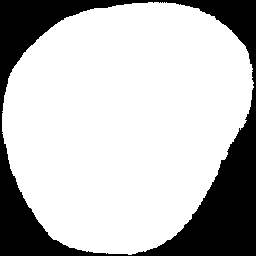
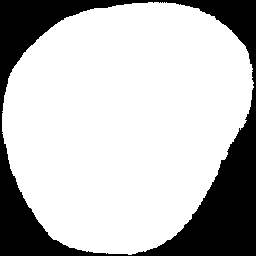
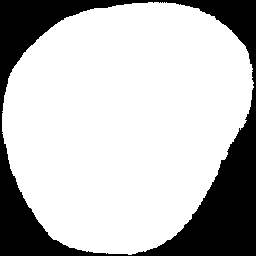
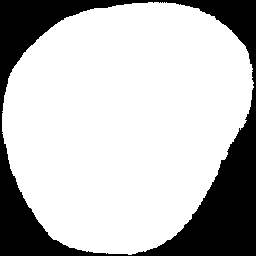
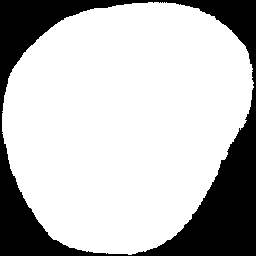
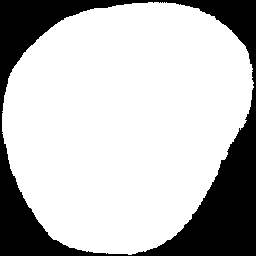
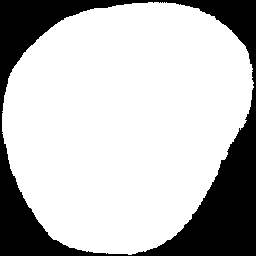
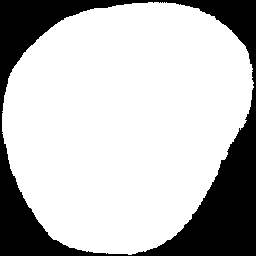
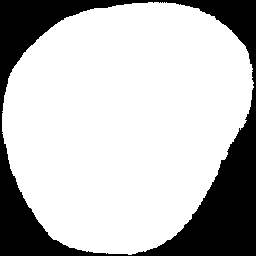
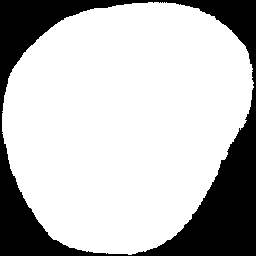
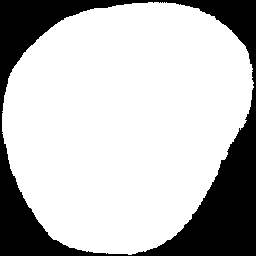
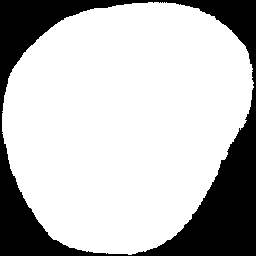
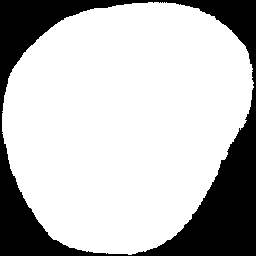
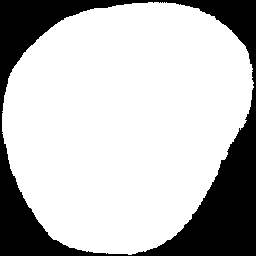
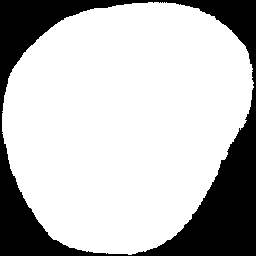
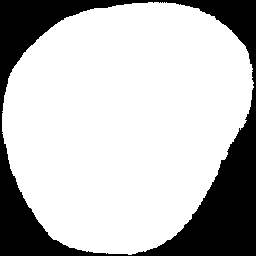
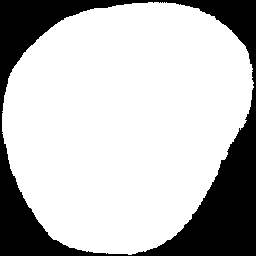
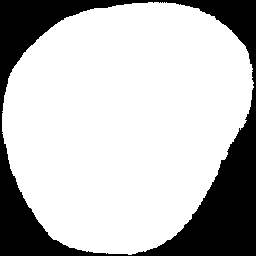
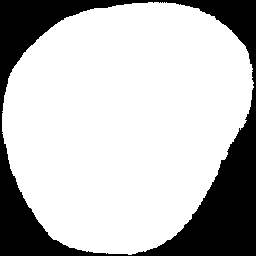
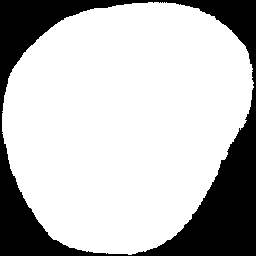
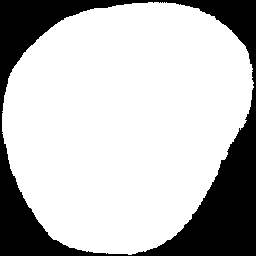
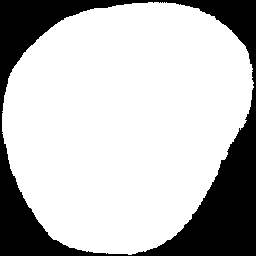
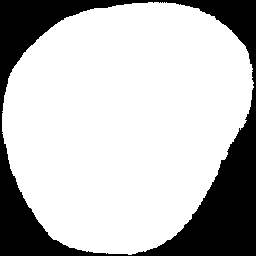
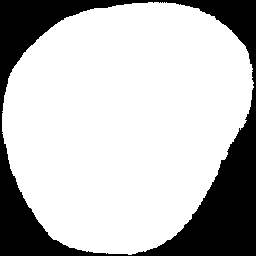
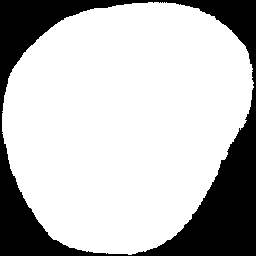
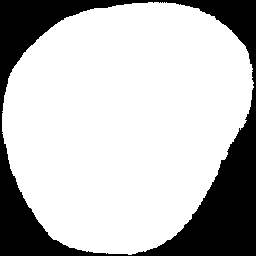
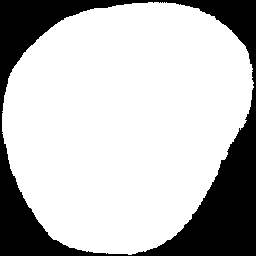
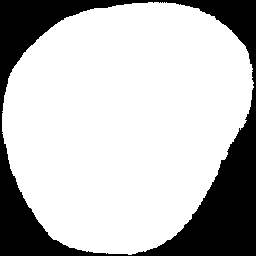
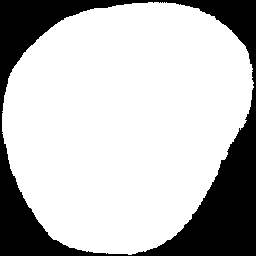
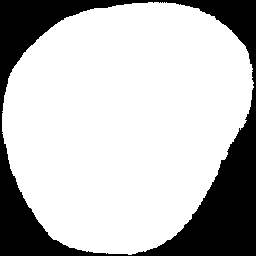
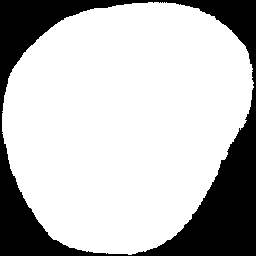
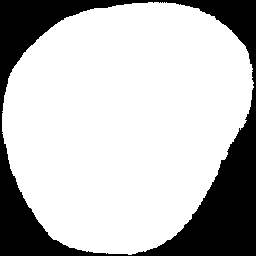
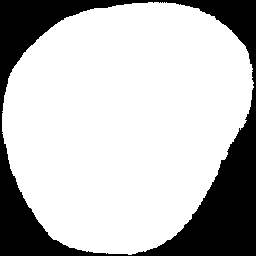
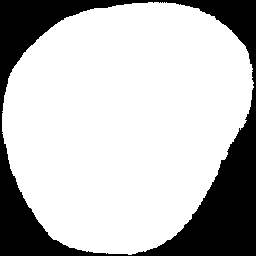
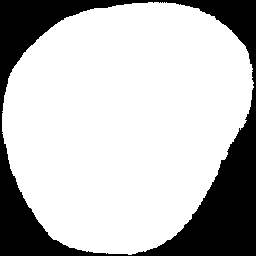
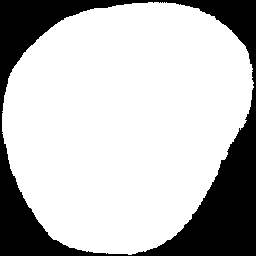
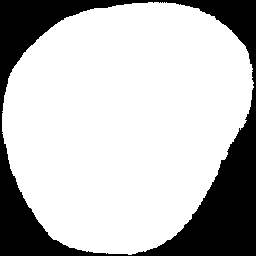
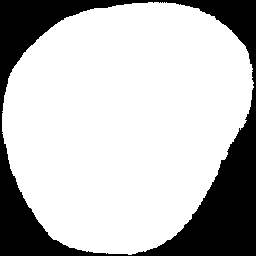
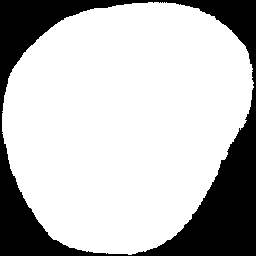
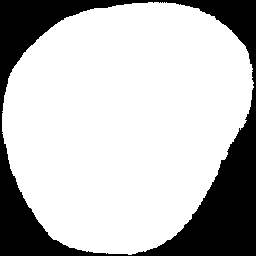
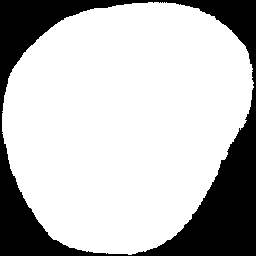
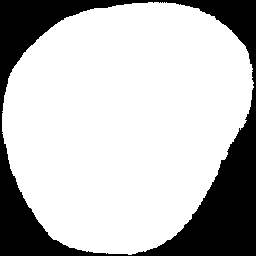
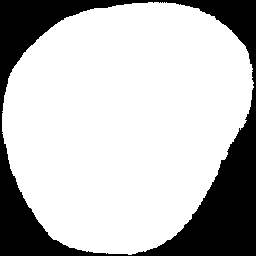
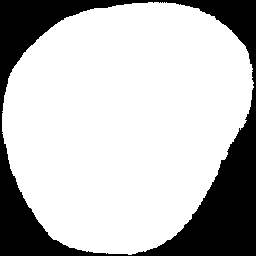
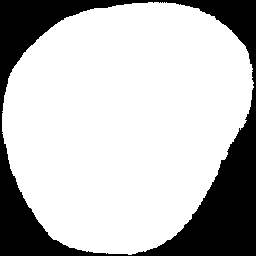
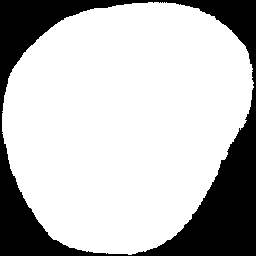
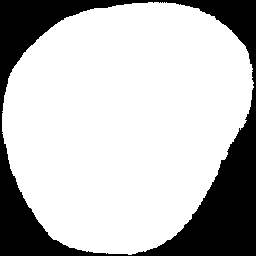
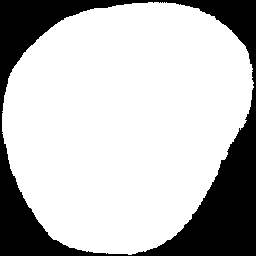
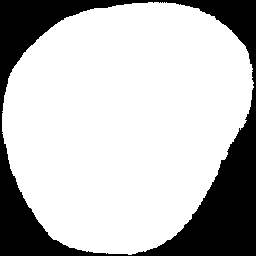
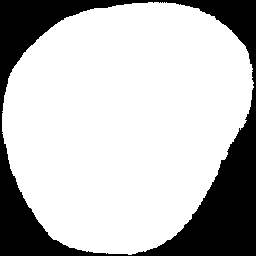
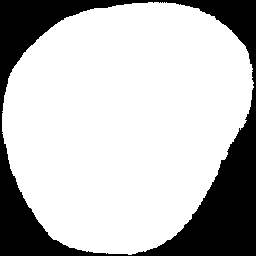
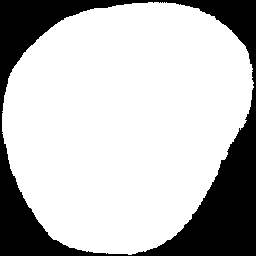
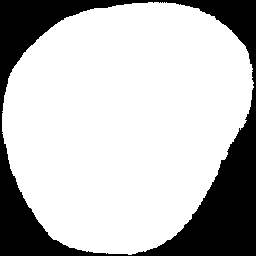
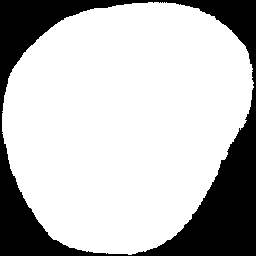
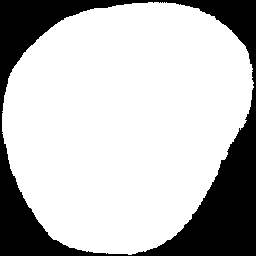
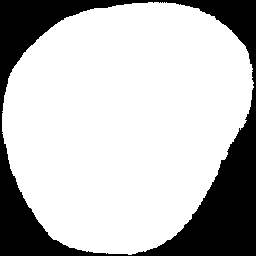
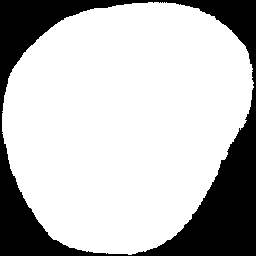
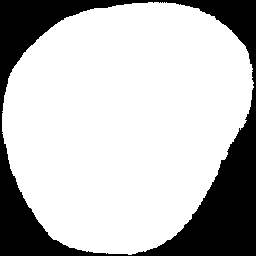
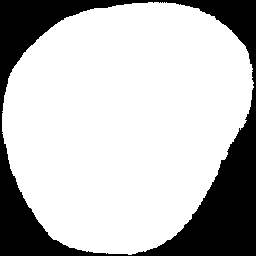
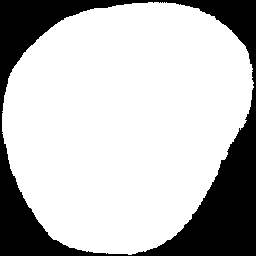
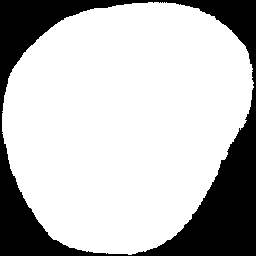
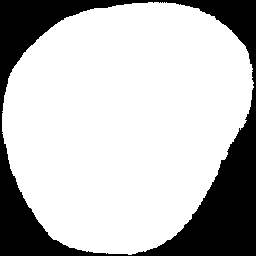
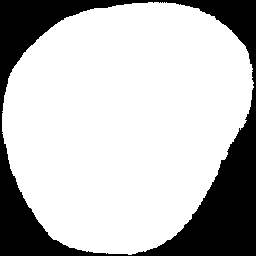
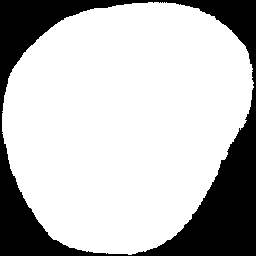
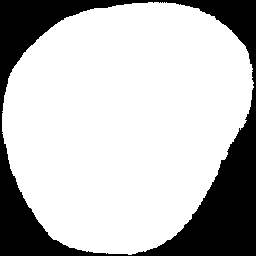
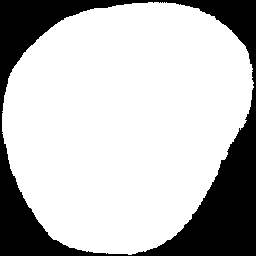
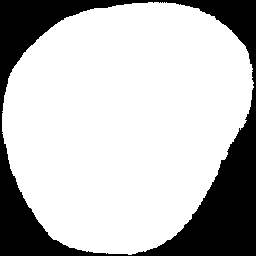
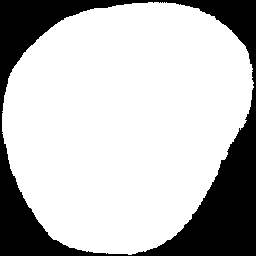
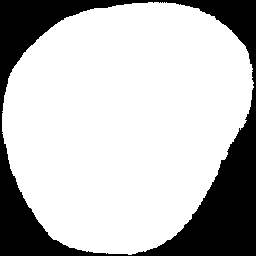
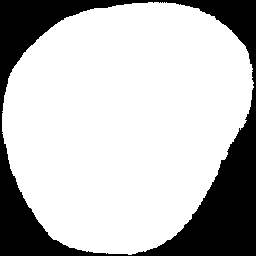
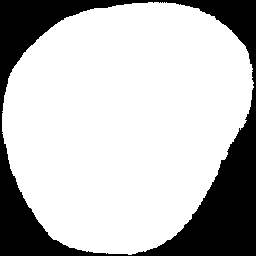
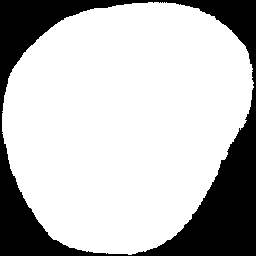
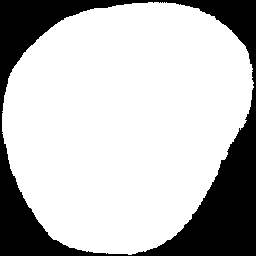
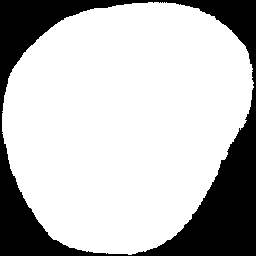
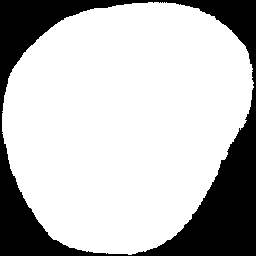
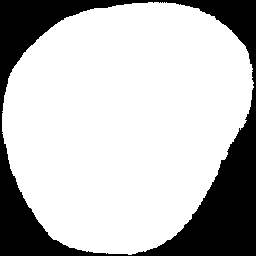
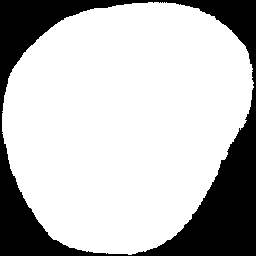
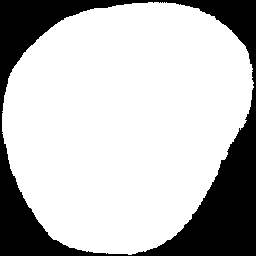
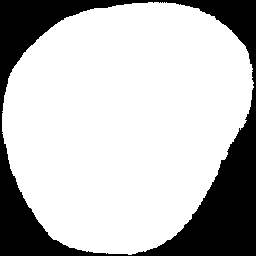
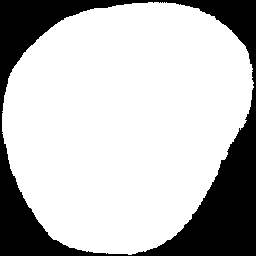
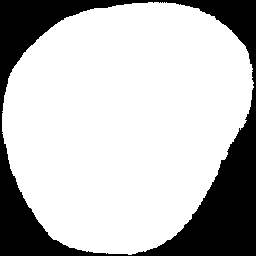
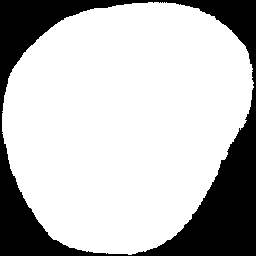
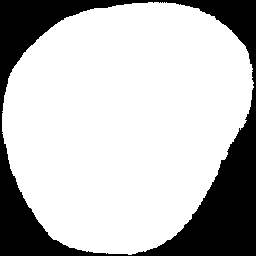
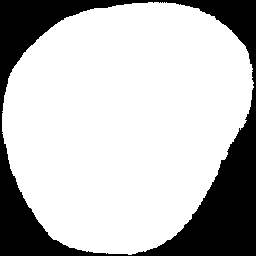
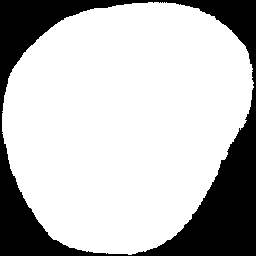
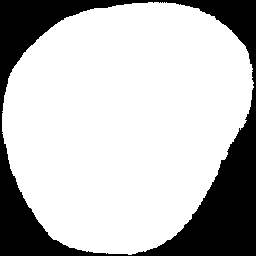
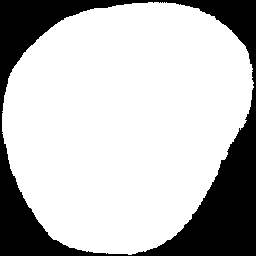
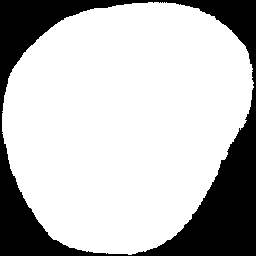
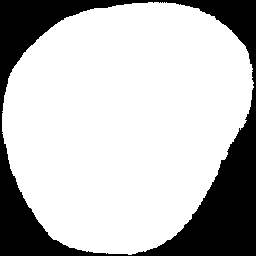
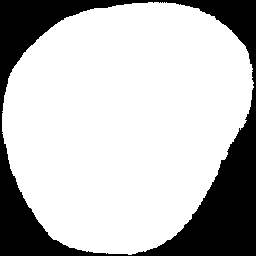
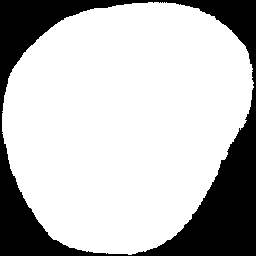
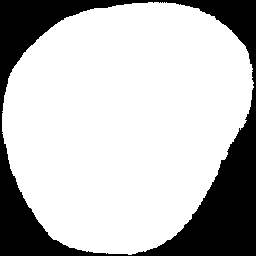
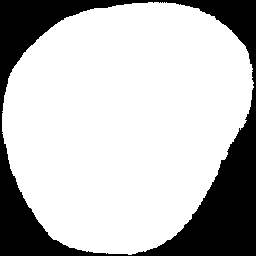
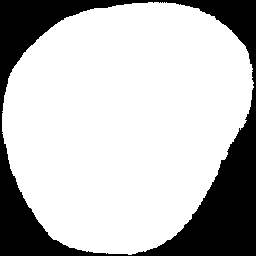
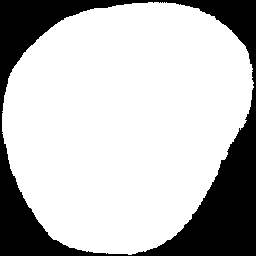
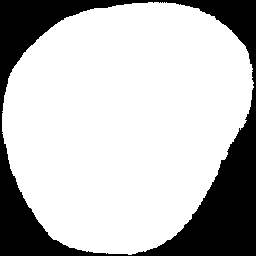
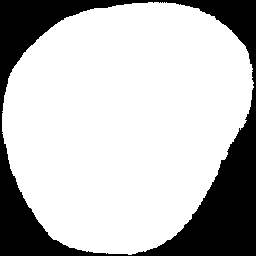
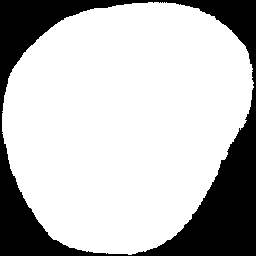
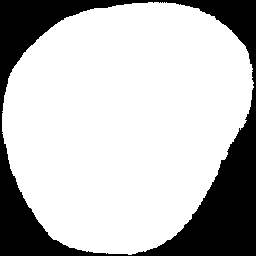
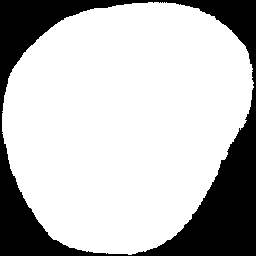
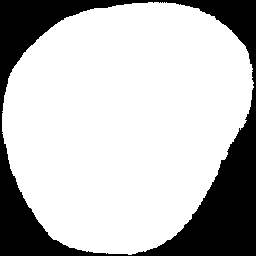
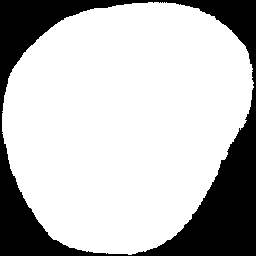
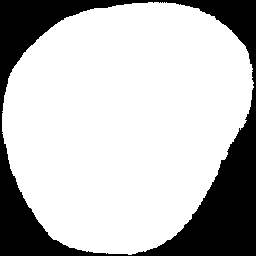
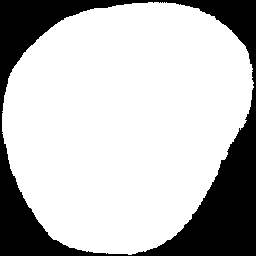
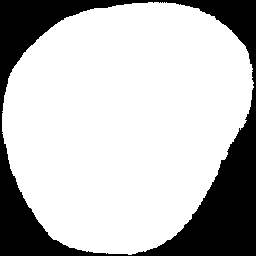
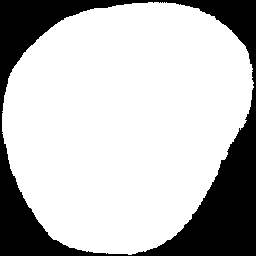
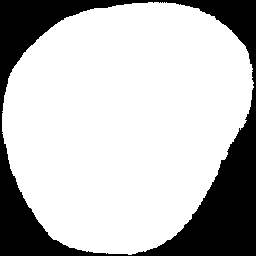
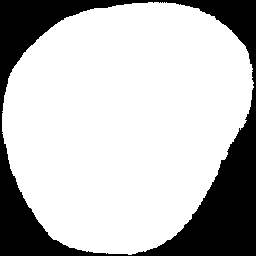
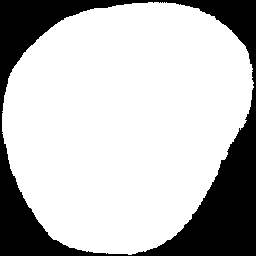
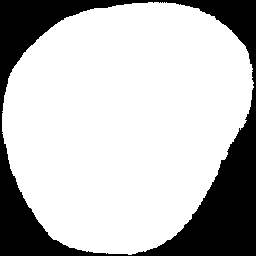
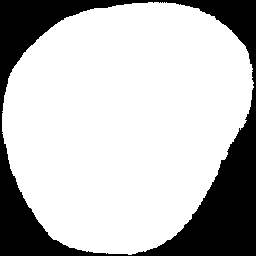
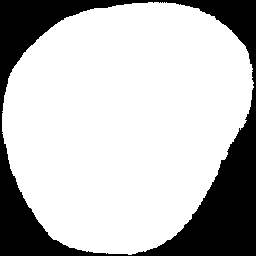
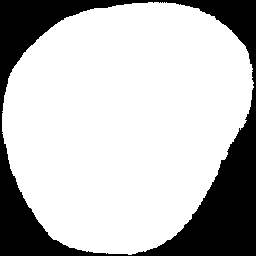
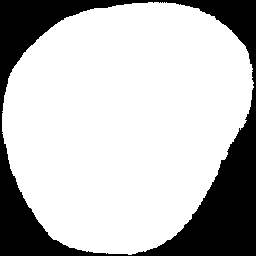
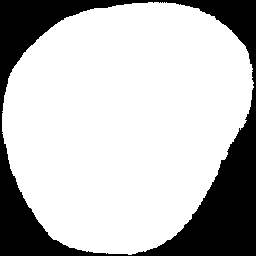
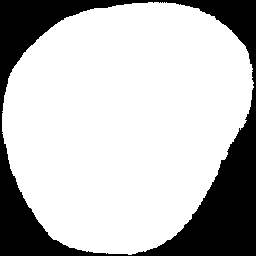
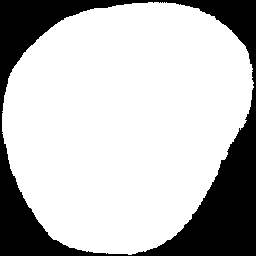
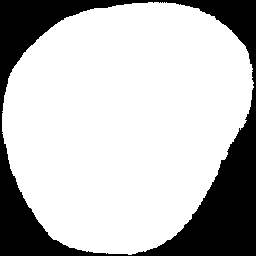
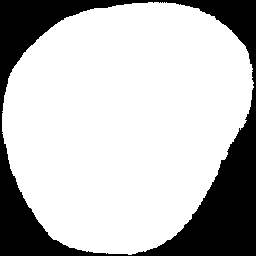
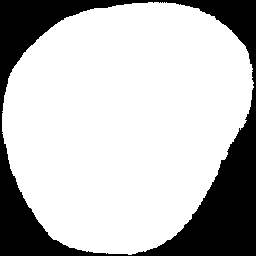
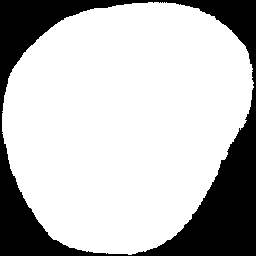
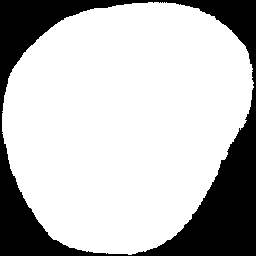
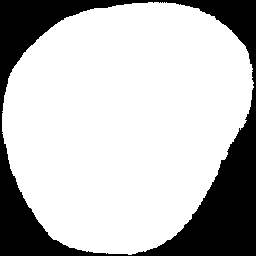
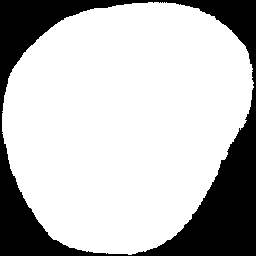
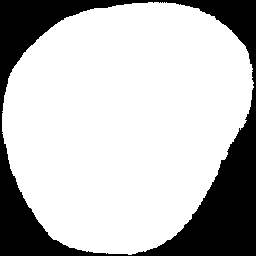
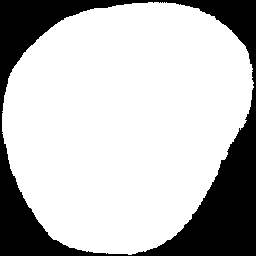
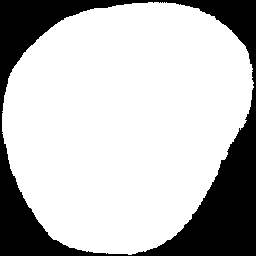
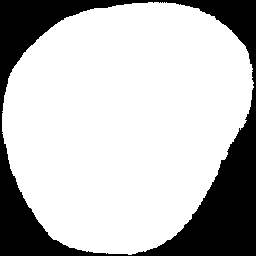
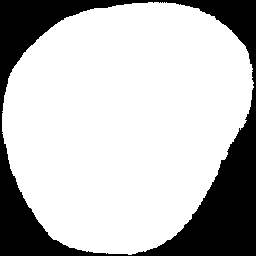
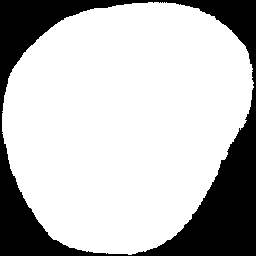
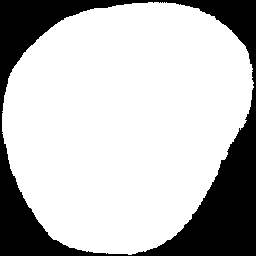
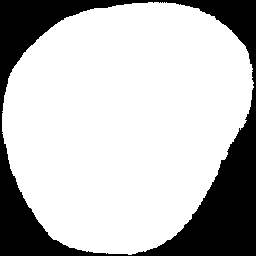
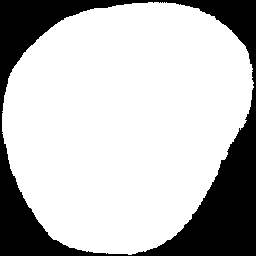
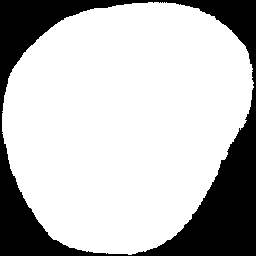
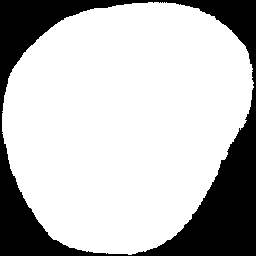
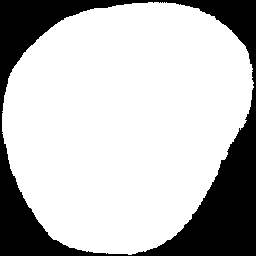
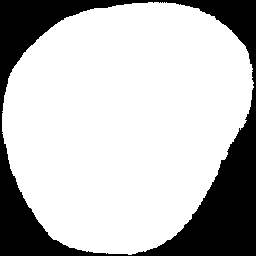
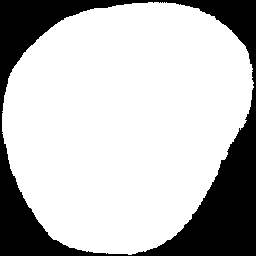
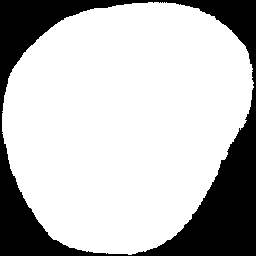
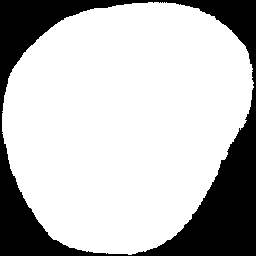
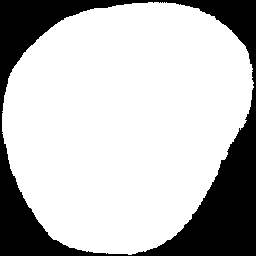
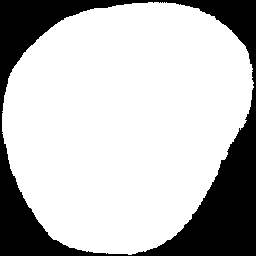
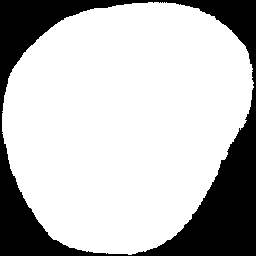
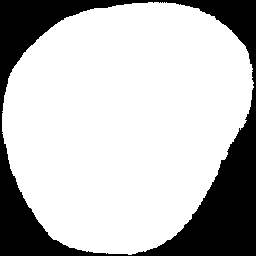
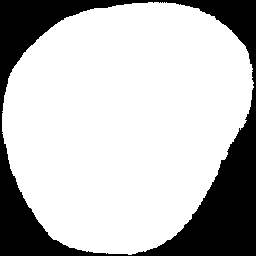
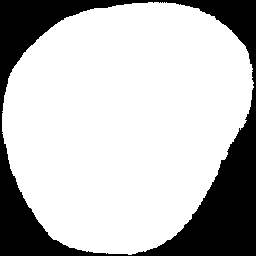
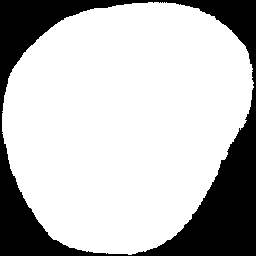
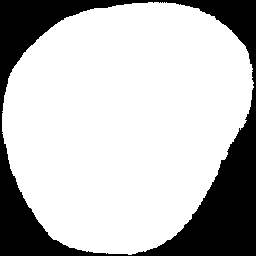
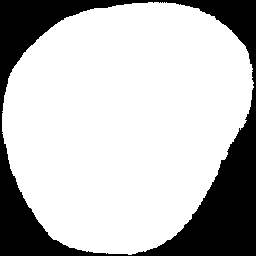
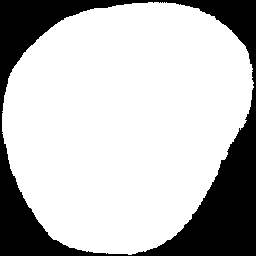
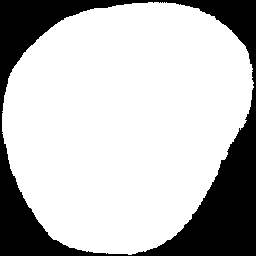
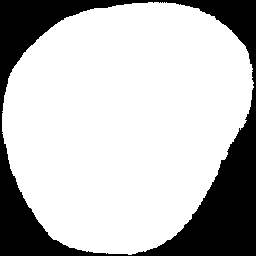
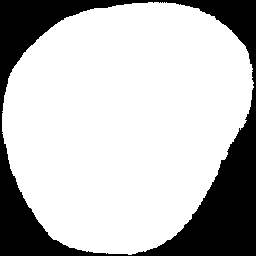
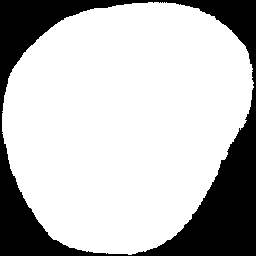
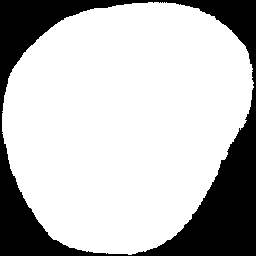
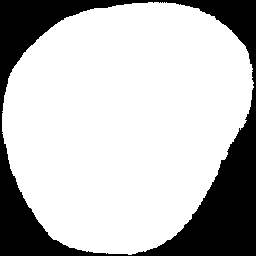
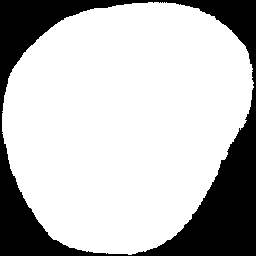
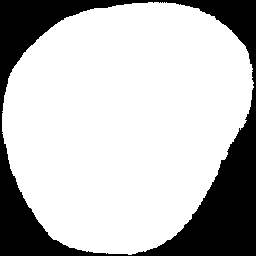
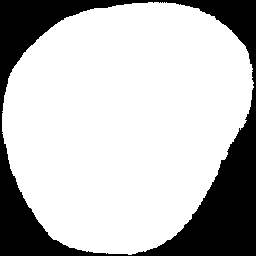
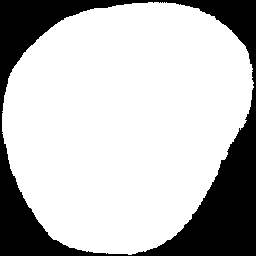
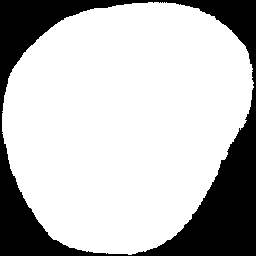
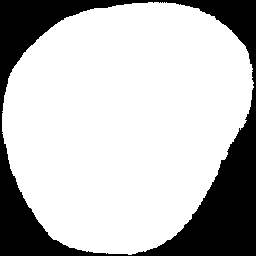
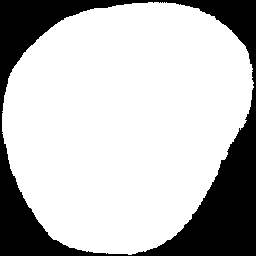
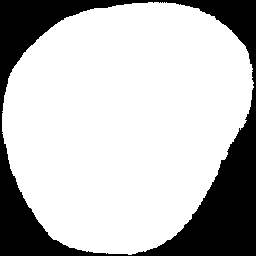
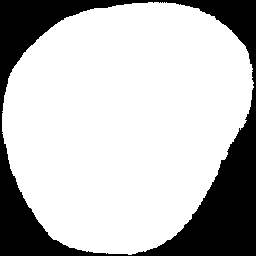
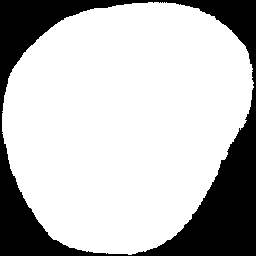
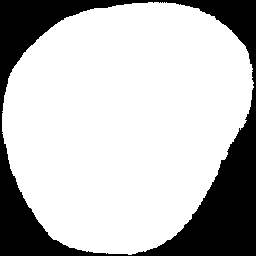
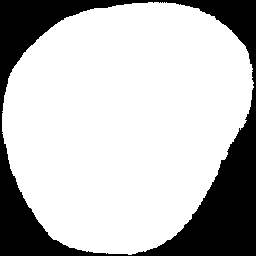
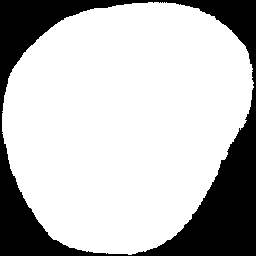
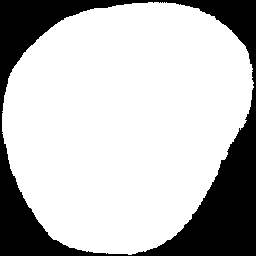
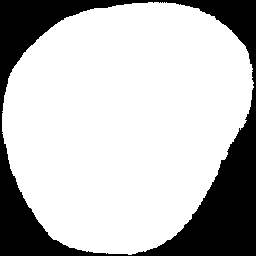
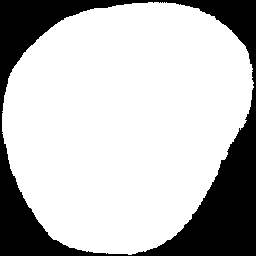
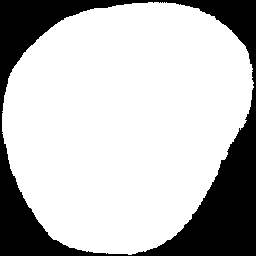
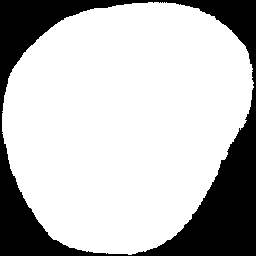
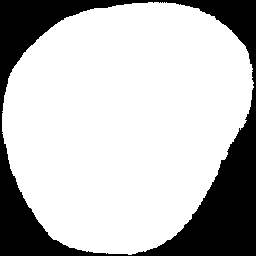
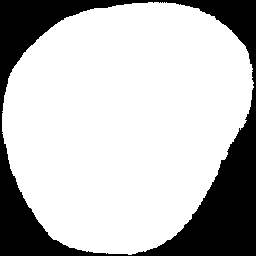
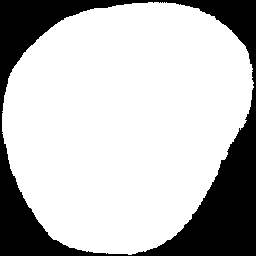
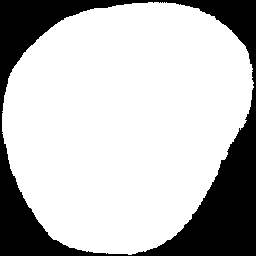
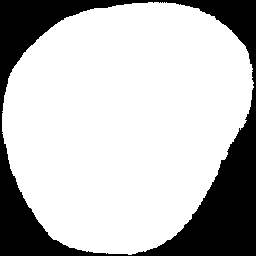
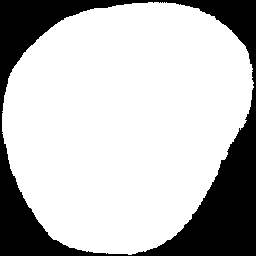
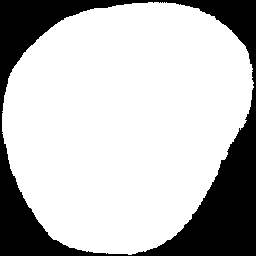
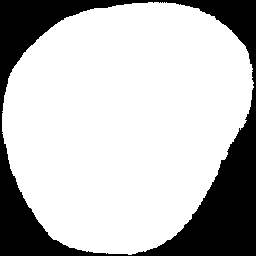
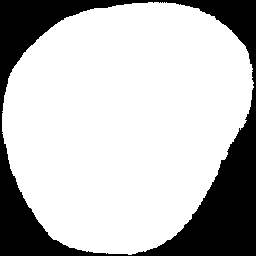
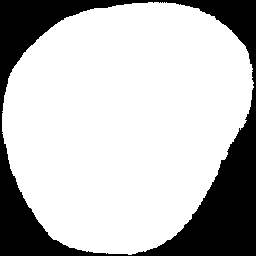
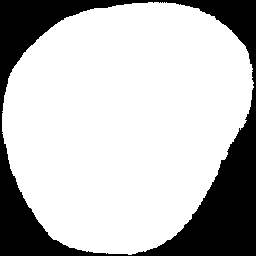
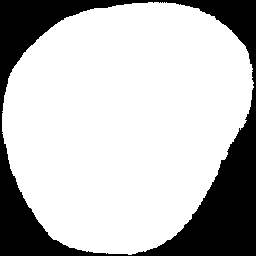
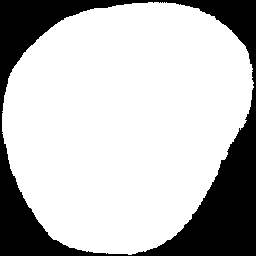
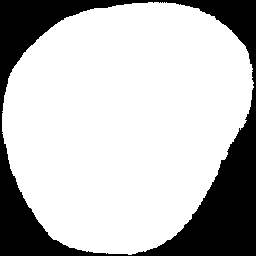
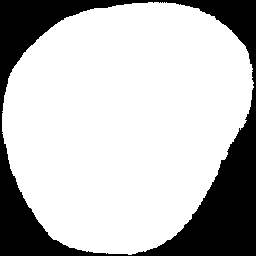
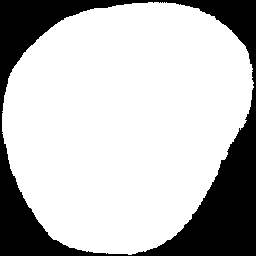
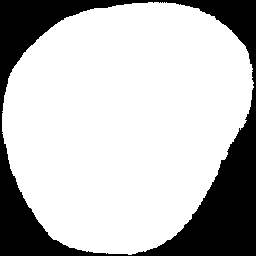
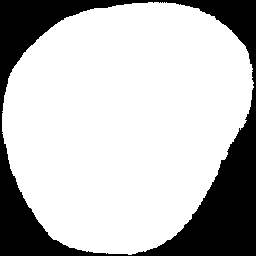
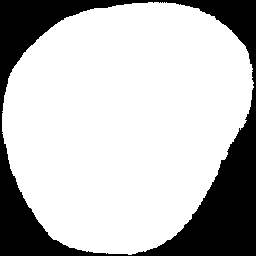
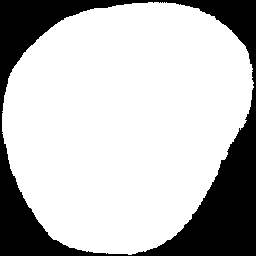
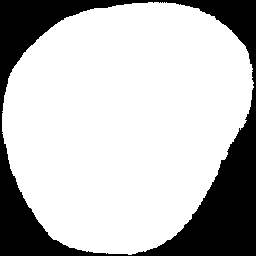
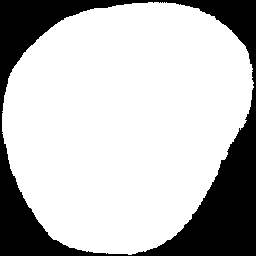
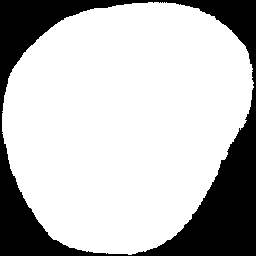
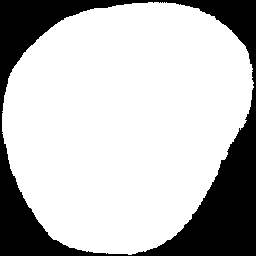
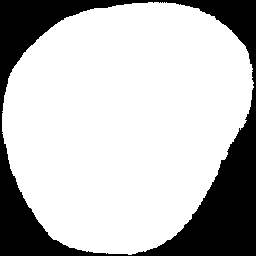
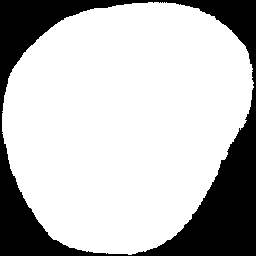
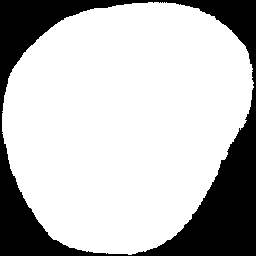
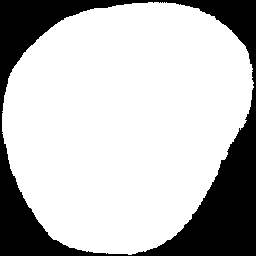
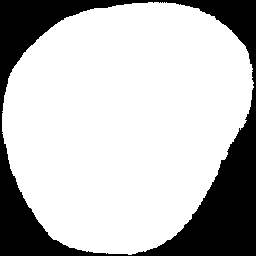
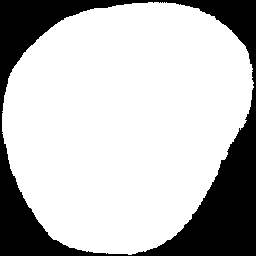
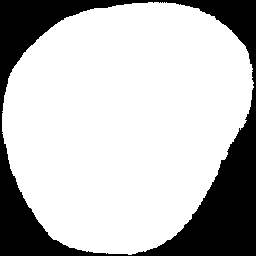
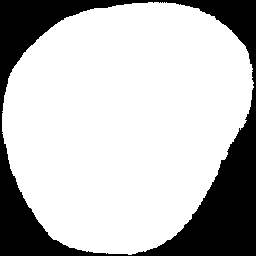
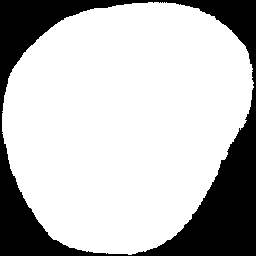
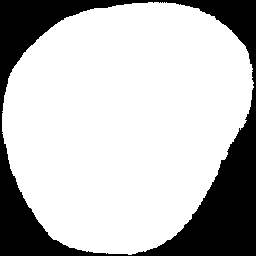
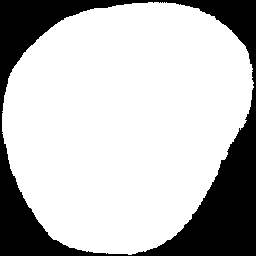
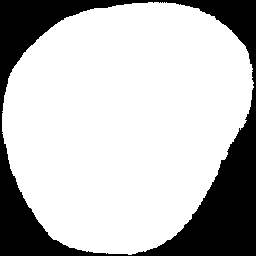
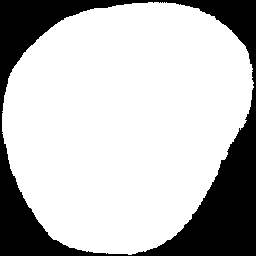
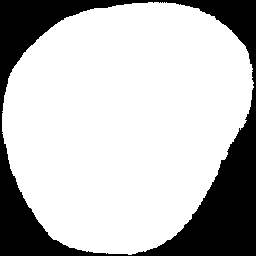
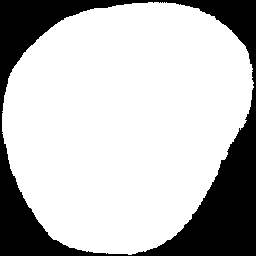
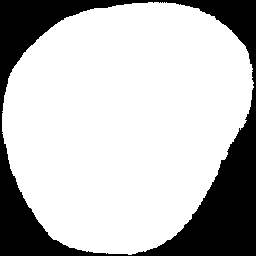
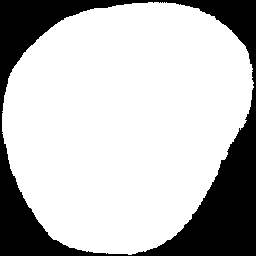
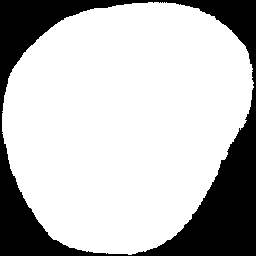
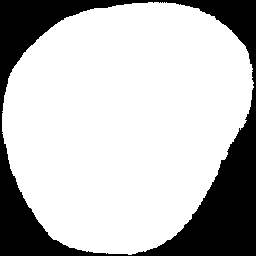
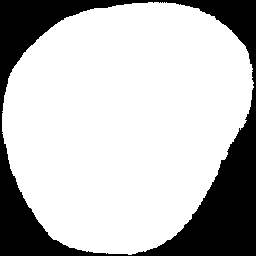
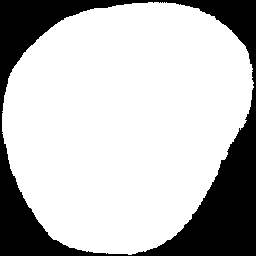
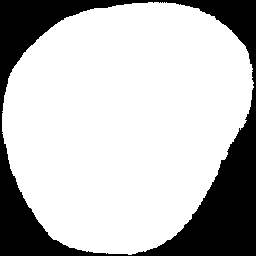
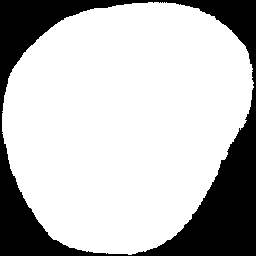
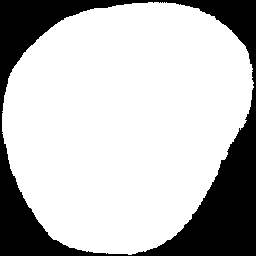
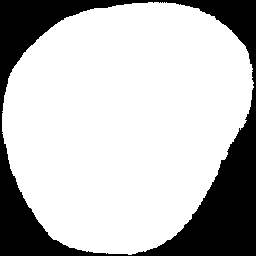
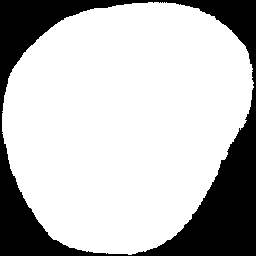
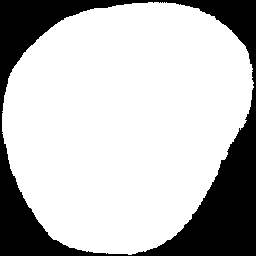
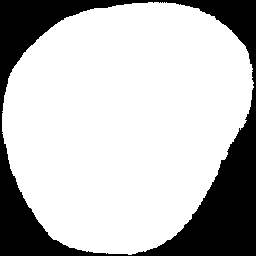
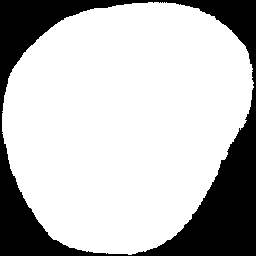
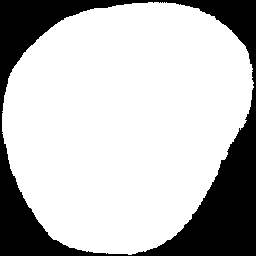
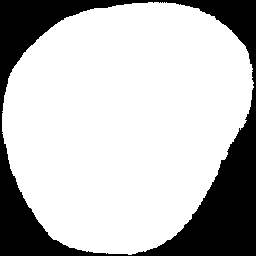
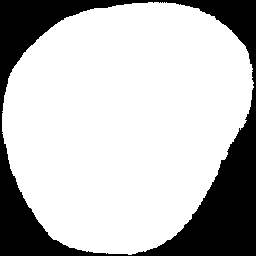
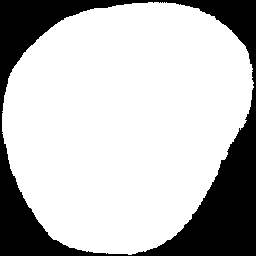
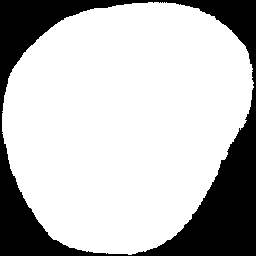
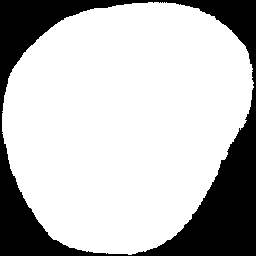
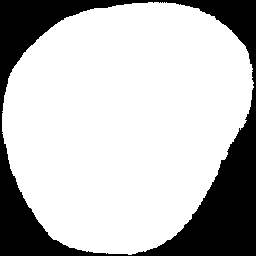
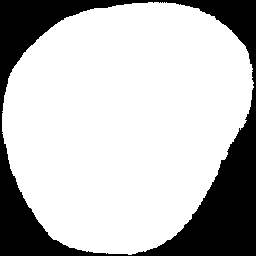
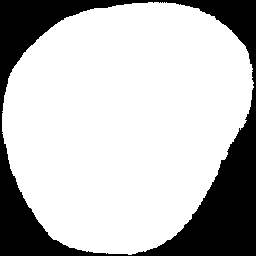
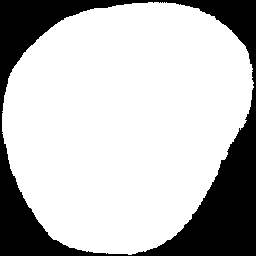
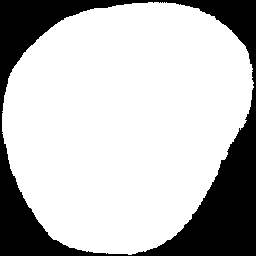
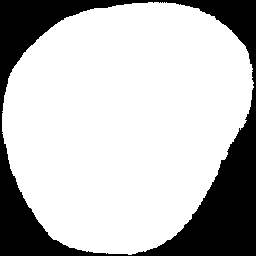
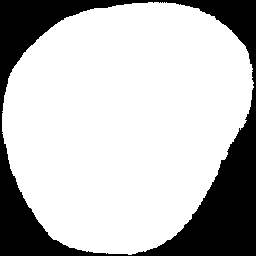
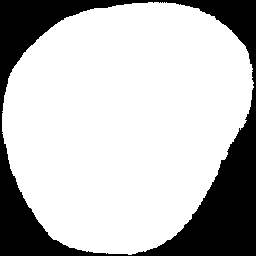
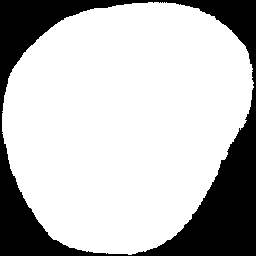
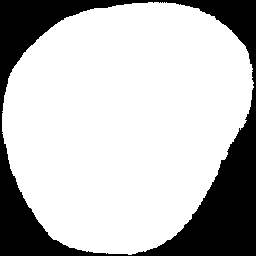
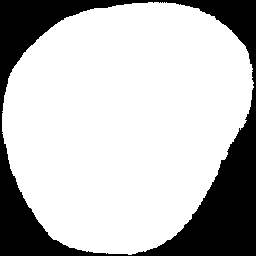
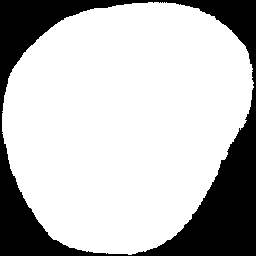
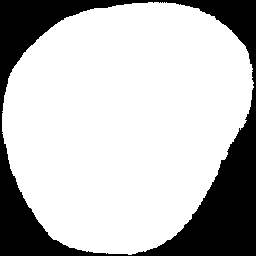
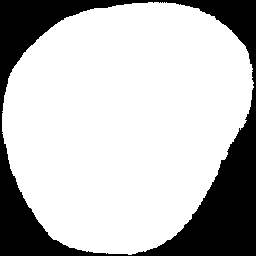
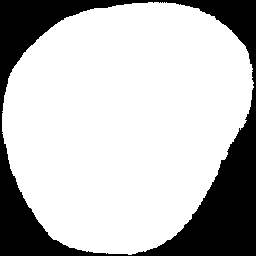
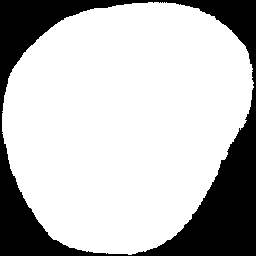
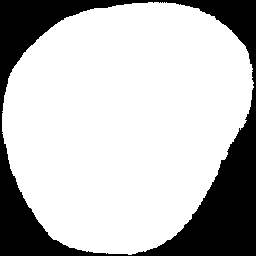
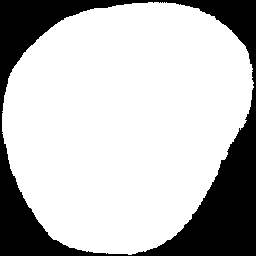
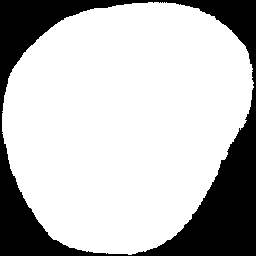
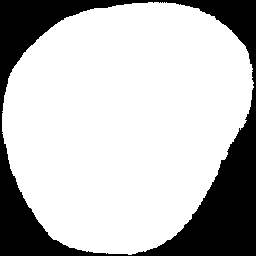
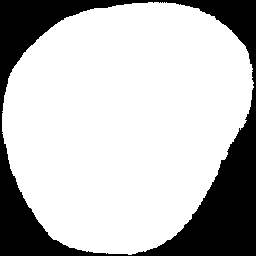
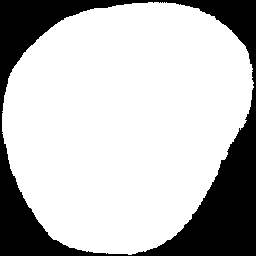
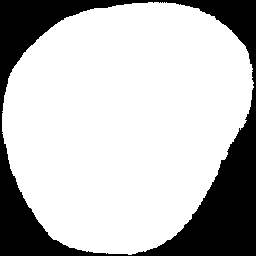
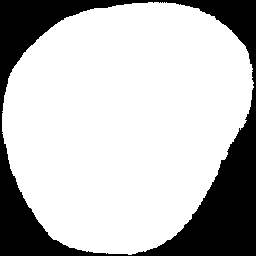
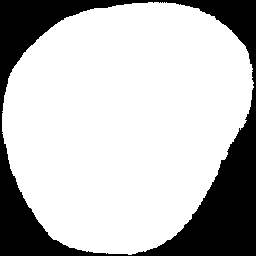
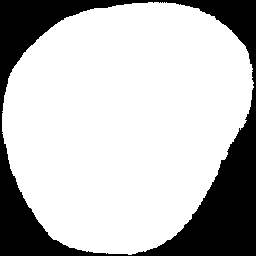
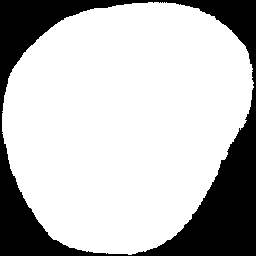
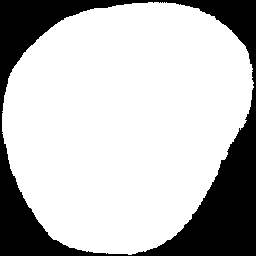
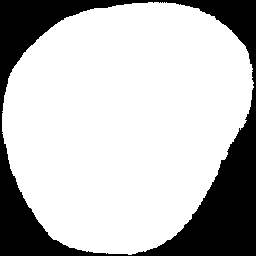
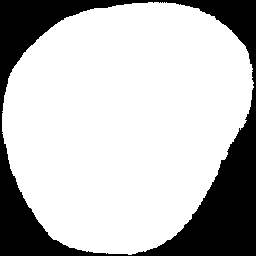
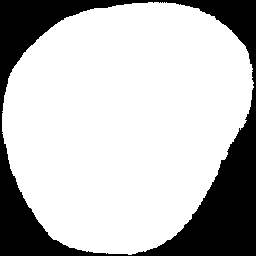
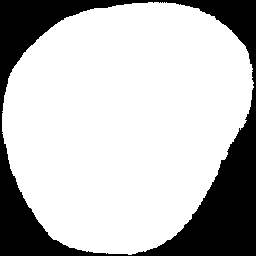
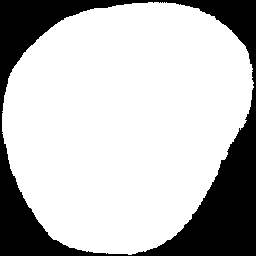
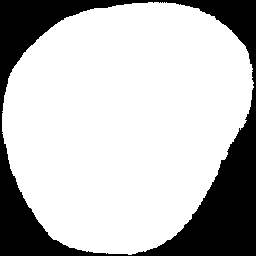
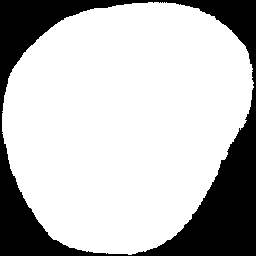
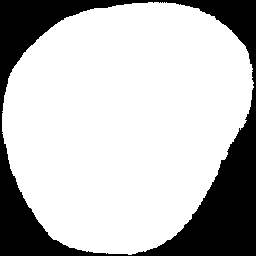
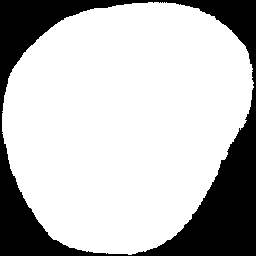
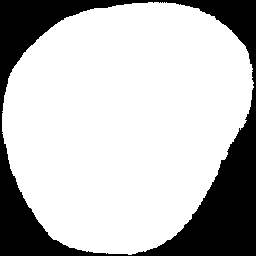
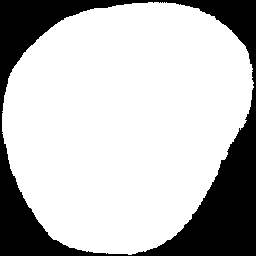
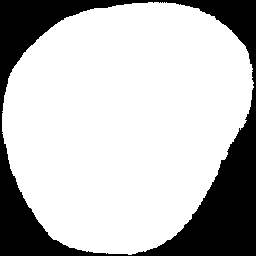
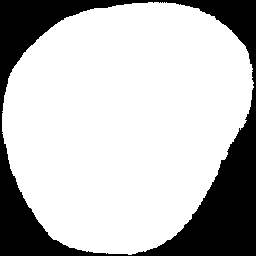
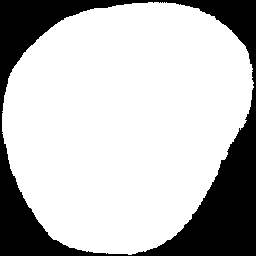
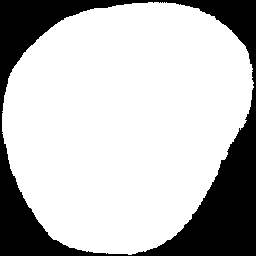
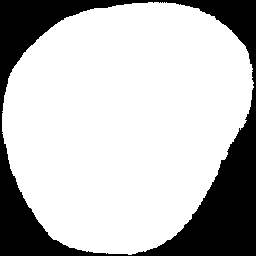
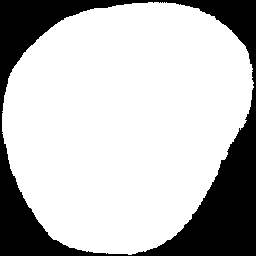
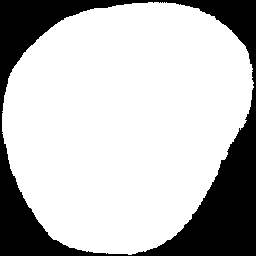
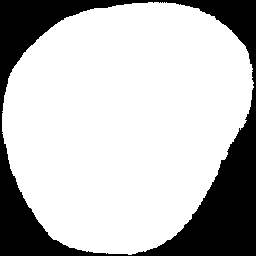
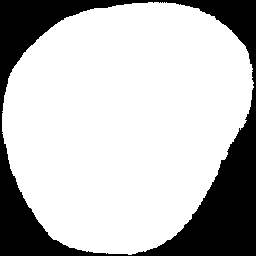
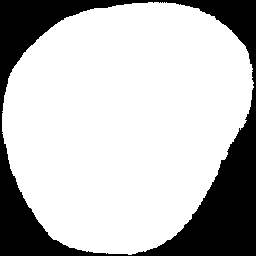
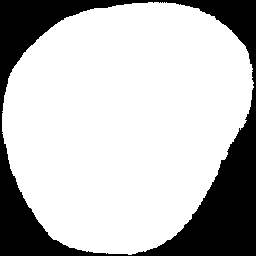
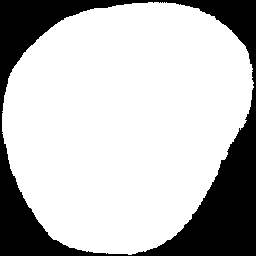
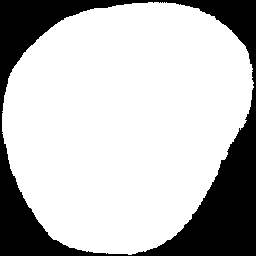
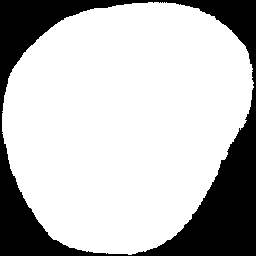
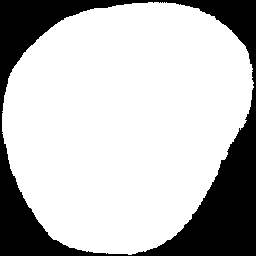
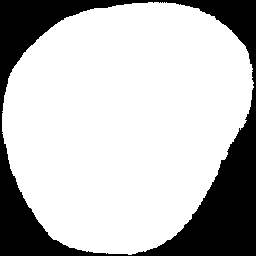
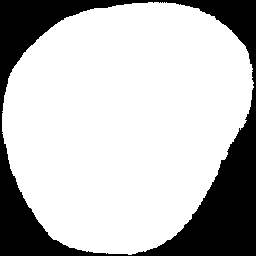
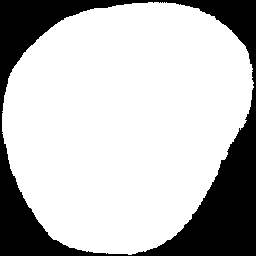
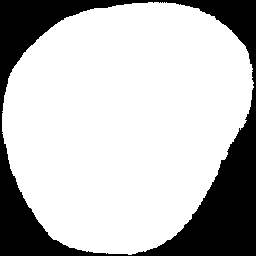
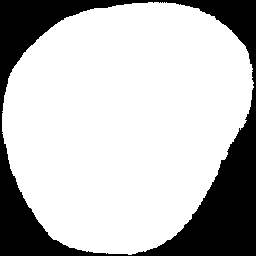
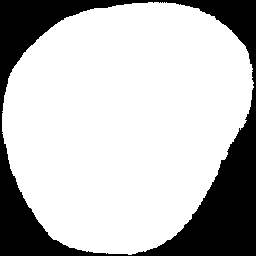
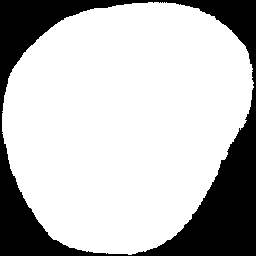
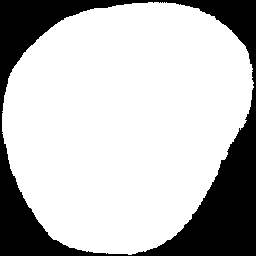
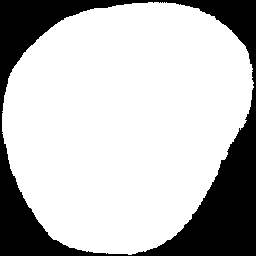
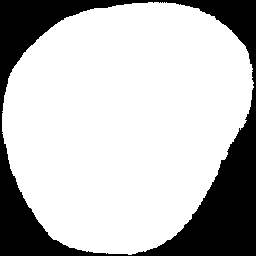
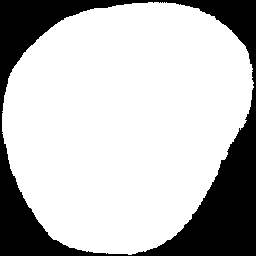
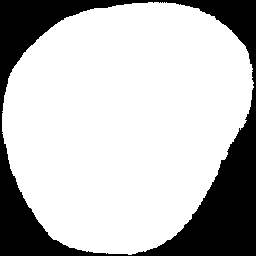
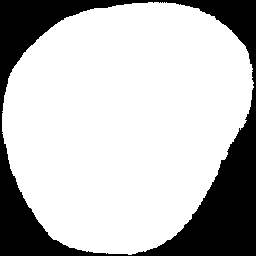
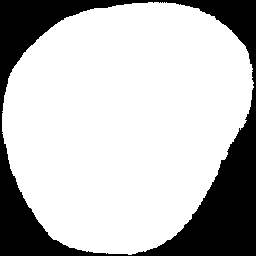
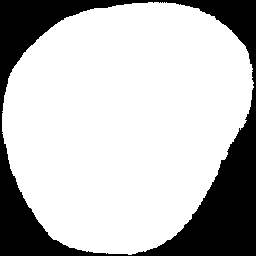
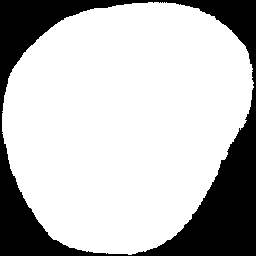
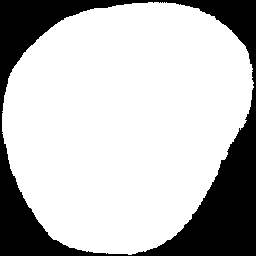
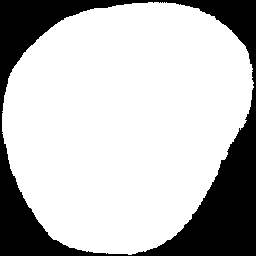
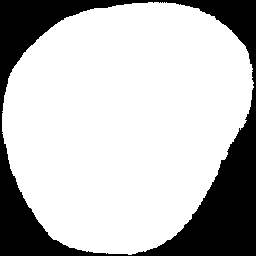
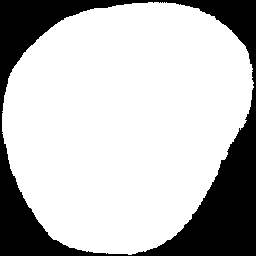
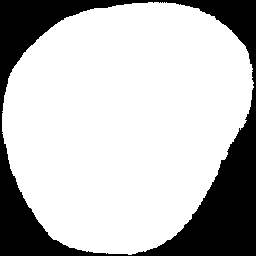
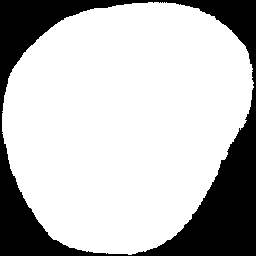
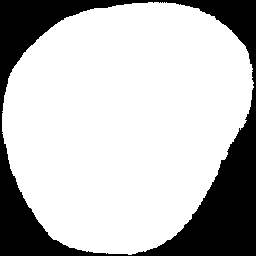
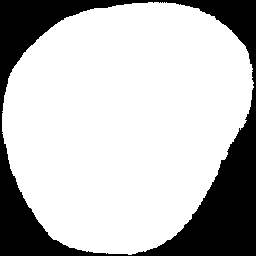
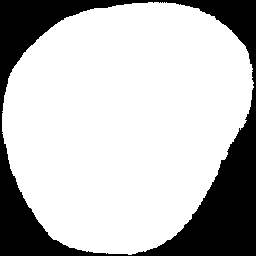
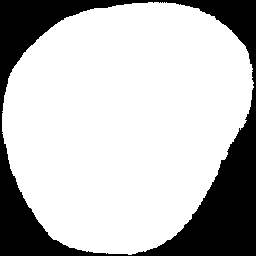
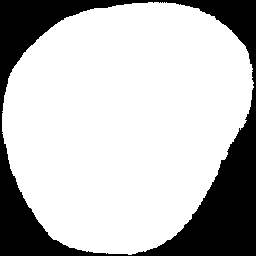
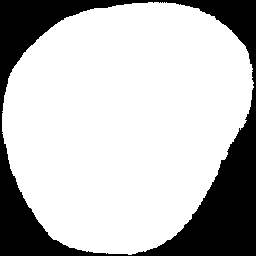
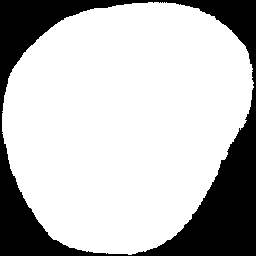
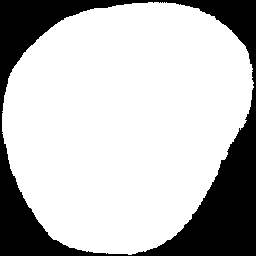
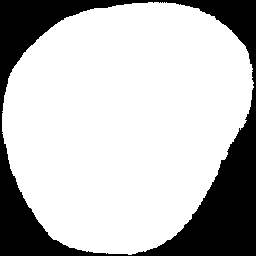
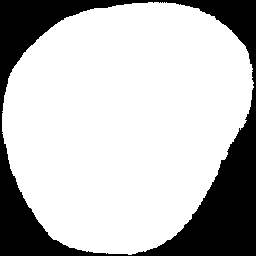
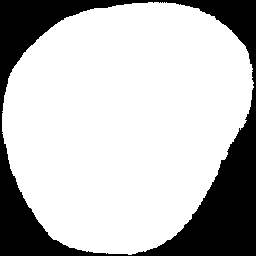
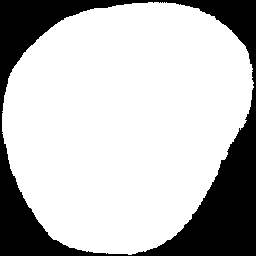
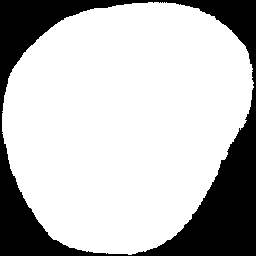
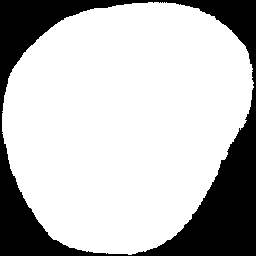
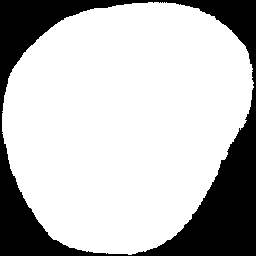
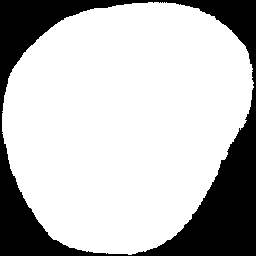
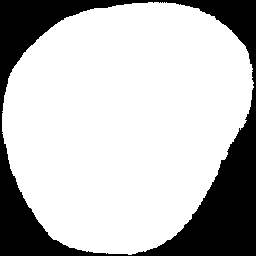
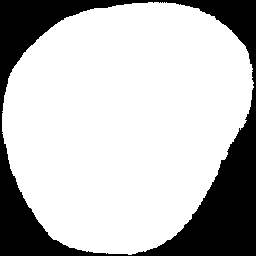
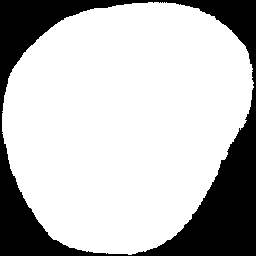
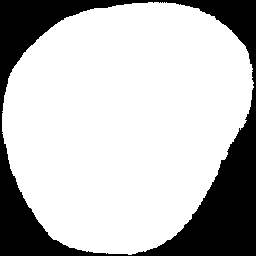
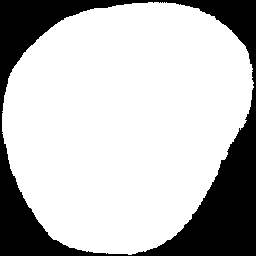
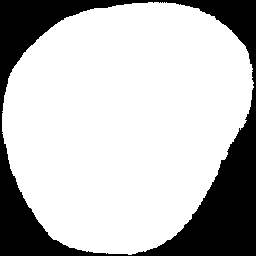
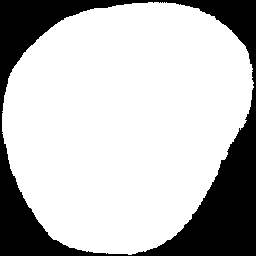
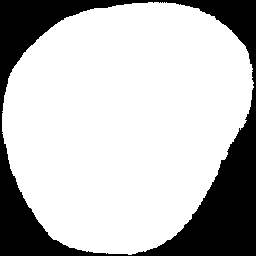
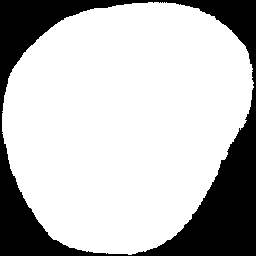
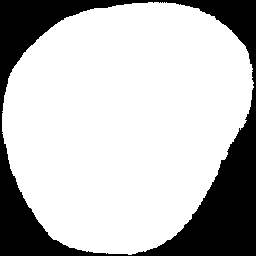
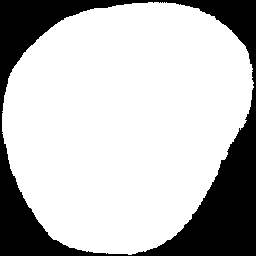
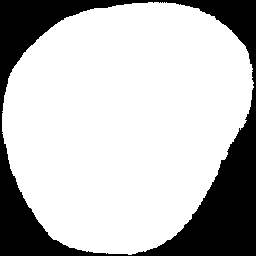
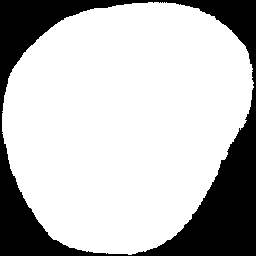
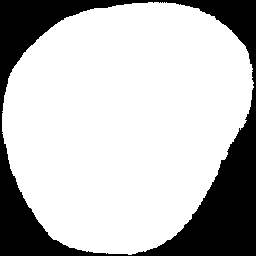
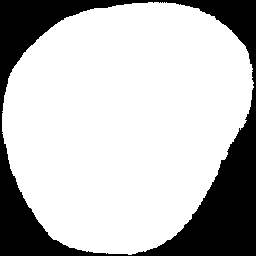
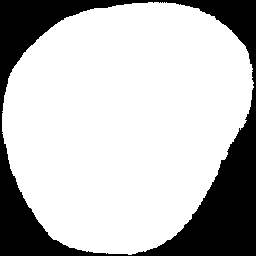
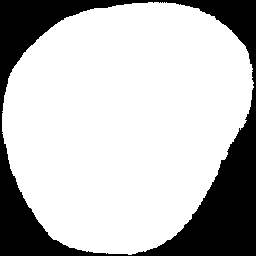
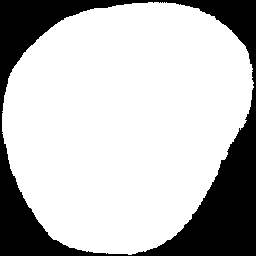
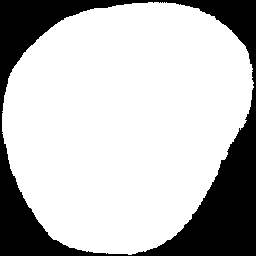
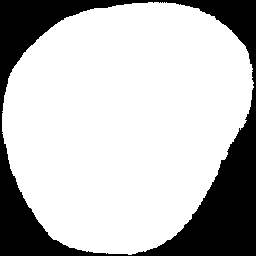
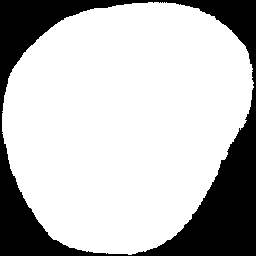
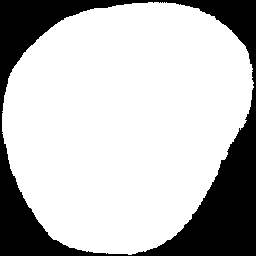
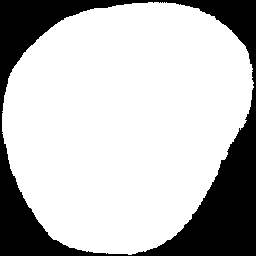
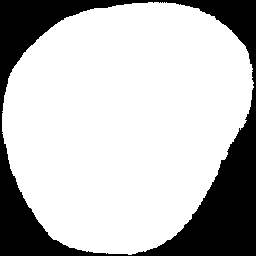
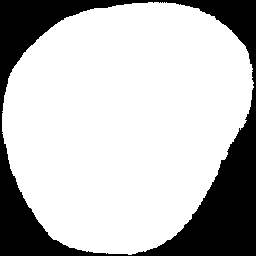
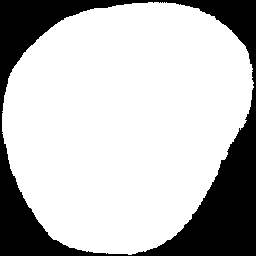
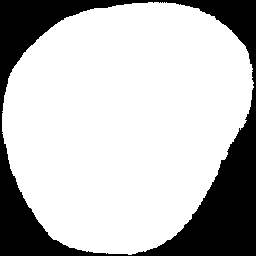
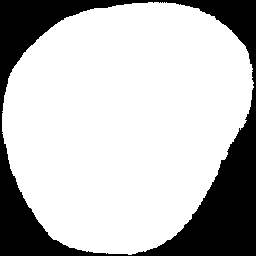
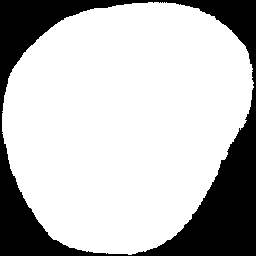
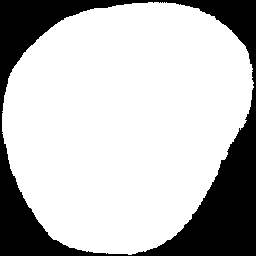
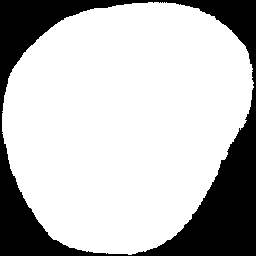
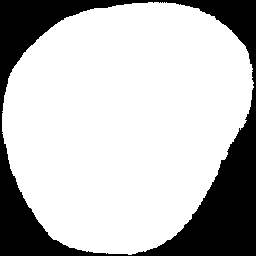
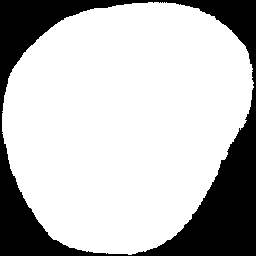
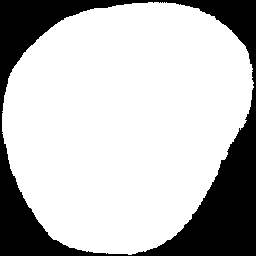
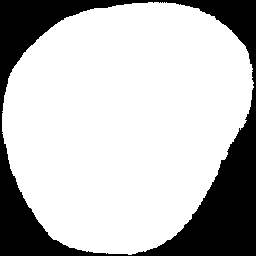
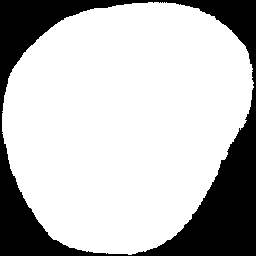
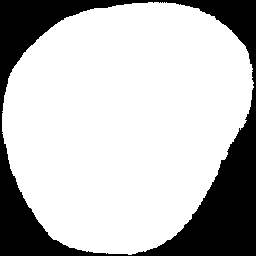
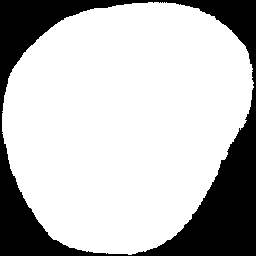
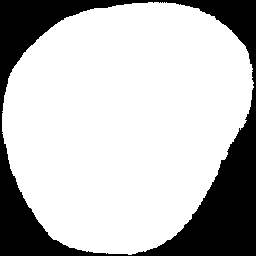
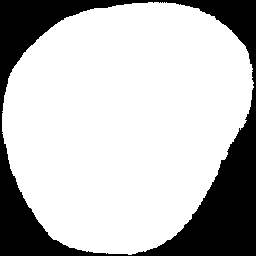
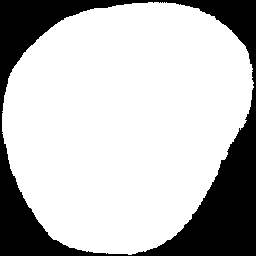
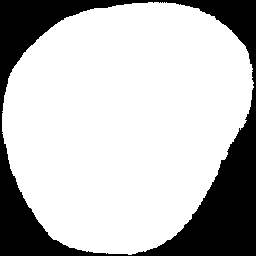
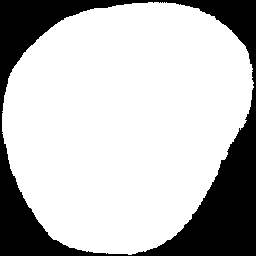
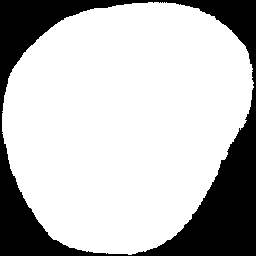
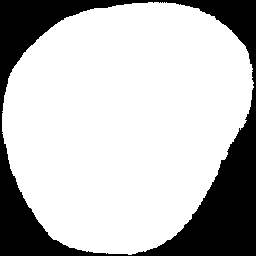
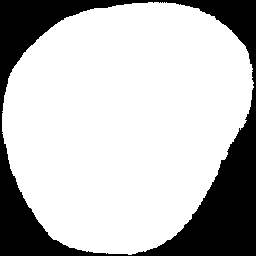
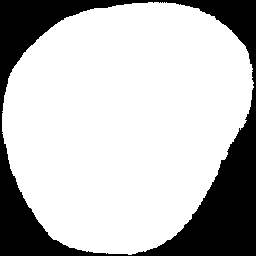
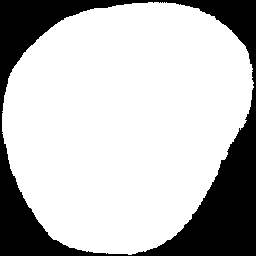
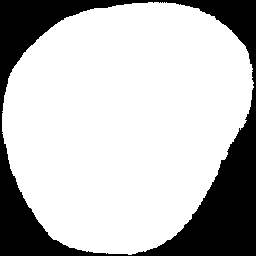
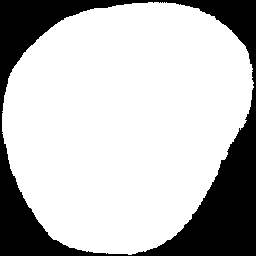
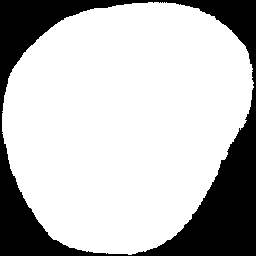
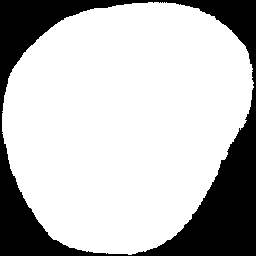
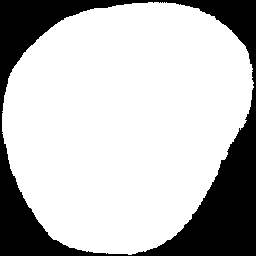
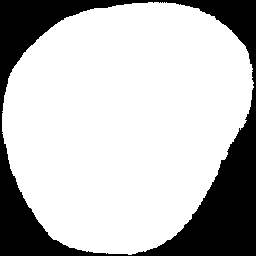
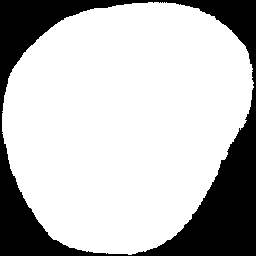
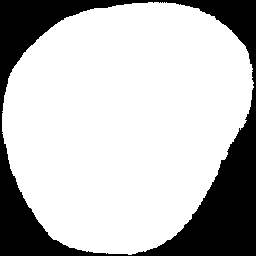
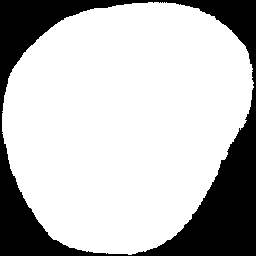
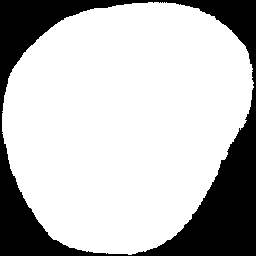
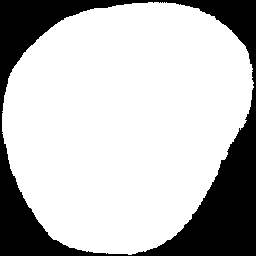
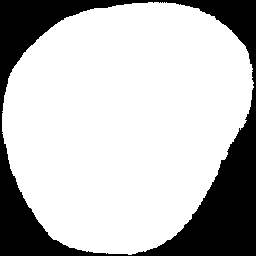
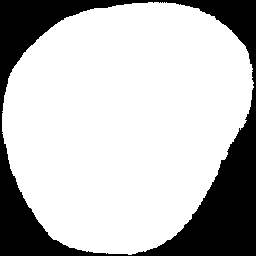
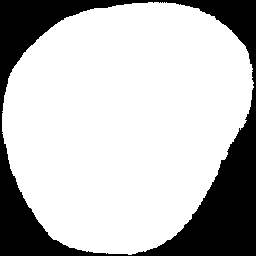
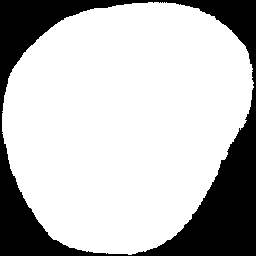
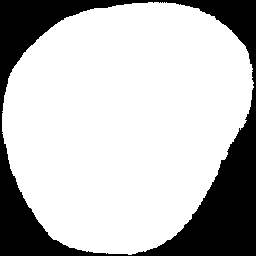
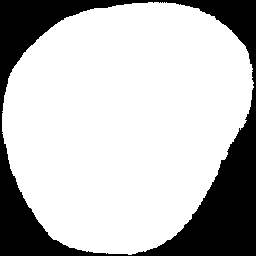
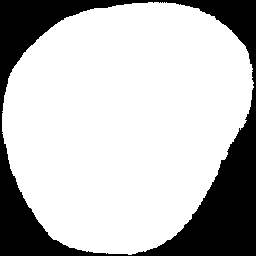
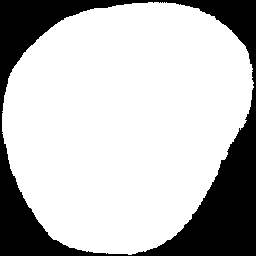
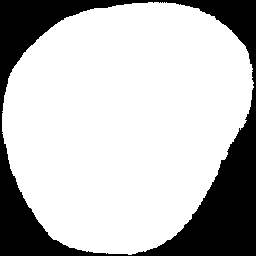
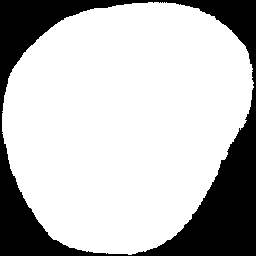
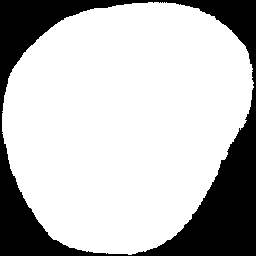
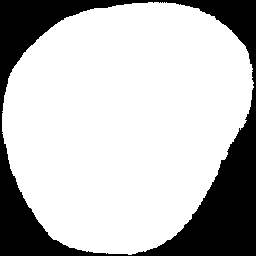
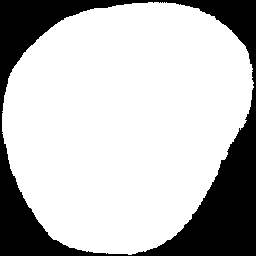
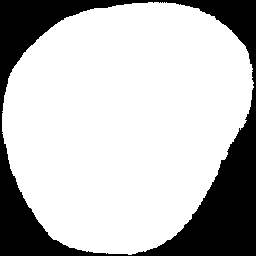
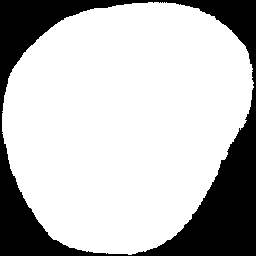
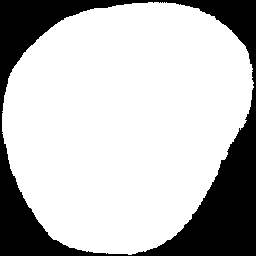
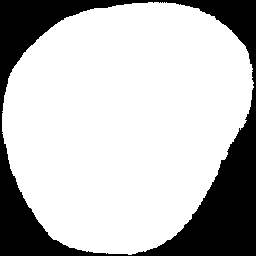
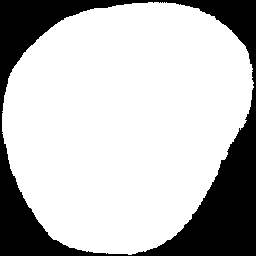
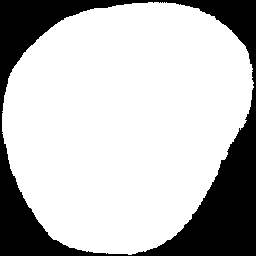
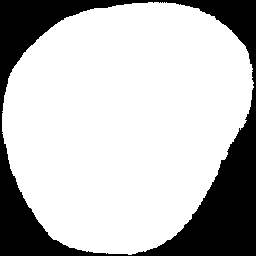
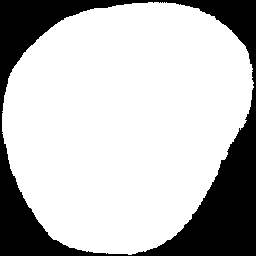
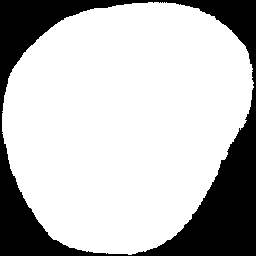
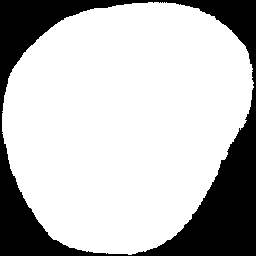
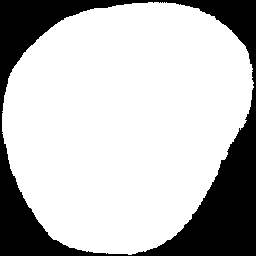
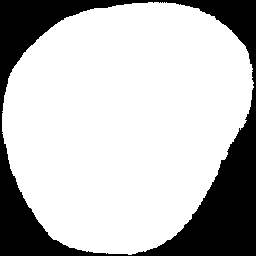
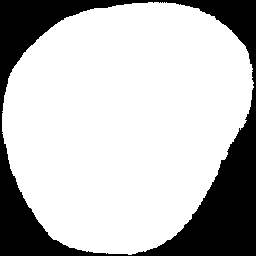
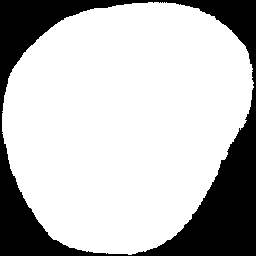
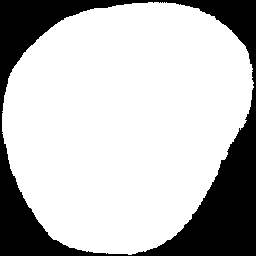
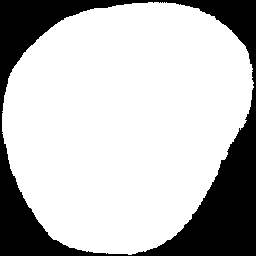
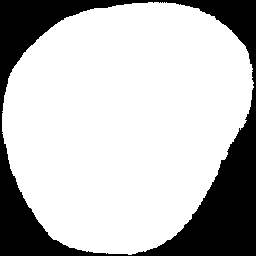
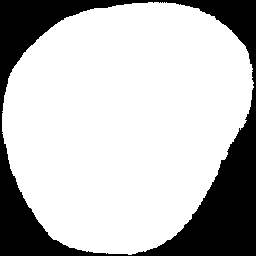
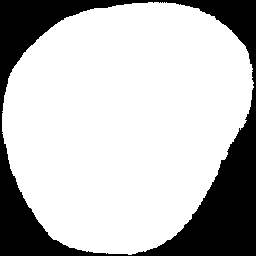
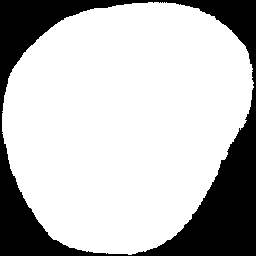
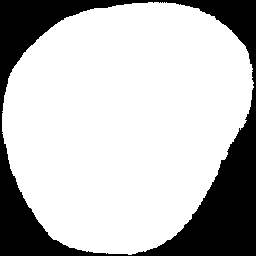
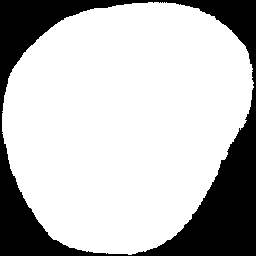
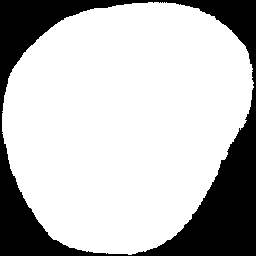
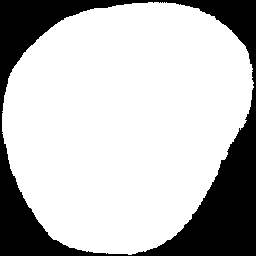
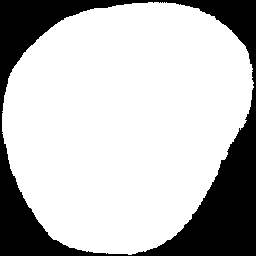
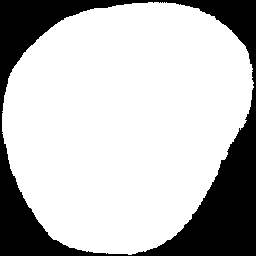
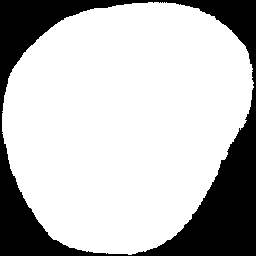
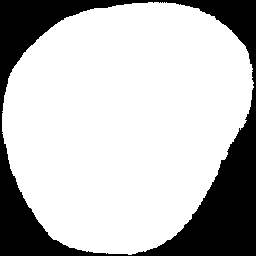
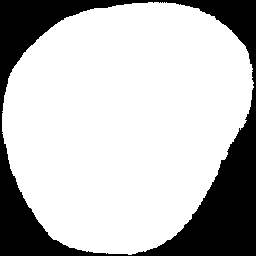
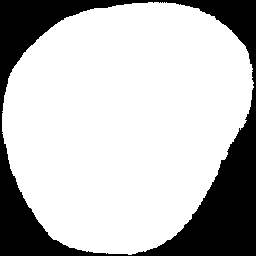
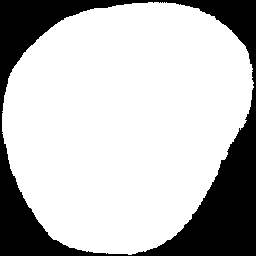
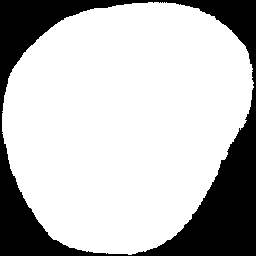
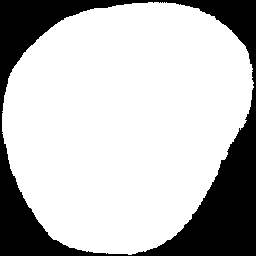
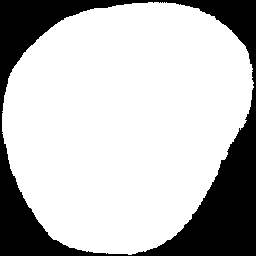
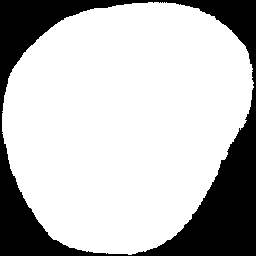
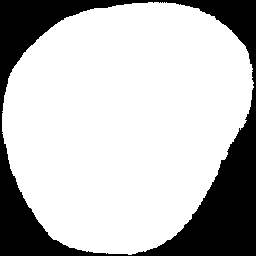
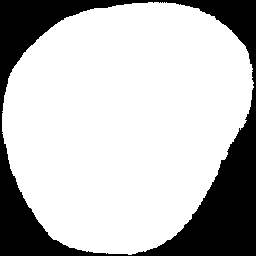
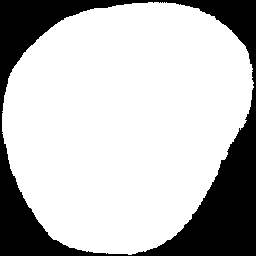
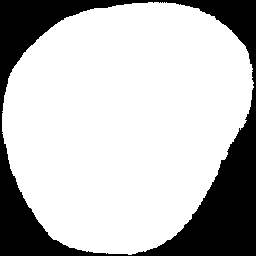
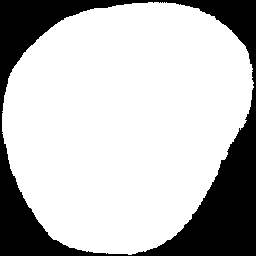
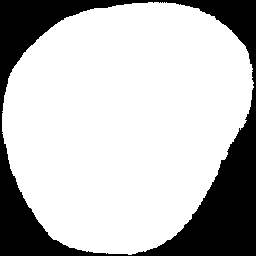
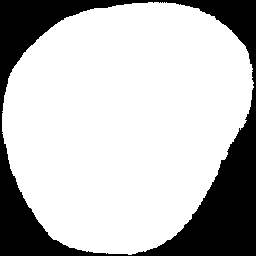
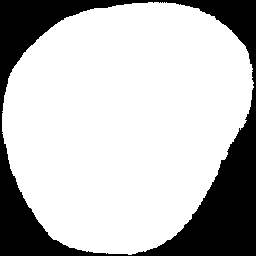
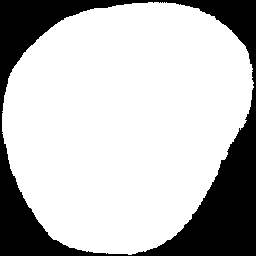
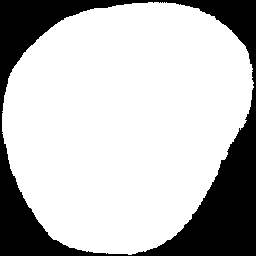
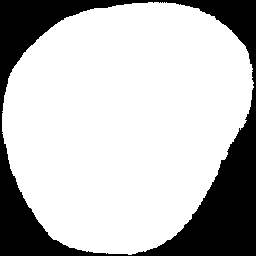
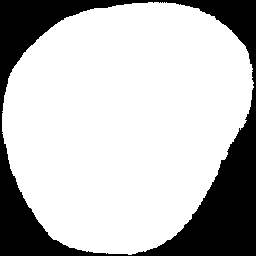
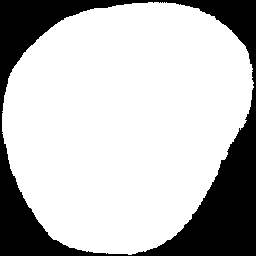
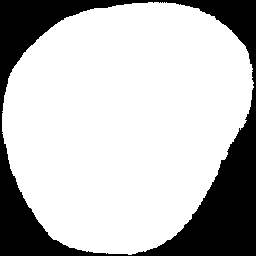
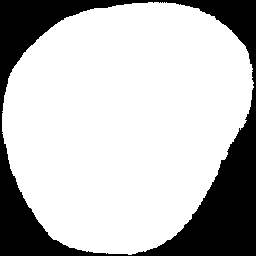
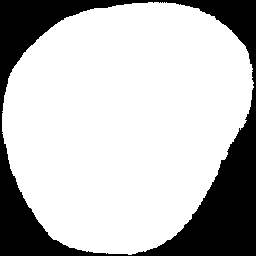
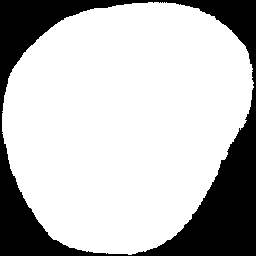
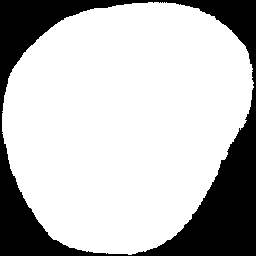
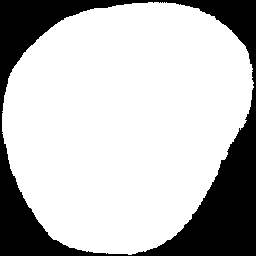
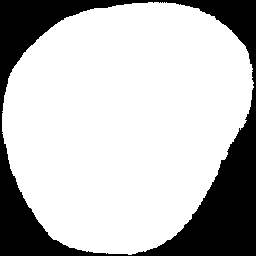
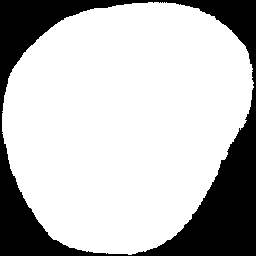
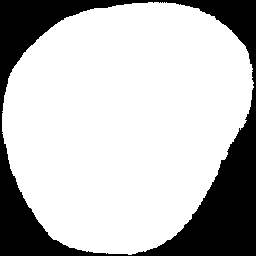
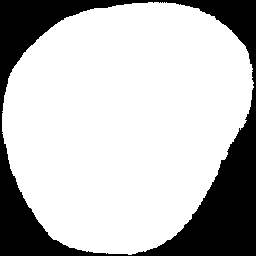
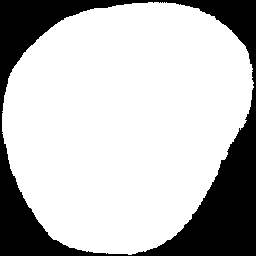
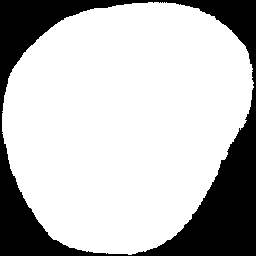
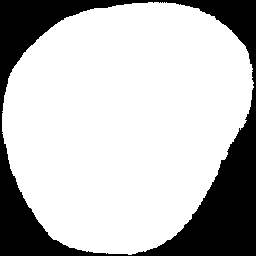
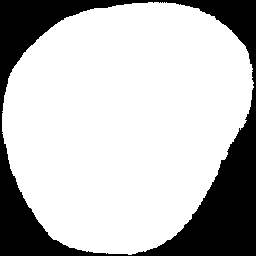
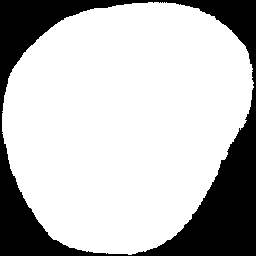
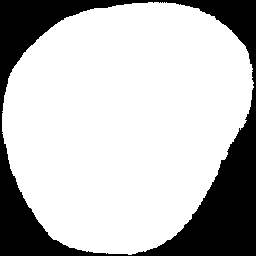
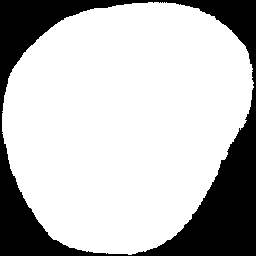
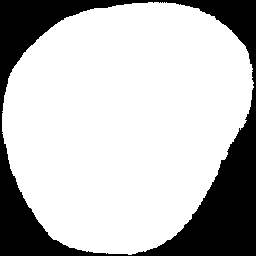
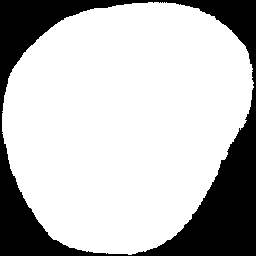
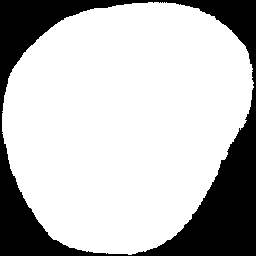
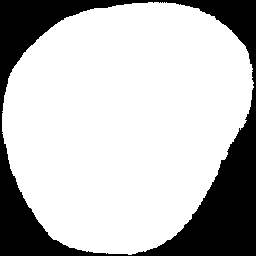
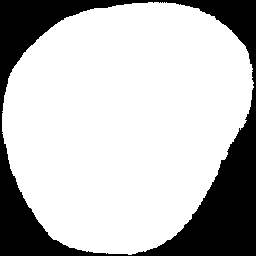
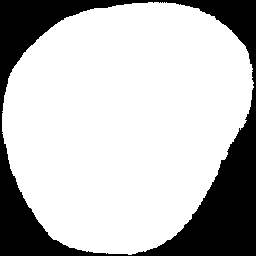
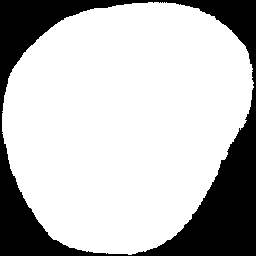
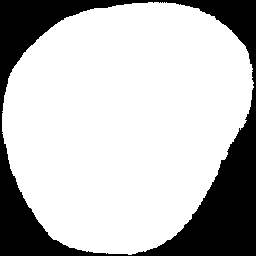
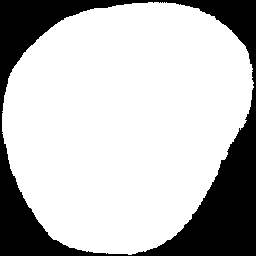
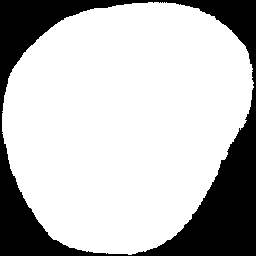
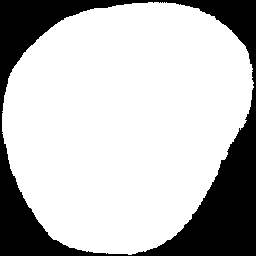
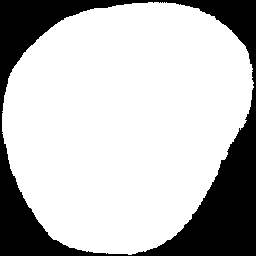
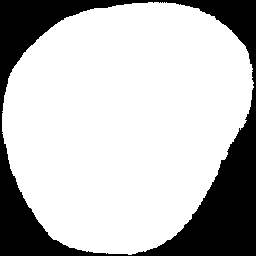
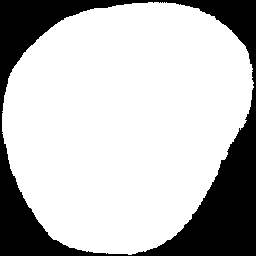
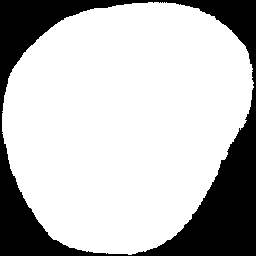
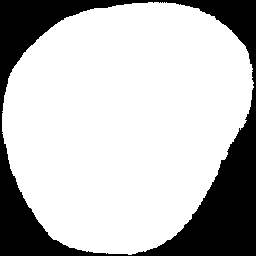
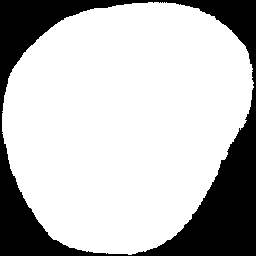
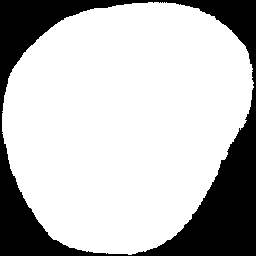
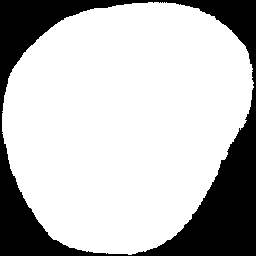
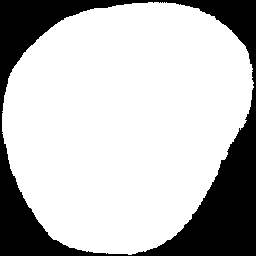
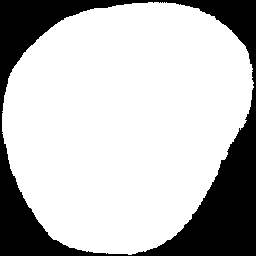
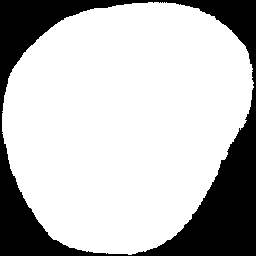
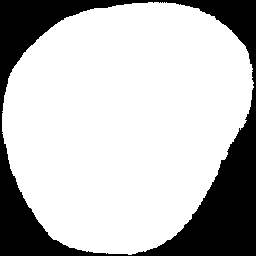
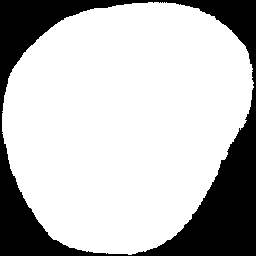
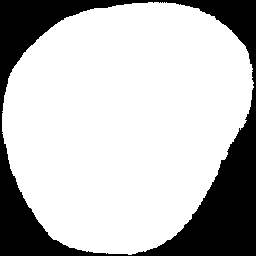
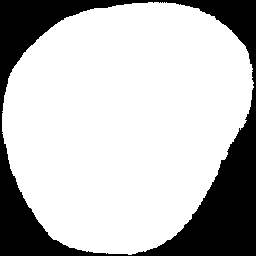
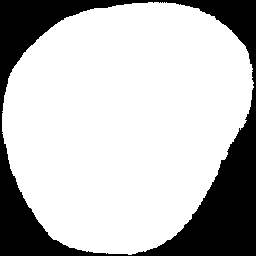
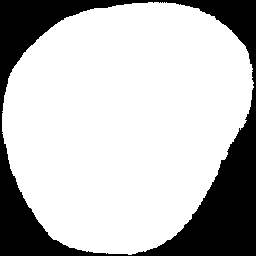
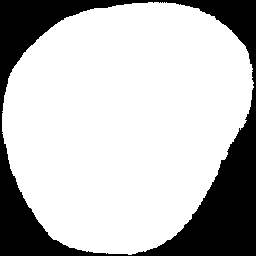
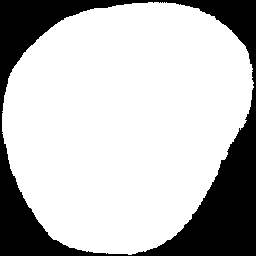
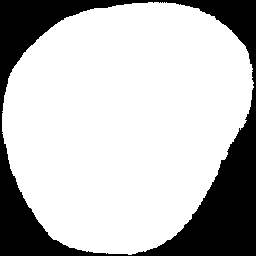
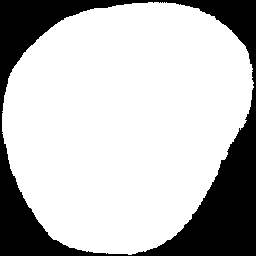
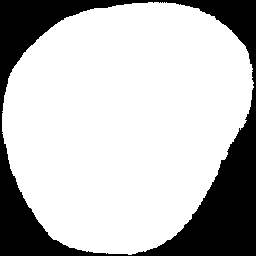
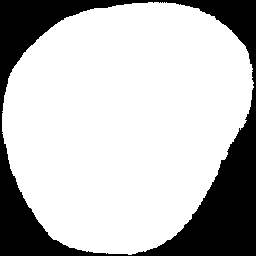
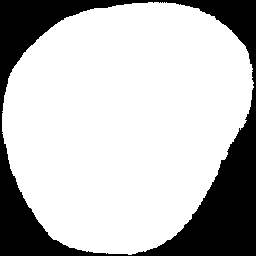
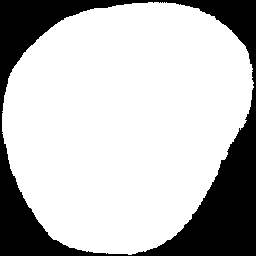
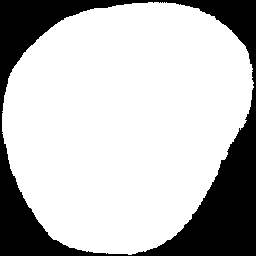
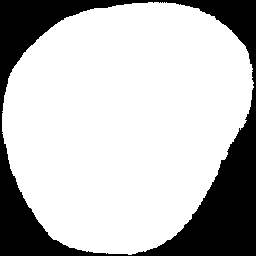
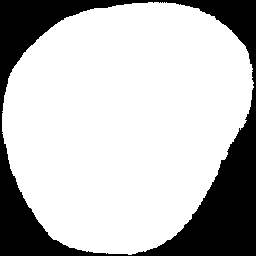
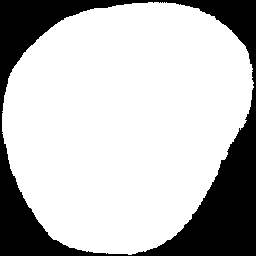
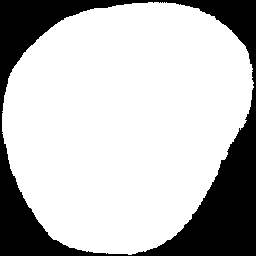
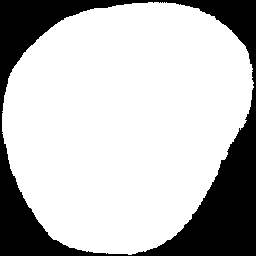
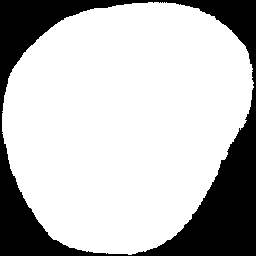
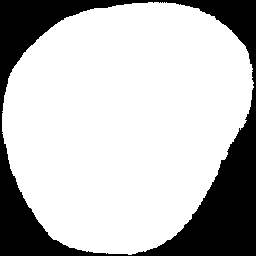
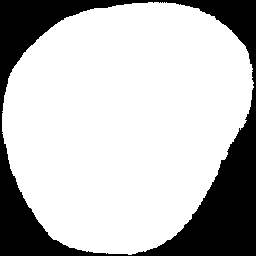
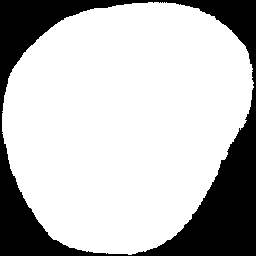
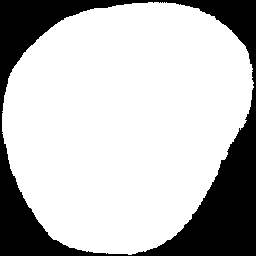
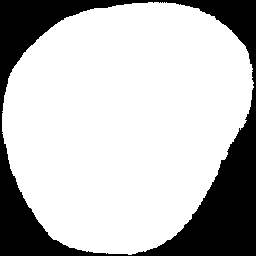
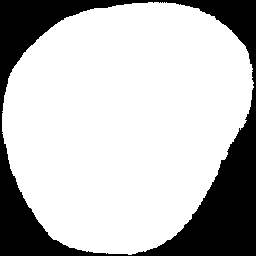
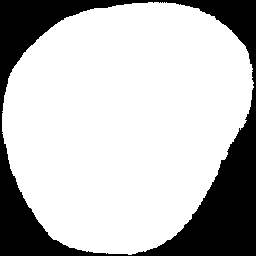
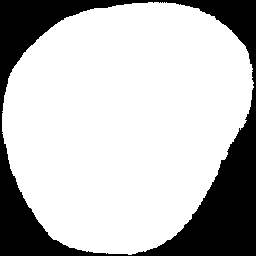
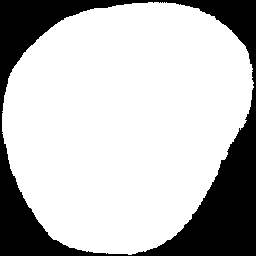
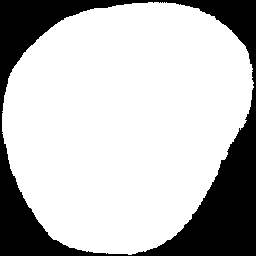
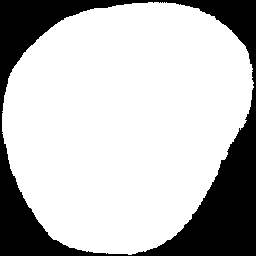
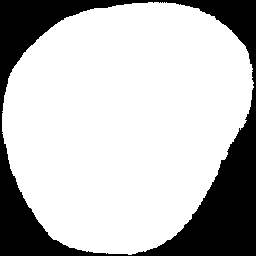
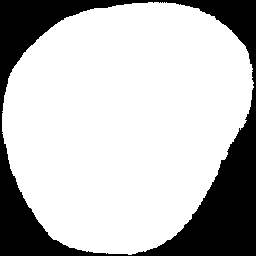
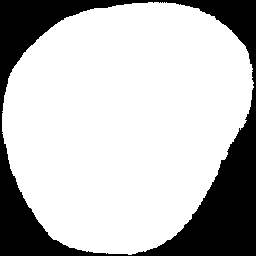
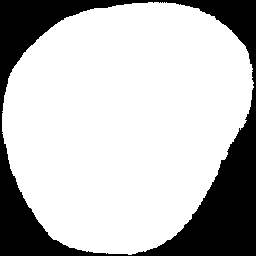
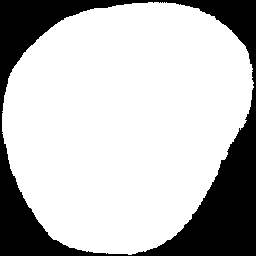
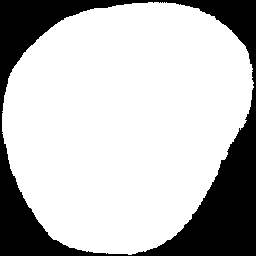
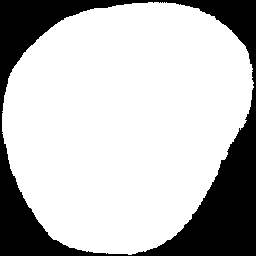
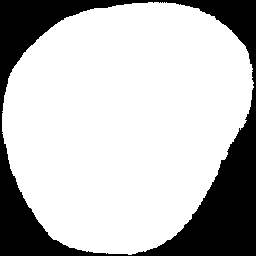
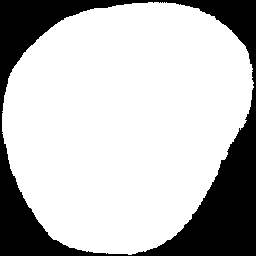
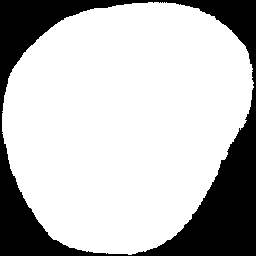
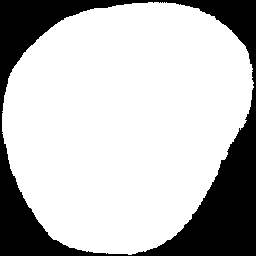
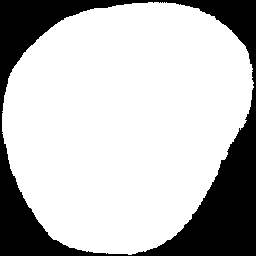
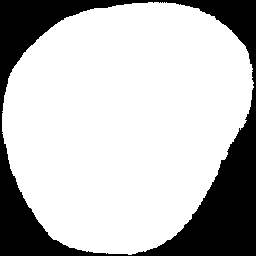
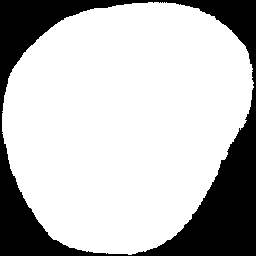
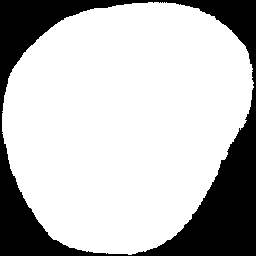
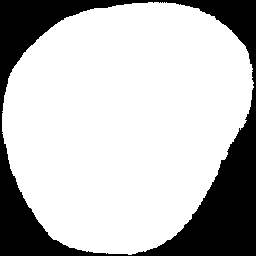
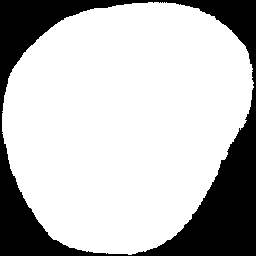
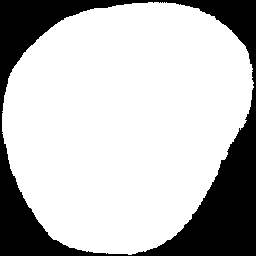
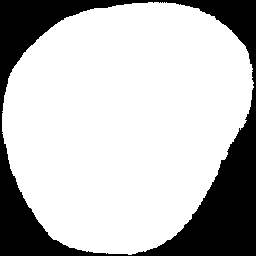
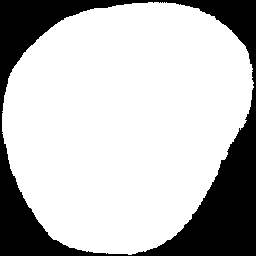
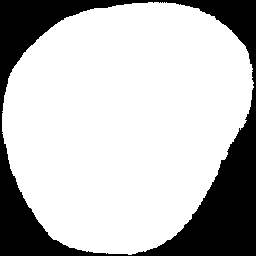
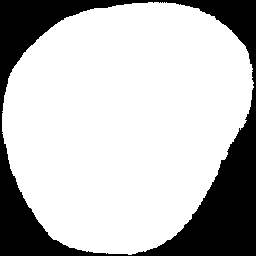
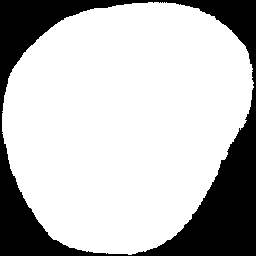
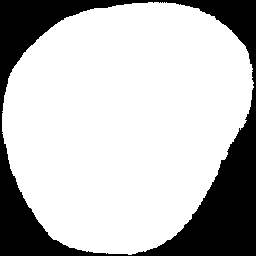
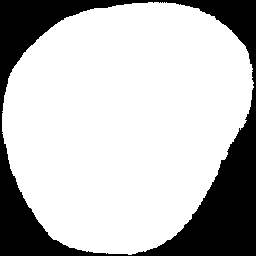
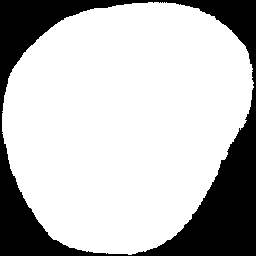
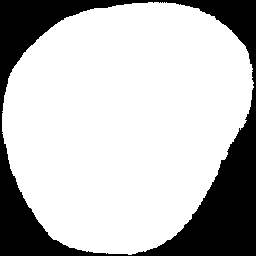
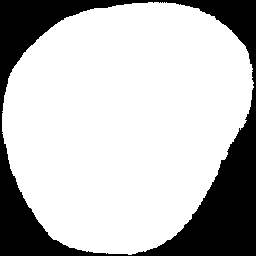
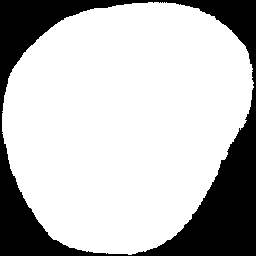
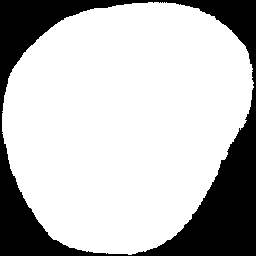
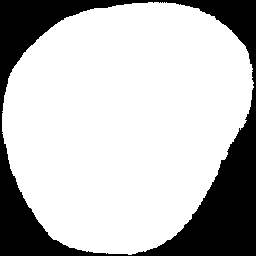
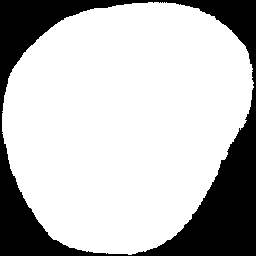
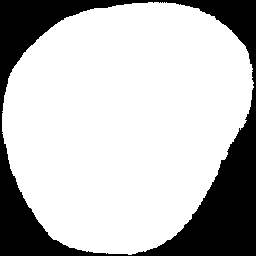
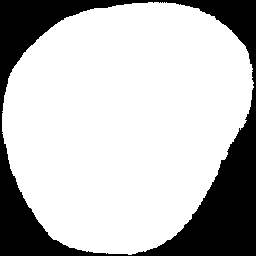
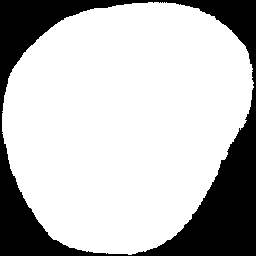
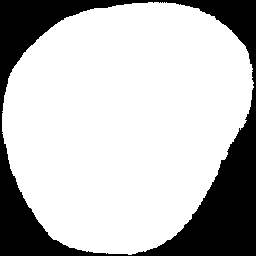
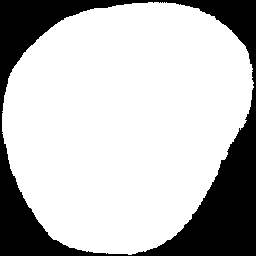
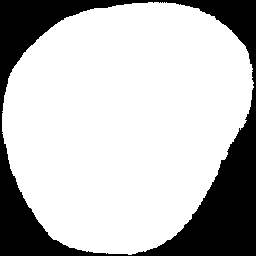
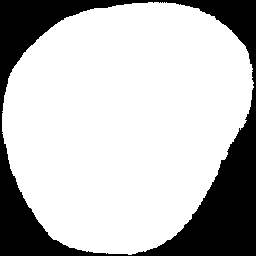
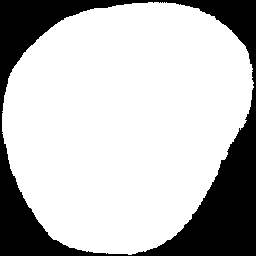
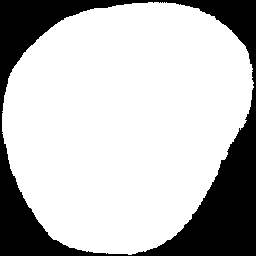

---------------------------------------------
       GenAI Segmentation Evaluation Report: gemini-2.5-flash-lite on SLIM_ACR
---------------------------------------------
Total Images Evaluated: 2379
IoU Threshold for Success: 0.5
Exclude Low IoU from Stats: True

--- Performance Metrics ---
Mean IoU (Pneumothorax):   0.6286 (95% CI: 0.5518 - 0.7054) on 4 images
Mean Dice (Pneumothorax):  0.7689 (95% CI: 0.7109 - 0.8269)

--- Operational Metrics ---
Mean API Latency:        1.39s (95% CI: 1.26s - 1.64s)
JSON Parse Success:      66.8%

--- Failure Analysis (based on full dataset) ---
JSON Failures:             789 (33.2%)
False Negatives (Pneumo):  0 (0.0%)
Low IoU (Pneumo):          1586 (66.7%)
---------------------------------------------


2025-08-02 13:53:53 — INFO — Saved high-resolution IoU plot to D:\Projects\gemini_image_segmentation\data\SLIM_ACR\iou_distribution_slim_acr_gemini-2.5-flash-lite.png


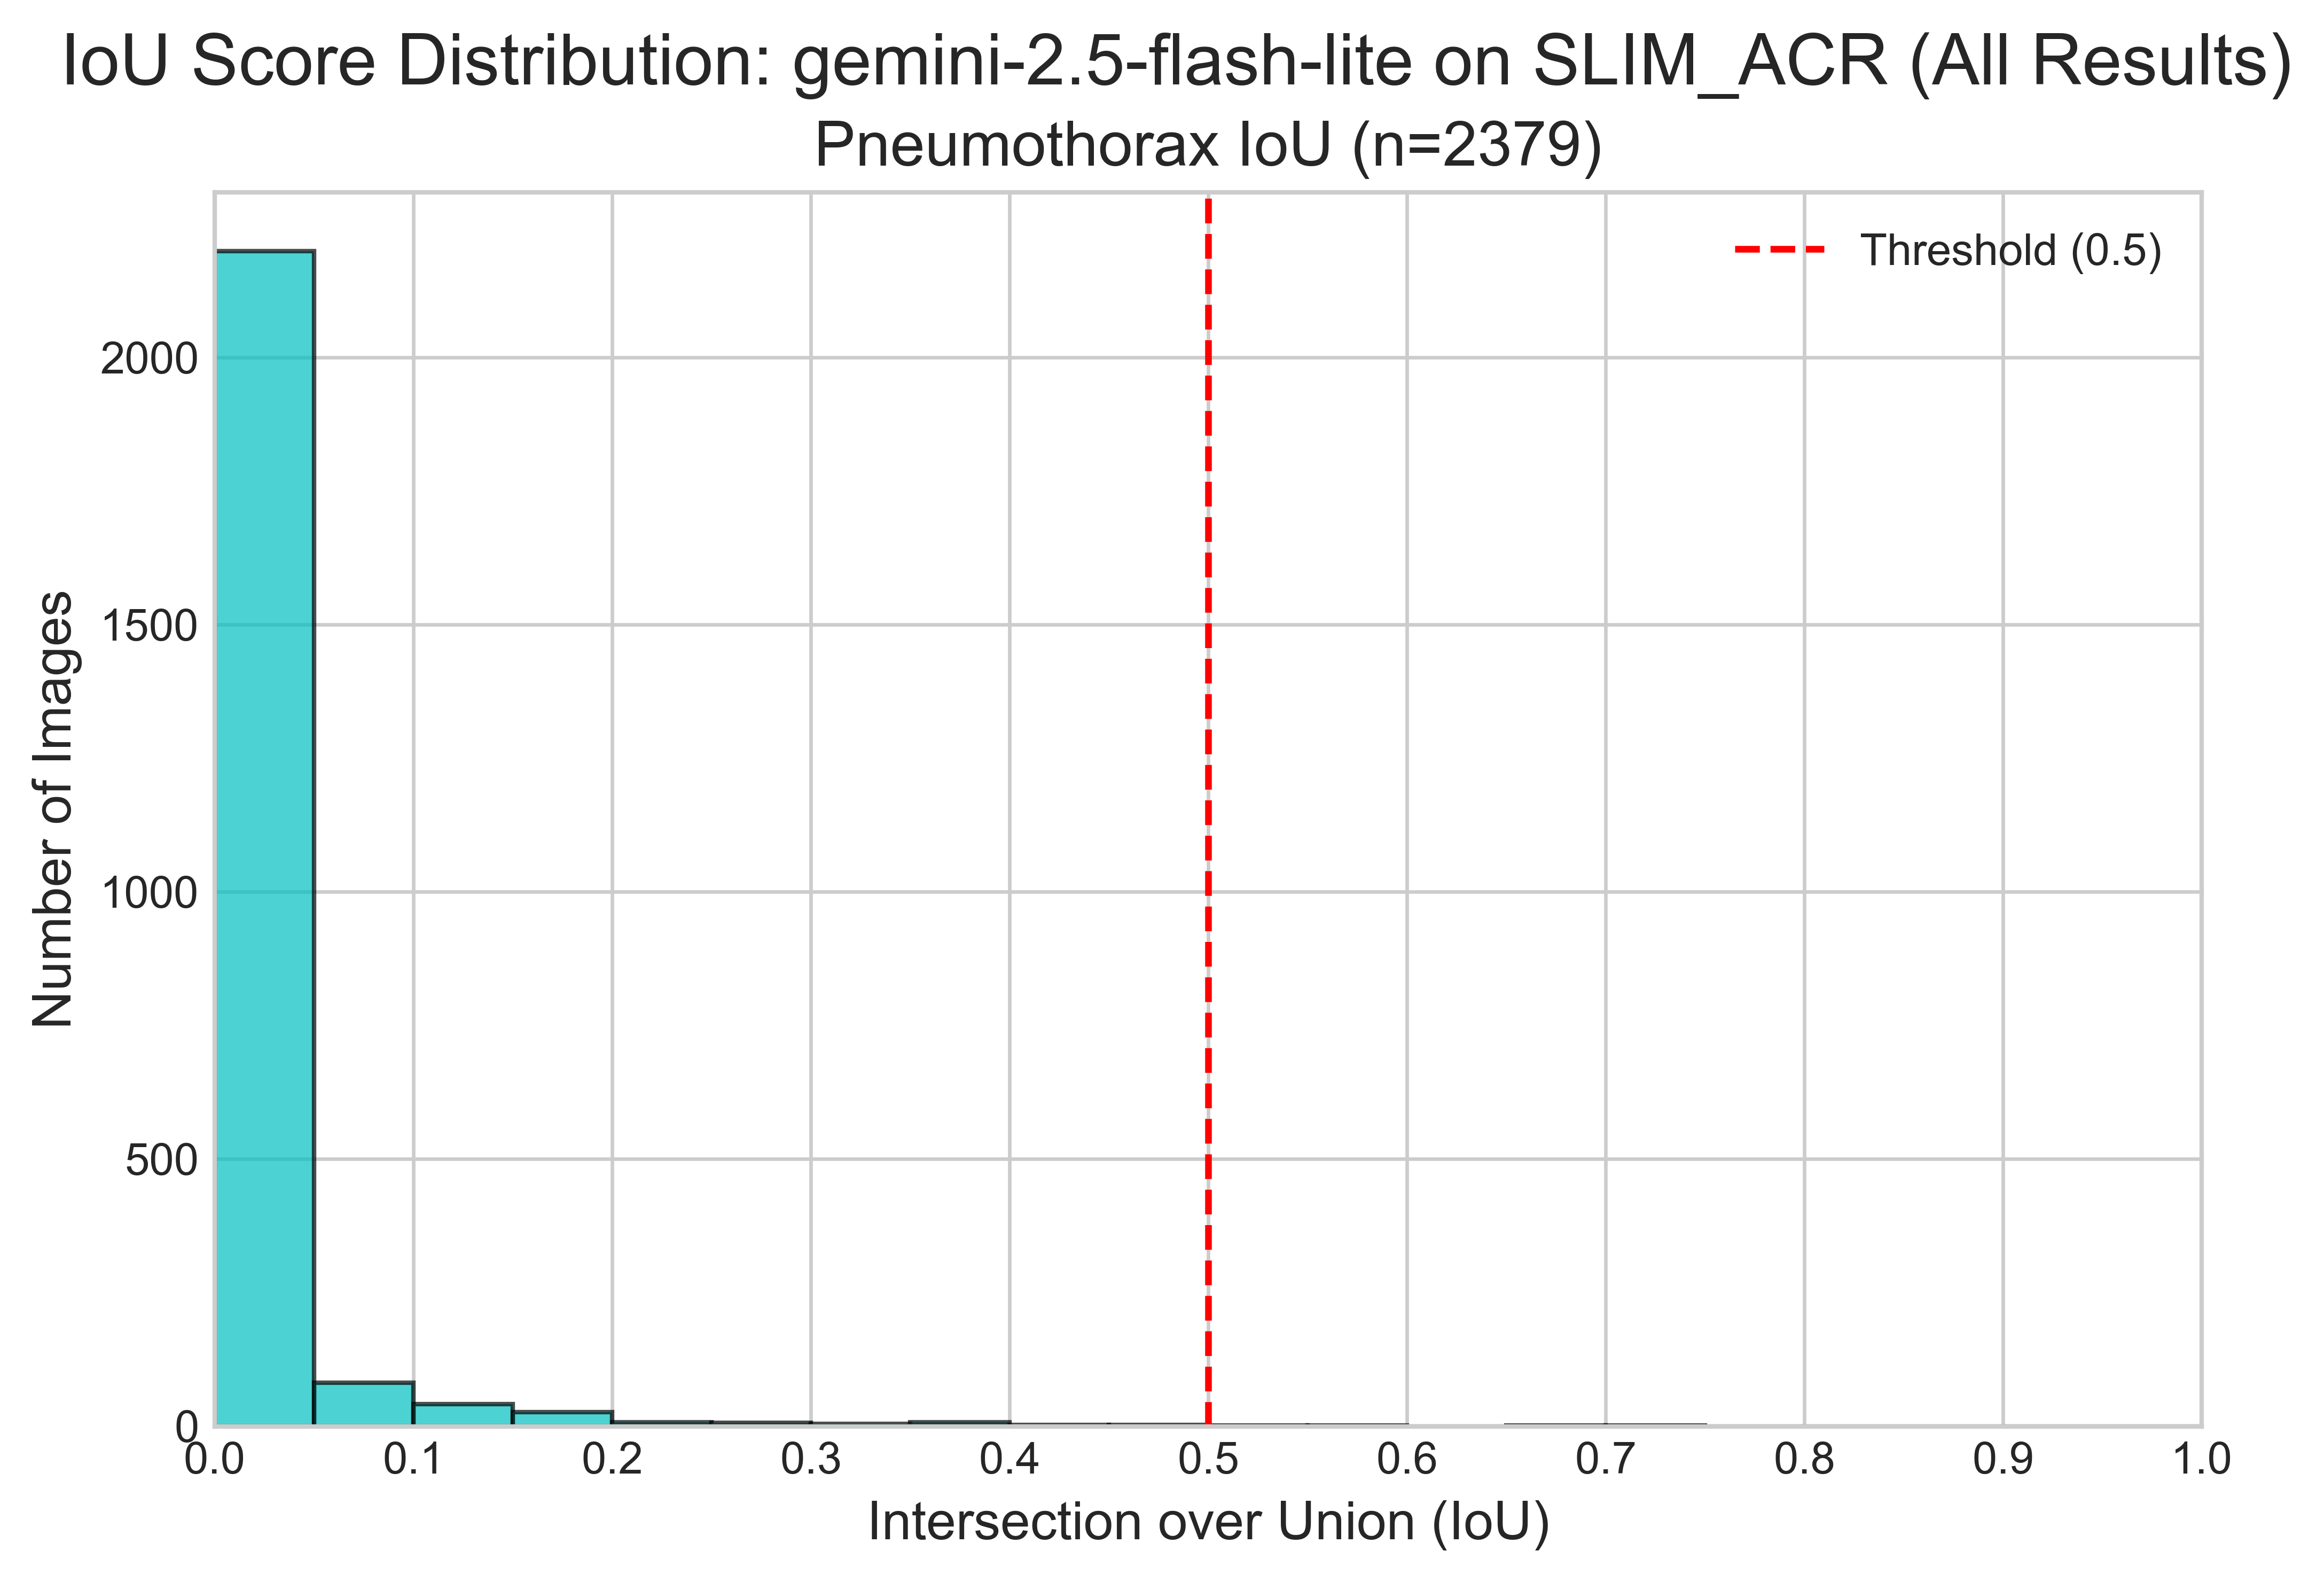

"\n✅ Evaluation complete. The report above summarizes the model's performance on the SLIM_ACR dataset.\n"

In [4]:
# %% [markdown]
"""
# 04 Model Evaluation · **SLIM_ACR Pneumothorax Segmentation**

*Last sync 02 Aug 2025*

This notebook evaluates the performance of the `gemini_seg` function for segmenting pneumothorax
from the SLIM_ACR chest x-ray dataset. It systematically calculates and aggregates key
performance metrics by comparing the model's output against ground-truth data.

**Key Features (Adapted for SLIM_ACR):**
- **Efficient Data Loading:** Uses a multithreaded, cached process to find all positive pneumothorax cases, avoiding rescans.
- **Multithreaded Evaluation:** Runs multiple API requests in parallel to significantly speed up the evaluation process.
- **Single-Class Evaluation:** Compares the predicted pneumothorax mask against the single ground truth mask.
- **Core Performance Metrics:** Calculates Dice Score and Intersection over Union (IoU).
- **Flexible Analysis:** A toggle (`EXCLUDE_LOW_IOU_FROM_STATS`) allows metrics and plots to be generated for either all images or only successful detections.
- **Robust Failure Analysis:** Categorizes and saves lists of failed images (JSON errors, false negatives, low IoU) for detailed review.
- **Bootstrapped Confidence Intervals:** An optional toggle (`ENABLE_BOOTSTRAPPING`) enables the calculation of 95% confidence intervals for all key metrics.
- **Publication-Ready Outputs:** Saves a detailed JSON summary and a high-resolution (600 DPI) plot of the IoU distribution.
- **Robust API Handling:** Includes rate limiting, client-side request timeouts, and prediction caching.
"""

# %%
# ---------- Preamble & Setup ----------
import sys, logging, os, subprocess, importlib.util, json, io, random, base64, dataclasses, time
from datetime import datetime
from pathlib import Path
from typing import Tuple, List, Dict, Optional
from concurrent.futures import ThreadPoolExecutor, as_completed, TimeoutError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageColor, UnidentifiedImageError
from tqdm import tqdm
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Evaluation notebook start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "google-genai", "pandas"):
    _ensure(extra)

# %%
# ---------- GenAI Client & Dataset Paths ----------
load_dotenv(find_dotenv(), override=False)

from google import genai
from google.genai.types import GenerateContentConfig, Part, ThinkingConfig

if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY not found. Ensure it is in your .env file.")

client = genai.Client()
logging.info("GenAI client initialized.")


# MODIFIED: Point to the SLIM_ACR pneumothorax dataset directory.
dataset_dir = Path("data/SLIM_ACR").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("SLIM_ACR dataset found at %s", dataset_dir)

# %% [markdown]
"""
### Core Functions (Adapted for Single-Class Pneumothorax)

This section includes the necessary functions for segmentation and evaluation, adapted for the single-class pneumothorax task.

**Key Modifications:**
- **`PROMPT`:** Updated to request segmentation of "the pneumothorax" from a "chest x-ray."
- **`parse_ground_truth_mask`:** Rewritten to parse the simple binary PNG masks from the SLIM_ACR dataset.
- **`gemini_seg`:** Modified to handle PNG image formats.
"""

# %%
# ---------- Core Segmentation & Parsing Logic ----------

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def parse_json(json_output: str) -> str:
    """Cleans the model's JSON output by removing markdown fencing."""
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "```json":
            json_content = "\n".join(lines[i+1:])
            closing_fence_index = json_content.find("```")
            if closing_fence_index != -1:
                json_content = json_content[:closing_fence_index]
            return json_content.strip()
    return json_output.strip()

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> Tuple[List[SegmentationMask], bool]:
    """
    Parses the model's JSON output into a list of SegmentationMask objects.
    Returns the list of masks and a boolean indicating if JSON parsing was successful.
    """
    cleaned_json = parse_json(predicted_str)
    if not cleaned_json:
        logging.warning("Parsing model output resulted in an empty string.")
        return [], True # Technically not a JSON error, but an empty response.

    try:
        items = json.loads(cleaned_json)
        parse_success = True
    except json.JSONDecodeError as e:
        logging.error(f"Failed to decode JSON: {e}")
        logging.error(f"Problematic string after cleaning: {cleaned_json}")
        return [], False

    masks = []
    for item in items:
        try:
            abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
            abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
            abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
            abs_x1 = int(item["box_2d"][3] / 1000 * img_width)

            if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
                continue

            label = item["label"].lower() # Standardize label to lowercase
            png_b64_str = item["mask"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            partial_mask_img = Image.open(io.BytesIO(png_bytes))

            bbox_height = abs_y1 - abs_y0
            bbox_width = abs_x1 - abs_x0
            resized_mask = partial_mask_img.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
            full_mask_np = np.zeros((img_height, img_width), dtype=np.uint8)
            full_mask_np[abs_y0:abs_y1, abs_x0:abs_x1] = np.array(resized_mask)

            masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, full_mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in JSON response: {item}. Error: {e}")
            continue
    return masks, parse_success

def parse_ground_truth_mask(mask_path: Path) -> list[SegmentationMask]:
    """
    Parses a SLIM_ACR ground truth PNG file into a single SegmentationMask for the pneumothorax.
    The mask is a single-channel binary image (0 for background, 255 for pneumothorax).
    """
    try:
        mask_img = Image.open(mask_path).convert("L") # Ensure single channel grayscale
        mask_data = np.array(mask_img)
    except (FileNotFoundError, UnidentifiedImageError) as e:
        logging.error("Could not read ground truth mask file %s: %s", mask_path, e)
        return []

    binary_mask_data = mask_data > 127 # Create a boolean mask

    if not np.any(binary_mask_data):
        return []

    rows, cols = np.where(binary_mask_data)
    y0, y1 = rows.min(), rows.max()
    x0, x1 = cols.min(), cols.max()
    full_mask_np = binary_mask_data.astype(np.uint8) * 255
    # The label is consistently "pneumothorax" for this single-class task.
    return [SegmentationMask(y0, x0, y1, x1, full_mask_np, "pneumothorax")]


# MODIFIED: Prompt updated for pneumothorax segmentation.
PROMPT = (
    'In this chest x-ray, give the segmentation mask for the pneumothorax. '
    'Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", '
    'the segmentation mask in key "mask", and the text label in the key "label". '
    'Use the label "pneumothorax".'
)

def gemini_seg(image_obj: Image.Image, model_name: str, thinking_budget: int) -> Tuple[List[SegmentationMask], float, bool]:
    """
    Sends a PIL Image object to Gemini and returns segmentation masks, with a client-side timeout.
    """
    original_width, original_height = image_obj.size
    
    img_for_api = image_obj.copy()
    max_dim = 1024
    if img_for_api.height > max_dim or img_for_api.width > max_dim:
        img_for_api.thumbnail((max_dim, max_dim))

    with io.BytesIO() as img_byte_arr:
        # MODIFIED: Save as PNG for CXR data
        img_for_api.save(img_byte_arr, format='PNG')
        img_bytes = img_byte_arr.getvalue()

    gen_config = GenerateContentConfig(
        thinking_config=ThinkingConfig(thinking_budget=thinking_budget),
        temperature=0.5
    )
    # MODIFIED: Mime type is now image/png
    image_part = Part.from_bytes(data=img_bytes, mime_type='image/png')
    text_part = Part(text=PROMPT)
    
    def do_api_call():
        return client.models.generate_content(
            model=model_name, contents=[image_part, text_part], config=gen_config
        )

    start_time = datetime.now()
    try:
        if ENABLE_REQUEST_TIMEOUT:
            with ThreadPoolExecutor(max_workers=1) as executor:
                future = executor.submit(do_api_call)
                response = future.result(timeout=REQUEST_TIMEOUT_SEC)
        else:
            response = do_api_call()
        
        latency = (datetime.now() - start_time).total_seconds()
        masks, parse_success = parse_segmentation_masks(
            response.text, img_height=original_height, img_width=original_width
        )
        return masks, latency, parse_success

    except TimeoutError:
        logging.error(f"API call timed out after {REQUEST_TIMEOUT_SEC} seconds.")
        return [], 0.0, False
    except Exception as e:
        logging.error(f"An error occurred during the gemini_seg function.", exc_info=True)
        return [], 0.0, False

def save_prediction_details(masks: List[SegmentationMask], output_path: Path):
    """Saves the detailed contents of SegmentationMask objects to a JSON file."""
    if not masks:
        output_path.write_text(json.dumps([]))
        return

    results_to_save = []
    for mask_obj in masks:
        pil_img = Image.fromarray(mask_obj.mask)
        with io.BytesIO() as buffer:
            pil_img.save(buffer, format="PNG")
            png_bytes = buffer.getvalue()
        b64_string = base64.b64encode(png_bytes).decode('utf-8')
        results_to_save.append({
            "label": mask_obj.label,
            "box_2d_absolute": [mask_obj.y0, mask_obj.x0, mask_obj.y1, mask_obj.x1],
            "mask_b64": f"data:image/png;base64,{b64_string}"
        })
    with open(output_path, 'w') as f:
        json.dump(results_to_save, f, indent=2)

# %% [markdown]
"""
### Metric Calculation Utilities

These functions implement the formulas for Intersection over Union (IoU), the Dice Coefficient, and bootstrapping for confidence intervals.
"""

# %%
# ---------- Metric Calculation Functions ----------

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0
    return np.sum(intersection) / np.sum(union)

def calculate_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates the Dice Coefficient for boolean masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred))
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: return 1.0
    return (2. * intersection) / (denominator + 1e-7)

def calculate_bootstrap_ci(data: List[float], n_resamples: int = 1000) -> Tuple[float, float]:
    """Calculates the 95% confidence interval for a list of numbers using bootstrapping."""
    if not data or len(data) < 2: return 0.0, 0.0
    bootstrapped_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    return np.percentile(bootstrapped_means, 2.5), np.percentile(bootstrapped_means, 97.5)

# %% [markdown]
"""
### Evaluation Execution

This is the main execution block. It will:
1.  Check for a cached list of positive pneumothorax cases. If not found, it will generate one using multiple threads.
2.  Randomly sample a specified number of images (`NUM_IMAGES_TO_TEST`).
3.  Use a `ThreadPoolExecutor` to run the evaluation on multiple images in parallel.
4.  For each image, it calls `gemini_seg`, parses the ground truth, calculates metrics, and categorizes failures.
5.  Collects all results for final aggregation and reporting.
"""

# %%
# ---------- Main Evaluation Loop ----------

# <<< --- PARAMETERS TO CONTROL THE EVALUATION --- >>>
MODEL_NAME = "gemini-2.5-flash-lite"
THINKING_BUDGET = 0
NUM_IMAGES_TO_TEST = 0 # Set to None or 0 to test all images
MAX_WORKERS = 8 # Number of parallel threads for evaluation
SAVE_PREDICTIONS = True
ENABLE_BOOTSTRAPPING = True
ENABLE_RATE_LIMITING = False
RATE_LIMIT_DELAY_SEC = 9
ENABLE_REQUEST_TIMEOUT = True
REQUEST_TIMEOUT_SEC = 300
LOW_IOU_THRESHOLD = 0.5
EXCLUDE_LOW_IOU_FROM_STATS = True # If True, stats only use runs with IoU >= threshold.

model_name_safe = MODEL_NAME.replace("/", "_")
logging.info(f"Starting evaluation run for model: {MODEL_NAME} on SLIM_ACR dataset.")

# --- Define direct paths to subdirectories ---
image_dir = dataset_dir / "image"
mask_dir = dataset_dir / "mask"

# --- Load or Generate Positive Case List (Cached & Multithreaded) ---
def check_mask_for_positive_finding(img_path: Path) -> Optional[Path]:
    mask_path = mask_dir / img_path.name
    if mask_path.exists():
        try:
            with Image.open(mask_path) as mask_img:
                if np.any(np.array(mask_img) > 0):
                    return img_path
        except UnidentifiedImageError:
            logging.warning("Could not read mask file, skipping: %s", mask_path)
    return None

positive_cases_cache_path = dataset_dir / "positive_cases_cache.txt"
all_available_paths = []

if positive_cases_cache_path.exists():
    logging.info("Loading positive case list from cache: %s", positive_cases_cache_path)
    all_available_paths = [Path(p) for p in positive_cases_cache_path.read_text().splitlines()]
else:
    logging.info("Cache not found. Scanning all masks for positive cases...")
    all_img_paths = sorted(image_dir.glob("*.png"))
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        results = list(tqdm(
            executor.map(check_mask_for_positive_finding, all_img_paths),
            total=len(all_img_paths),
            desc="Scanning for positive cases"
        ))
    all_available_paths = [path for path in results if path is not None]
    logging.info("Saving positive case list to cache: %s", positive_cases_cache_path)
    positive_cases_cache_path.write_text("\n".join(str(p) for p in all_available_paths))

logging.info(f"Found {len(all_available_paths)} total positive pneumothorax cases.")

# --- Create Model-Specific Predictions Directory ---
if SAVE_PREDICTIONS:
    predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
    predictions_dir.mkdir(exist_ok=True)
    logging.info(f"Detailed predictions will be saved to: {predictions_dir}")

# --- Prepare Evaluation Set ---
random.seed(42)
random.shuffle(all_available_paths)
if NUM_IMAGES_TO_TEST is None or NUM_IMAGES_TO_TEST <= 0:
    images_to_evaluate = all_available_paths
else:
    images_to_evaluate = all_available_paths[:min(NUM_IMAGES_TO_TEST, len(all_available_paths))]
logging.info(f"Will evaluate a sample of {len(images_to_evaluate)} images using up to {MAX_WORKERS} threads.")

# --- Multithreaded Evaluation Worker ---
def evaluate_single_image(img_path: Path) -> Dict:
    """Worker function to process and evaluate a single image."""
    try:
        original_image = Image.open(img_path)
        predicted_masks, latency, parse_success = gemini_seg(original_image, MODEL_NAME, THINKING_BUDGET)

        if SAVE_PREDICTIONS:
            prediction_output_path = predictions_dir / f"{img_path.stem}.json"
            save_prediction_details(predicted_masks, prediction_output_path)

        mask_path = mask_dir / img_path.name
        gt_masks = parse_ground_truth_mask(mask_path)
        
        gt_mask_np = gt_masks[0].mask if gt_masks else np.zeros((original_image.height, original_image.width), dtype=np.uint8)
        pred_mask_np = predicted_masks[0].mask if predicted_masks else np.zeros_like(gt_mask_np)

        iou_pneumothorax = calculate_iou(gt_mask_np > 127, pred_mask_np > 127)
        dice_pneumothorax = calculate_dice(gt_mask_np > 127, pred_mask_np > 127)

        failure_type = "none"
        if not parse_success:
            failure_type = "json"
        elif not predicted_masks:
            failure_type = "fn_pneumothorax"
        elif iou_pneumothorax < LOW_IOU_THRESHOLD:
            failure_type = "low_iou_pneumothorax"

        return {
            "image_path": img_path.name, "latency_sec": latency, "parse_success": parse_success,
            "iou_pneumothorax": iou_pneumothorax, "dice_pneumothorax": dice_pneumothorax,
            "failure_type": failure_type
        }
    except Exception as e:
        logging.error(f"An unexpected error occurred while processing {img_path.name}", exc_info=True)
        return {
            "image_path": img_path.name, "latency_sec": 0, "parse_success": False,
            "iou_pneumothorax": 0, "dice_pneumothorax": 0, "failure_type": "processing_error"
        }

# --- Execute Evaluation in Parallel ---
all_results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_path = {executor.submit(evaluate_single_image, path): path for path in images_to_evaluate}
    for future in tqdm(as_completed(future_to_path), total=len(images_to_evaluate), desc=f"Evaluating {model_name_safe}"):
        all_results.append(future.result())
        if ENABLE_RATE_LIMITING:
            time.sleep(RATE_LIMIT_DELAY_SEC)

logging.info("Evaluation loop complete.")

# --- Aggregate results and failures ---
evaluation_results = []
json_failures, fn_pneumothorax_failures, low_iou_pneumothorax_failures = [], [], []
for result in all_results:
    evaluation_results.append(result)
    if result["failure_type"] == "json":
        json_failures.append(result["image_path"])
    elif result["failure_type"] == "fn_pneumothorax":
        fn_pneumothorax_failures.append(result["image_path"])
    elif result["failure_type"] == "low_iou_pneumothorax":
        low_iou_pneumothorax_failures.append(result["image_path"])

# %% [markdown]
"""
### Failure Analysis & Reporting

This section saves the lists of failed images to model-specific text files for easier manual review. Failures are categorized by type (JSON error, false negative, low IoU).
"""

# %%
# ---------- Save Failure Lists to Files ----------
def save_failure_list(failure_list: List[str], failure_type: str, model_name: str):
    """Saves a list of failed image names to a text file."""
    if failure_list:
        failure_path = dataset_dir / f"failures_{failure_type}_{model_name}.txt"
        logging.info(f"Saving {len(failure_list)} {failure_type} failures to {failure_path}")
        failure_path.write_text("\n".join(failure_list))

save_failure_list(json_failures, "json", model_name_safe)
save_failure_list(fn_pneumothorax_failures, "fn_pneumothorax", model_name_safe)
save_failure_list(low_iou_pneumothorax_failures, "low_iou_pneumothorax", model_name_safe)

# %% [markdown]
"""
### Results Summary

The following report aggregates the results from the evaluation run and saves a copy to a model-specific `evaluation_summary_slim_acr_<model_name>.json` file.
"""

# %%
# ---------- Aggregate, Display, and Save Results ----------

if evaluation_results:
    df = pd.DataFrame(evaluation_results)

    if EXCLUDE_LOW_IOU_FROM_STATS:
        logging.info(f"Excluding cases with IoU < {LOW_IOU_THRESHOLD} from stats.")
        runs_for_stats = df[df['iou_pneumothorax'] >= LOW_IOU_THRESHOLD]
    else:
        logging.info("Including all cases (even IoU=0) in stats.")
        runs_for_stats = df

    mean_iou_pneumothorax = runs_for_stats['iou_pneumothorax'].mean()
    mean_dice_pneumothorax = runs_for_stats['dice_pneumothorax'].mean()

    valid_latencies = df[df['latency_sec'] > 0]['latency_sec']
    mean_latency = valid_latencies.mean() if not valid_latencies.empty else 0
    total_runs = len(df)
    parse_success_rate = df['parse_success'].mean() * 100

    iou_pneumothorax_ci, dice_pneumothorax_ci, latency_ci = [(0,0)]*3
    if ENABLE_BOOTSTRAPPING:
        logging.info("Calculating 95%% CIs with 1000-fold bootstrapping...")
        iou_pneumothorax_ci = calculate_bootstrap_ci(runs_for_stats['iou_pneumothorax'].tolist())
        dice_pneumothorax_ci = calculate_bootstrap_ci(runs_for_stats['dice_pneumothorax'].tolist())
        latency_ci = calculate_bootstrap_ci(valid_latencies.tolist())
        logging.info("CI calculation complete.")

    print("---" * 15)
    print(f"       GenAI Segmentation Evaluation Report: {MODEL_NAME} on SLIM_ACR")
    print("---" * 15)
    print(f"Total Images Evaluated: {total_runs}")
    print(f"IoU Threshold for Success: {LOW_IOU_THRESHOLD}")
    print(f"Exclude Low IoU from Stats: {EXCLUDE_LOW_IOU_FROM_STATS}")
    
    print("\n--- Performance Metrics ---")
    print(f"Mean IoU (Pneumothorax):   {mean_iou_pneumothorax:.4f} (95% CI: {iou_pneumothorax_ci[0]:.4f} - {iou_pneumothorax_ci[1]:.4f}) on {len(runs_for_stats)} images")
    print(f"Mean Dice (Pneumothorax):  {mean_dice_pneumothorax:.4f} (95% CI: {dice_pneumothorax_ci[0]:.4f} - {dice_pneumothorax_ci[1]:.4f})")
    
    print("\n--- Operational Metrics ---")
    print(f"Mean API Latency:        {mean_latency:.2f}s (95% CI: {latency_ci[0]:.2f}s - {latency_ci[1]:.2f}s)")
    print(f"JSON Parse Success:      {parse_success_rate:.1f}%")

    print("\n--- Failure Analysis (based on full dataset) ---")
    print(f"JSON Failures:             {len(json_failures)} ({len(json_failures)/total_runs:.1%})")
    print(f"False Negatives (Pneumo):  {len(fn_pneumothorax_failures)} ({len(fn_pneumothorax_failures)/total_runs:.1%})")
    print(f"Low IoU (Pneumo):          {len(low_iou_pneumothorax_failures)} ({len(low_iou_pneumothorax_failures)/total_runs:.1%})")
    print("---" * 15)

    summary_data = {
        "run_timestamp": datetime.now().isoformat(),
        "total_images_evaluated": total_runs,
        "settings": { "model_name": MODEL_NAME, "thinking_budget": THINKING_BUDGET, "low_iou_threshold": LOW_IOU_THRESHOLD, "exclude_low_iou_from_stats": EXCLUDE_LOW_IOU_FROM_STATS },
        "performance_metrics": {
            "mean_iou_pneumothorax": mean_iou_pneumothorax, "mean_iou_pneumothorax_95_ci": iou_pneumothorax_ci,
            "mean_dice_pneumothorax": mean_dice_pneumothorax, "mean_dice_pneumothorax_95_ci": dice_pneumothorax_ci,
        },
        "operational_metrics": { "mean_latency_sec": mean_latency, "mean_latency_95_ci": latency_ci, "json_parse_success_rate_percent": parse_success_rate, },
        "failure_counts": {
            "json_parsing": len(json_failures),
            "false_negative_pneumothorax": len(fn_pneumothorax_failures),
            "low_iou_pneumothorax": len(low_iou_pneumothorax_failures),
        }
    }
    summary_path = dataset_dir / f"evaluation_summary_slim_acr_{model_name_safe}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary_data, f, indent=4)
    logging.info(f"Saved evaluation summary to {summary_path}")

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=600)
    fig.suptitle(f'IoU Score Distribution: {MODEL_NAME} on SLIM_ACR (All Results)', fontsize=16)

    ax.hist(df['iou_pneumothorax'], bins=20, range=(0,1), edgecolor='black', alpha=0.7, color='c')
    ax.set_title(f'Pneumothorax IoU (n={len(df)})', fontsize=14)
    ax.set_xlabel('Intersection over Union (IoU)', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.axvline(LOW_IOU_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({LOW_IOU_THRESHOLD})')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

    plot_path = dataset_dir / f"iou_distribution_slim_acr_{model_name_safe}.png"
    plt.savefig(plot_path, bbox_inches='tight')
    logging.info(f"Saved high-resolution IoU plot to {plot_path}")
    plt.show()
else:
    print("No evaluation results were generated.")

# %% [markdown]
"""
✅ Evaluation complete. The report above summarizes the model's performance on the SLIM_ACR dataset.
"""


# Case Plotting

2025-08-02 20:00:41 — INFO — SLIM_ACR dataset found at D:\Projects\gemini_image_segmentation\data\SLIM_ACR
2025-08-02 20:00:41 — INFO — Searching for the single best IoU case for model 'gemini-2.5-flash'...
2025-08-02 20:00:52 — INFO — Found matching case: '1.2.276.0.7230010.3.1.4.8323329.13817.1517875248.92684.png'. Visualizing...
2025-08-02 20:00:52 — INFO — Loading original image: 1.2.276.0.7230010.3.1.4.8323329.13817.1517875248.92684.png
2025-08-02 20:00:52 — INFO — Loading ground truth: 1.2.276.0.7230010.3.1.4.8323329.13817.1517875248.92684.png
2025-08-02 20:00:52 — INFO — Loading prediction for model 'gemini-2.5-flash' from cache: 1.2.276.0.7230010.3.1.4.8323329.13817.1517875248.92684.json


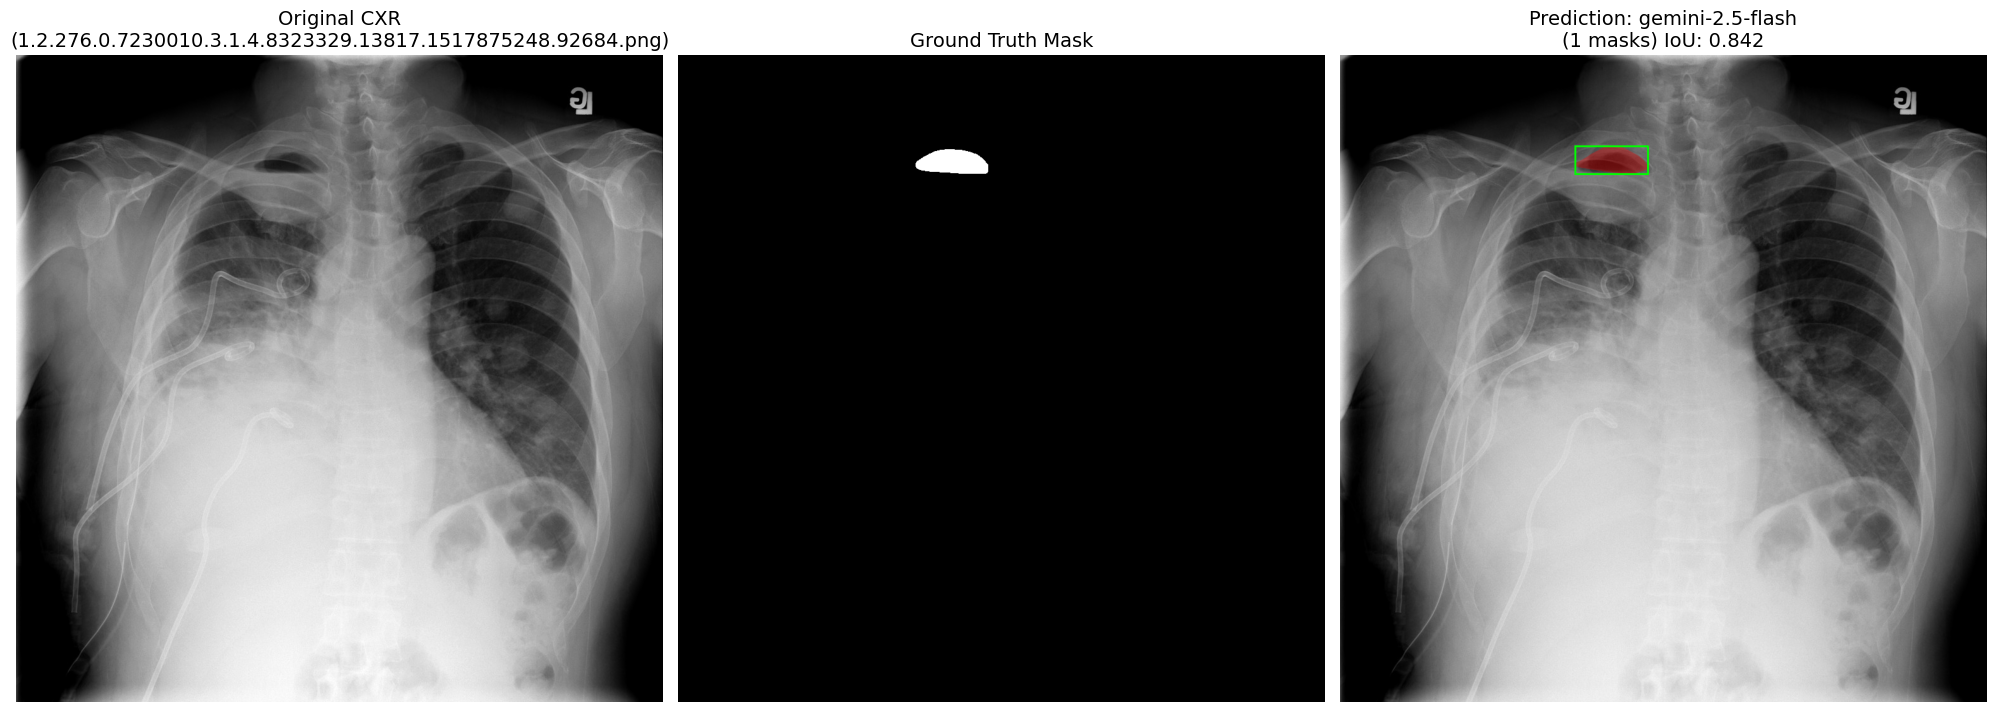

In [1]:
# %% [markdown]
"""
# 05 Qualitative Analysis (SLIM_ACR)

*Last sync 02 Aug 2025*

This notebook provides tools to perform a qualitative check on the model's output from a previous evaluation run on the SLIM_ACR pneumothorax dataset. It loads a cached prediction from the model-specific `predictions_<model_name>/` directory and displays a three-panel comparison for any given image. This version uses multithreading to accelerate the search for matching cases.

**Instructions:**
- Ensure you have run the `04_Model_Evaluation_SLIM_ACR` notebook first with `SAVE_PREDICTIONS = True`.
- Set the `MODEL_TO_VISUALIZE` variable in the last cell to the model you want to inspect.
- To find the single best-performing case, set `FIND_BEST_IOU_CASE` to `True`.
- If `FIND_BEST_IOU_CASE` is `False`, set `FIND_HIGH_IOU_CASES` to `True` for cases with an IoU > 0.5, or `False` for cases with an IoU < 0.5.
- To visualize a specific image, set `IMAGE_TO_VISUALIZE` to a filename (e.g., 'cxr_image_001.png'). Otherwise, a case will be found based on the criteria above.
"""

# %%
# ---------- Preamble & Setup ----------
import os, json, base64, dataclasses, logging, io, random
from pathlib import Path
from typing import List, Tuple, Dict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, UnidentifiedImageError
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

# %%
# ---------- Dataset Path & Helper Functions ----------
# Point to the SLIM_ACR pneumothorax dataset directory.
dataset_dir = Path("data/SLIM_ACR").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("SLIM_ACR dataset found at %s", dataset_dir)


@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0:
        return 1.0 # If both masks are empty, it's a perfect match.
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

def load_prediction_from_cache(prediction_path: Path) -> List[SegmentationMask]:
    """Loads and parses a cached prediction JSON file into SegmentationMask objects."""
    if not prediction_path.exists():
        logging.error(f"Prediction cache file not found: {prediction_path}")
        return []
    
    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return []

    masks = []
    for item in items:
        try:
            y0, x0, y1, x1 = item["box_2d_absolute"]
            label = item["label"]
            
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)

            masks.append(SegmentationMask(y0, x0, y1, x1, mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return masks

def _process_prediction_file(pred_file: Path, images_dir: Path, masks_dir: Path) -> Tuple[str, float] | None:
    """Worker function to process a single prediction file and return its IoU score."""
    stem = pred_file.stem
    image_path = images_dir / f"{stem}.png"
    gt_mask_path = masks_dir / f"{stem}.png"
    
    if not (image_path.exists() and gt_mask_path.exists()):
        return None

    try:
        with Image.open(gt_mask_path) as gt_img:
            gt_mask_np = np.array(gt_img.convert("L")) > 127

        predicted_masks = load_prediction_from_cache(pred_file)
        
        # Combine all predicted masks into one for IoU calculation
        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        if predicted_masks:
            for seg_mask in predicted_masks:
                pred_mask_binary = seg_mask.mask > 127
                combined_pred_mask_np = np.logical_or(combined_pred_mask_np, pred_mask_binary)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)
        return (image_path.name, iou_val)

    except Exception as e:
        logging.warning(f"Skipping case {stem} due to an error during processing: {e}")
    return None


def find_matching_case(model_name: str, high_iou: bool, find_best: bool) -> str | None:
    """
    Scans predictions in parallel. Finds either the single best case or a random
    case matching the high/low IoU criteria for the SLIM_ACR dataset.
    """
    model_name_safe = model_name.replace("/", "_")
    predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
    images_dir = dataset_dir / "image"
    masks_dir = dataset_dir / "mask"
    
    if not predictions_dir.exists():
        logging.error(f"Predictions directory not found for model '{model_name}': {predictions_dir}")
        return None

    prediction_files = list(predictions_dir.glob("*.json"))
    all_results = []
    
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(_process_prediction_file, pred_file, images_dir, masks_dir) for pred_file in prediction_files]
        for future in futures:
            result = future.result()
            if result:
                all_results.append(result)
            
    if not all_results:
        return None
    
    if find_best:
        best_case = max(all_results, key=lambda item: item[1])
        return best_case[0]
    else:
        if high_iou:
            valid_cases = [case for case in all_results if case[1] > 0.5]
        else:
            valid_cases = [case for case in all_results if case[1] < 0.5]
        
        if not valid_cases:
            return None
        
        return random.choice(valid_cases)[0]


def visualize_single_case(image_name: str, model_name: str):
    """
    Generates and displays a 3-panel plot comparing the original image,
    ground truth mask, and the model's predicted mask overlay from cached files
    for the SLIM_ACR dataset.
    """
    model_name_safe = model_name.replace("/", "_")
    image_path = dataset_dir / "image" / image_name
    gt_mask_path = dataset_dir / "mask" / image_name
    prediction_path = dataset_dir / f"predictions_{model_name_safe}" / f"{Path(image_name).stem}.json"
    
    if not image_path.exists():
        logging.error(f"Image file does not exist: {image_path}")
        return
    if not prediction_path.exists():
        logging.error(f"Prediction file does not exist for model '{model_name}': {prediction_path}")
        return

    logging.info(f"Loading original image: {image_path.name}")
    original_image = Image.open(image_path).convert("RGBA")
    
    logging.info(f"Loading ground truth: {gt_mask_path.name}")
    if gt_mask_path.exists():
        gt_mask_img = Image.open(gt_mask_path).convert("L")
        gt_mask_np = np.array(gt_mask_img) > 127
    else:
        logging.warning(f"Ground truth mask not found for {image_path.name}")
        gt_mask_img = Image.new("L", original_image.size, 0)
        gt_mask_np = np.zeros(original_image.size, dtype=bool)

    logging.info(f"Loading prediction for model '{model_name}' from cache: {prediction_path.name}")
    predicted_masks = load_prediction_from_cache(prediction_path)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    plt.style.use('default')

    axes[0].imshow(Image.open(image_path), cmap='gray')
    axes[0].set_title(f"Original CXR\n({image_name})", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(gt_mask_img, cmap='gray')
    axes[1].set_title("Ground Truth Mask", fontsize=14)
    axes[1].axis('off')

    overlay_image = original_image.copy()
    title = f"Prediction: {model_name}"
    if not predicted_masks:
        title = f"Prediction: {model_name}\n(No Mask Found)"
    else:
        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        for seg_mask in predicted_masks:
            pred_mask_binary = seg_mask.mask > 127
            combined_pred_mask_np = np.logical_or(combined_pred_mask_np, pred_mask_binary)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)
        title = f"Prediction: {model_name}\n({len(predicted_masks)} masks) IoU: {iou_val:.3f}"

        mask_color = (255, 0, 0, 90) # Semi-transparent red for mask
        box_color = (0, 255, 0)      # Bright green for bounding box
        
        for mask_obj in predicted_masks:
            mask_img_pil = Image.fromarray(mask_obj.mask).convert("L")
            colored_mask = Image.new("RGBA", original_image.size)
            colored_mask.paste(mask_color, mask=mask_img_pil)
            overlay_image = Image.alpha_composite(overlay_image, colored_mask)
            draw = ImageDraw.Draw(overlay_image)
            draw.rectangle([mask_obj.x0, mask_obj.y0, mask_obj.x1, mask_obj.y1], outline=box_color, width=3)

    axes[2].imshow(overlay_image)
    axes[2].set_title(title, fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# %% [markdown]
"""
### Visualize a Specific Image

To use this notebook, modify the variables below.
"""

# %%
# ---------- Specify Model and Image, then Run Visualization ----------

# <<< --- REQUIRED: Set the model name you want to visualize --- >>>
MODEL_TO_VISUALIZE = "gemini-2.5-flash"

# <<< --- OPTIONAL: Set to True to find the single best IoU case --- >>>
FIND_BEST_IOU_CASE = True

# <<< --- OPTIONAL: Set to True for high IoU (>0.5), False for low IoU (<0.5) --- >>>
# This is ignored if FIND_BEST_IOU_CASE is True.
FIND_HIGH_IOU_CASES = True

# <<< --- OPTIONAL: Set a specific filename to visualize --- >>>
# If you leave this as None, the script will automatically find an image
# based on the criteria set above.
IMAGE_TO_VISUALIZE = None # e.g., "cxr_image_001.png"

# --- Find and Visualize a Case ---
if not MODEL_TO_VISUALIZE:
    logging.error("MODEL_TO_VISUALIZE is not set. Please specify a model name.")
else:
    if not IMAGE_TO_VISUALIZE:
        if FIND_BEST_IOU_CASE:
            logging.info(f"Searching for the single best IoU case for model '{MODEL_TO_VISUALIZE}'...")
        else:
            iou_search_term = "high" if FIND_HIGH_IOU_CASES else "low"
            logging.info(f"Searching for a random '{iou_search_term} IoU' case for model '{MODEL_TO_VISUALIZE}'...")
        
        IMAGE_TO_VISUALIZE = find_matching_case(MODEL_TO_VISUALIZE, FIND_HIGH_IOU_CASES, FIND_BEST_IOU_CASE)
        
        if IMAGE_TO_VISUALIZE:
            logging.info(f"Found matching case: '{IMAGE_TO_VISUALIZE}'. Visualizing...")
        else:
            search_type = "best" if FIND_BEST_IOU_CASE else "high/low"
            logging.error(f"Could not find any '{search_type} IoU' case for model '{MODEL_TO_VISUALIZE}'.")
            logging.error("Please ensure you have run the `04_Model_Evaluation_SLIM_ACR` notebook for this model and that cases matching the criteria exist.")

    if IMAGE_TO_VISUALIZE:
        if not (dataset_dir / "image" / IMAGE_TO_VISUALIZE).exists():
            logging.error(f"The specified or found image '{IMAGE_TO_VISUALIZE}' does not exist in the images directory.")
        else:
            visualize_single_case(IMAGE_TO_VISUALIZE, MODEL_TO_VISUALIZE)


# Performance Metrics Re-Evaluation

TODO: Not confirmed to be working yet

2025-08-07 01:12:02 — INFO — Re-analysis notebook start.
2025-08-07 01:12:02 — INFO — Installing python-dotenv (missing)
2025-08-07 01:12:03 — INFO — Installing Pillow (missing)
2025-08-07 01:12:04 — INFO — SLIM_ACR dataset found at D:\Projects\gemini_image_segmentation\data\SLIM_ACR
2025-08-07 01:12:04 — INFO — Found 2379 cached predictions for model 'gemini-2.5-flash-lite'.
2025-08-07 01:12:04 — INFO — Starting re-analysis with up to 12 threads.
Re-analyzing gemini-2.5-flash-lite: 100%|██████████| 2379/2379 [00:09<00:00, 244.24it/s]
2025-08-07 01:12:14 — INFO — Including all cases (even IoU=0) in stats calculations.
2025-08-07 01:12:14 — INFO — Saved re-analysis summary to D:\Projects\gemini_image_segmentation\data\SLIM_ACR\reanalysis_summary_slim_acr_gemini-2.5-flash-lite_thresh_0.5.json


---------------------------------------------
       Pneumothorax Segmentation Re-Analysis Report: gemini-2.5-flash-lite
---------------------------------------------
Total Cached Predictions Analyzed: 2379
New IoU Threshold for Success:     0.5
Excluding Low IoU from Stats:      False

--- Performance Metrics ---
Mean IoU:                      0.0134 (95% CI: 0.0115 - 0.0156) on 2379 images
Mean Dice Coefficient:         0.0226 (95% CI: 0.0197 - 0.0257)

--- Failure Analysis (New Threshold) ---
False Negatives (IoU=0): 1884 (79.2%)
Low IoU Failures:        491 (20.6%)
---------------------------------------------


2025-08-07 01:12:15 — INFO — Saved re-analysis IoU plot to D:\Projects\gemini_image_segmentation\data\SLIM_ACR\reanalysis_iou_dist_slim_acr_gemini-2.5-flash-lite_thresh_0.5.png


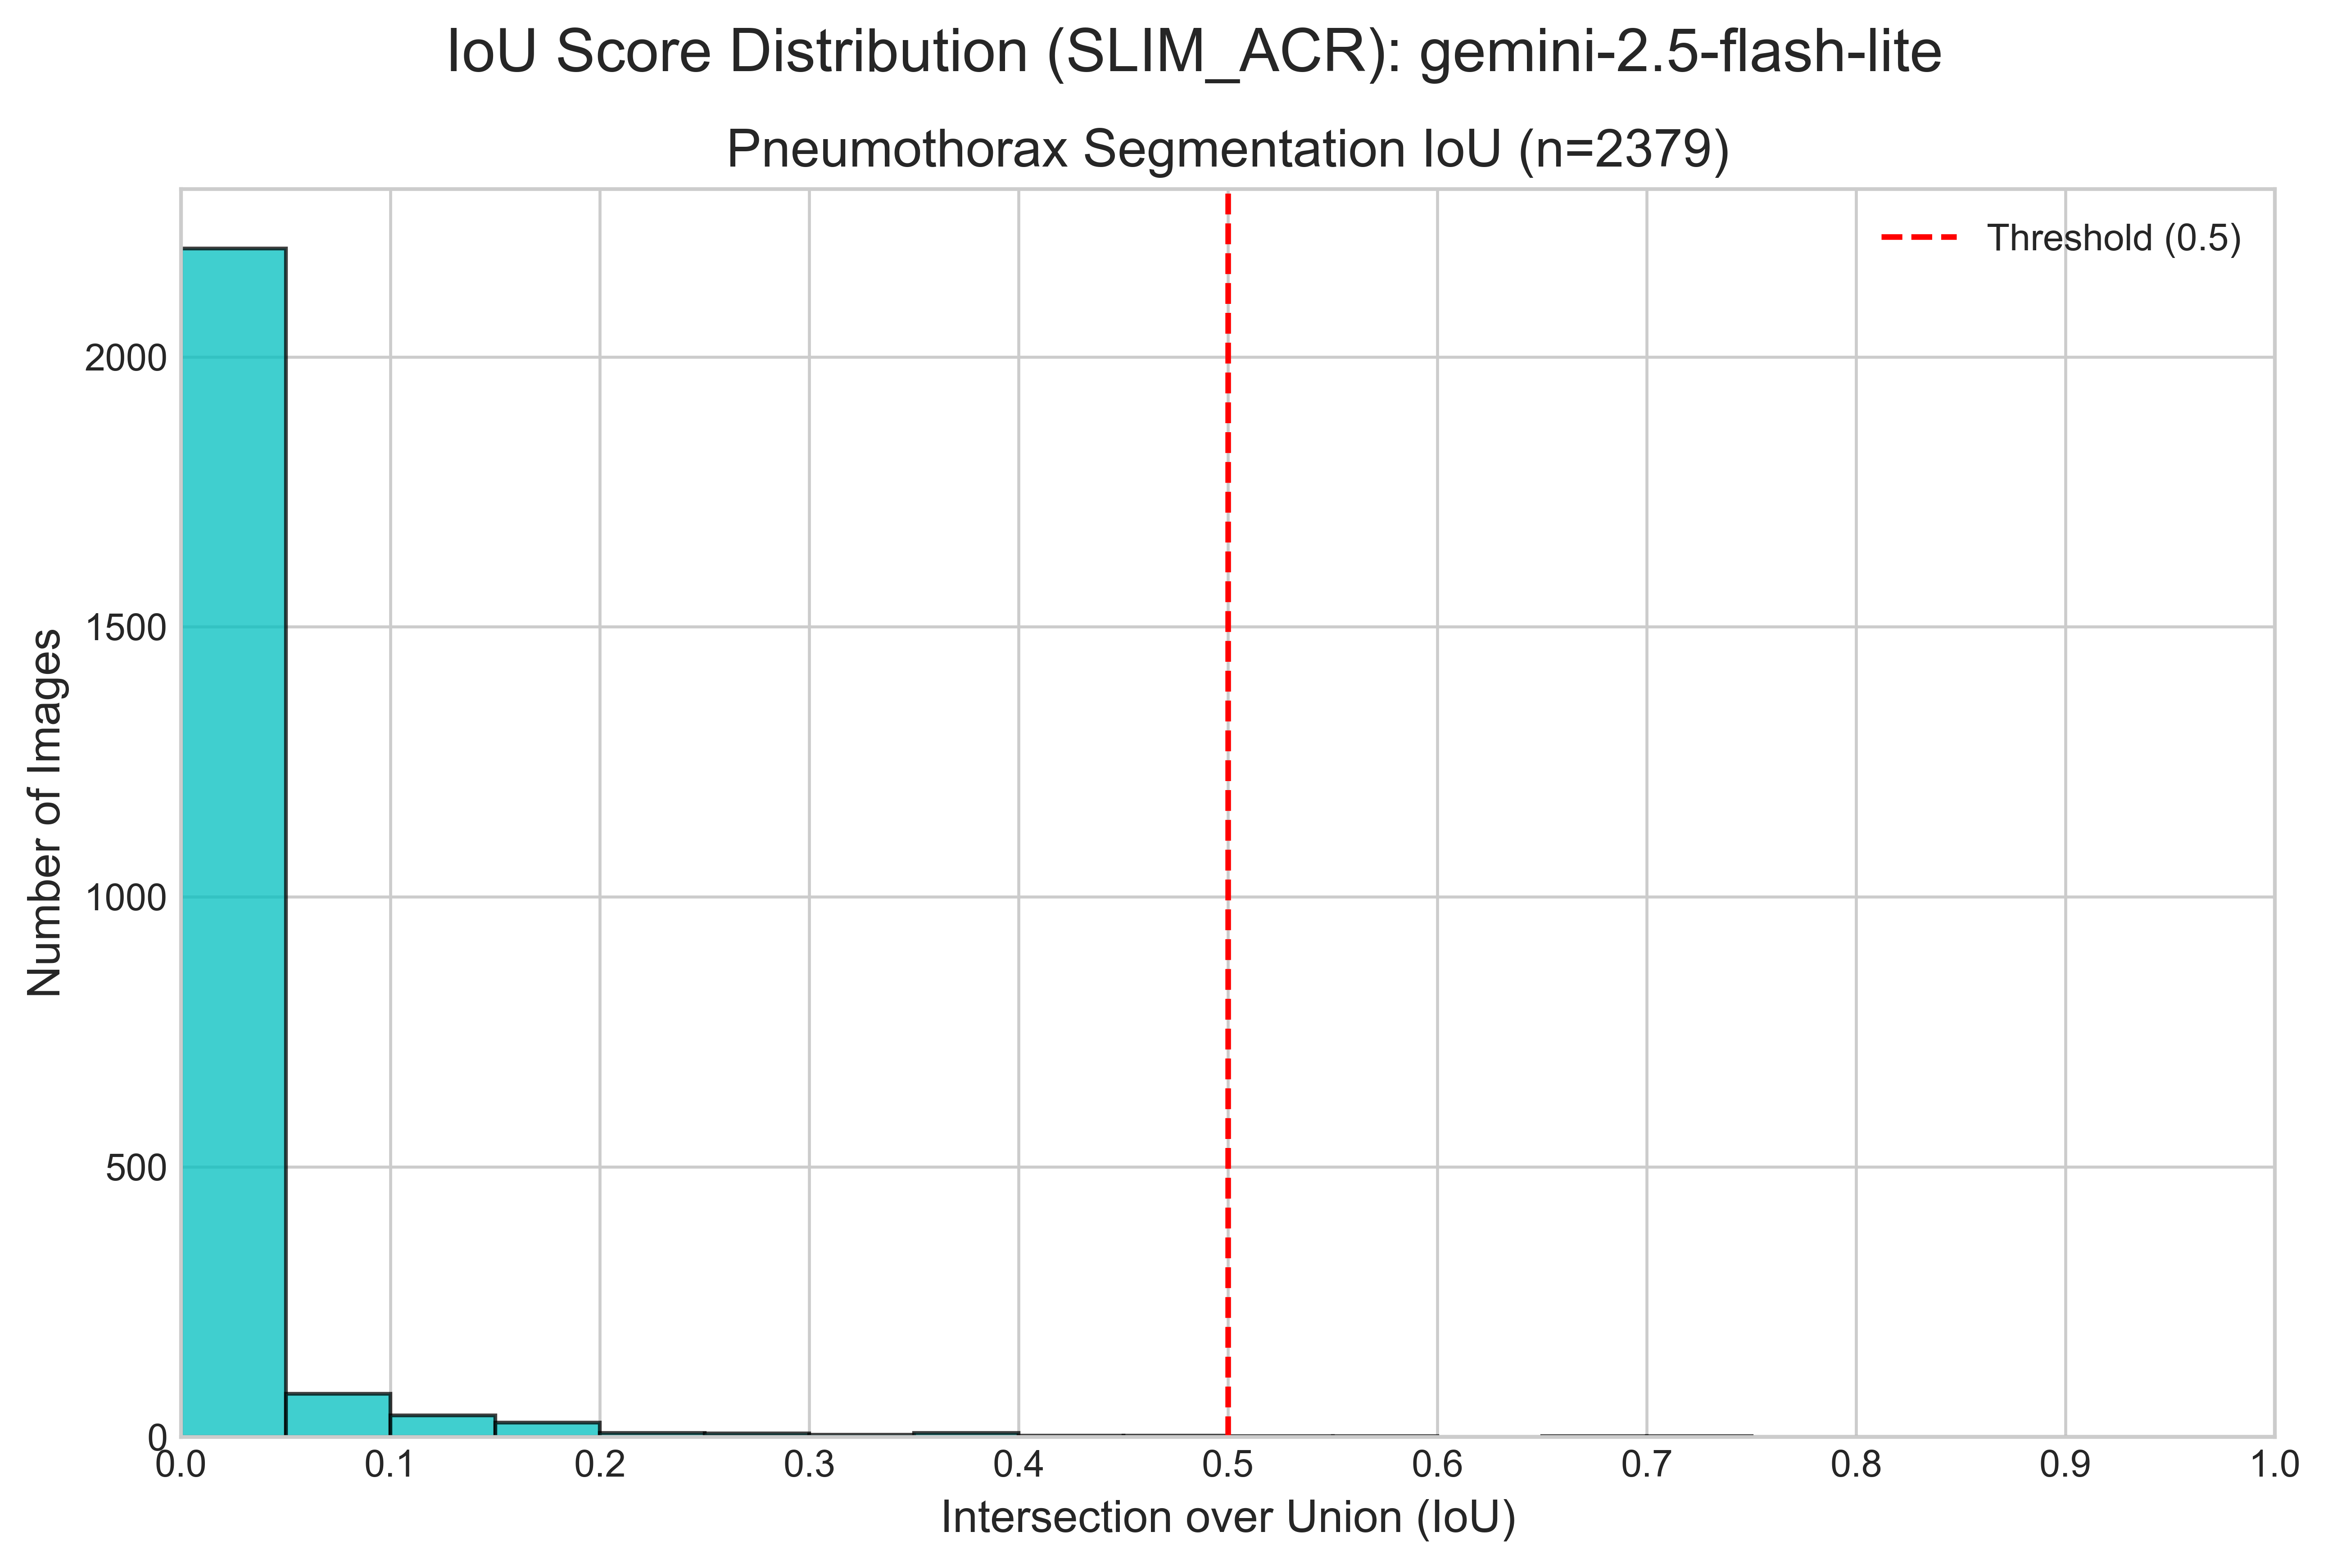

"\n✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.\n"

In [2]:
# %% [markdown]
"""
# 06 Pneumothorax Results Re-Analysis Tool (Multithreaded)

*Last sync 02 Aug 2025*

This notebook re-calculates and re-plots evaluation metrics from a completed run's
cached predictions for the SLIM_ACR pneumothorax segmentation task. It uses
multithreading to accelerate the processing of cached files.

**Instructions:**
1.  Ensure you have run the `04_Model_Evaluation_SLIM_ACR` notebook with
    `SAVE_PREDICTIONS = True`.
2.  Set the `MODEL_TO_ANALYZE` variable below to the model you want to inspect.
3.  Set the `NEW_LOW_IOU_THRESHOLD` to the desired value for defining a "successful" detection.
4.  Use the `EXCLUDE_LOW_IOU_FROM_STATS` toggle to control the analysis behavior:
    - `True`: (Default) Excludes low-IoU cases from summary statistics (mean, CI).
      The plot will still show all cases but with a red threshold line.
    - `False`: Includes all cases (even IoU=0) in summary statistics.
      This gives a view of performance across the entire dataset.
"""

# %%
# ---------- Preamble & Setup ----------
import sys, logging, os, subprocess, importlib.util, json, io, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple, List, Optional, Dict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Re-analysis notebook start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "pandas"):
    _ensure(extra)

# %%
# ---------- Dataset Path & Helper Functions ----------
# MODIFIED: Point to the SLIM_ACR pneumothorax dataset directory.
dataset_dir = Path("data/SLIM_ACR").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("SLIM_ACR dataset found at %s", dataset_dir)


def load_prediction_from_cache(prediction_path: Path, target_shape: Tuple[int, int]) -> np.ndarray:
    """
    Loads a cached prediction JSON, combines all masks into one, and returns a single boolean mask.
    """
    default_mask = np.zeros(target_shape, dtype=bool)
    if not prediction_path.exists():
        logging.error(f"Prediction cache file not found: {prediction_path}")
        return default_mask

    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return default_mask

    if not items:
        return default_mask # Return empty mask if prediction was empty list

    # Combine all predicted masks for the single class "pneumothorax"
    combined_mask_np = np.zeros(target_shape, dtype=bool)
    for item in items:
        try:
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)
            # Ensure mask is boolean and combine with logical OR
            combined_mask_np = np.logical_or(combined_mask_np, mask_np > 127)
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return combined_mask_np

def parse_ground_truth_mask(mask_path: Path) -> Tuple[Optional[np.ndarray], Tuple[int, int]]:
    """
    Parses a SLIM_ACR ground truth PNG file into a binarized boolean NumPy array.
    Returns the boolean mask and its shape.
    """
    try:
        mask_img = Image.open(mask_path).convert("L")
        mask_data = np.array(mask_img)
        return mask_data > 127, mask_data.shape
    except (FileNotFoundError, UnidentifiedImageError) as e:
        logging.error("Could not read ground truth mask file %s: %s", mask_path, e)
        return None, (0, 0)

# %%
# ---------- Metric Calculation Functions ----------

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0 # Perfect match if both are empty
    return np.sum(intersection) / np.sum(union)

def calculate_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates the Dice Coefficient for boolean masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred))
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: return 1.0 # Perfect match if both are empty
    return (2. * intersection) / (denominator + 1e-7) # Add epsilon for stability

def calculate_bootstrap_ci(data: List[float], n_resamples: int = 1000) -> Tuple[float, float]:
    """Calculates the 95% confidence interval for a list of numbers using bootstrapping."""
    if not data or len(data) < 2: return 0.0, 0.0
    bootstrapped_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    return np.percentile(bootstrapped_means, 2.5), np.percentile(bootstrapped_means, 97.5)

# %% [markdown]
"""
### Re-Analysis Execution

This section loads the cached predictions, recalculates all metrics in parallel, and then generates a new report and plot based on the parameters you set below.
"""

# %%
# ---------- Main Re-Analysis Loop ----------

# <<< --- PARAMETERS TO CONTROL THE RE-ANALYSIS --- >>>
MODEL_TO_ANALYZE = "gemini-2.5-flash-lite"
NEW_LOW_IOU_THRESHOLD = 0.5
EXCLUDE_LOW_IOU_FROM_STATS = False # Set to False to include all cases in stats/plots
MAX_WORKERS = os.cpu_count() or 4 # Use all available CPU cores, or default to 4

# --- Setup paths and find prediction files ---
model_name_safe = MODEL_TO_ANALYZE.replace("/", "_")
predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
if not predictions_dir.is_dir():
    raise FileNotFoundError(f"Predictions directory not found for model '{MODEL_TO_ANALYZE}'. Please run the evaluation script first with SAVE_PREDICTIONS=True.")

prediction_files = list(predictions_dir.glob("*.json"))
if not prediction_files:
    raise FileNotFoundError(f"No prediction files found in {predictions_dir}.")

logging.info(f"Found {len(prediction_files)} cached predictions for model '{MODEL_TO_ANALYZE}'.")
logging.info(f"Starting re-analysis with up to {MAX_WORKERS} threads.")

# --- Worker function for parallel processing ---
def process_single_prediction(pred_path: Path) -> Optional[Dict]:
    """Processes a single prediction file to calculate metrics for the SLIM_ACR dataset."""
    image_stem = pred_path.stem

    # MODIFIED: Construct the ground truth mask path using the SLIM_ACR naming convention.
    mask_path = dataset_dir / "mask" / f"{image_stem}.png"
    if not mask_path.exists():
        # Suppress logging for cleaner parallel output, return None on failure
        return None

    gt_mask, gt_shape = parse_ground_truth_mask(mask_path)
    if gt_mask is None:
        return None

    predicted_mask = load_prediction_from_cache(pred_path, target_shape=gt_shape)

    # Recalculate all metrics
    iou = calculate_iou(gt_mask, predicted_mask)
    dice = calculate_dice(gt_mask, predicted_mask)

    return {"image_path": mask_path.name, "iou": iou, "dice": dice}

# --- Recalculate metrics in parallel ---
recalculated_results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Use tqdm to show progress over the iterator returned by executor.map
    results_iterator = executor.map(process_single_prediction, prediction_files)
    for result in tqdm(results_iterator, total=len(prediction_files), desc=f"Re-analyzing {model_name_safe}"):
        if result is not None:
            recalculated_results.append(result)


# %% [markdown]
"""
### New Results Summary

The following report is generated from the recalculated metrics using your specified IoU threshold.
"""

# %%
# ---------- Aggregate, Display, and Save New Results ----------

if recalculated_results:
    df = pd.DataFrame(recalculated_results)

    # --- Determine which data to use for STATS based on the toggle ---
    if EXCLUDE_LOW_IOU_FROM_STATS:
        logging.info(f"Excluding cases with IoU < {NEW_LOW_IOU_THRESHOLD} from stats calculations.")
        runs_for_stats = df[df['iou'] >= NEW_LOW_IOU_THRESHOLD]
    else:
        logging.info("Including all cases (even IoU=0) in stats calculations.")
        runs_for_stats = df

    # --- Performance Metrics ---
    mean_iou = runs_for_stats['iou'].mean() if not runs_for_stats.empty else 0
    mean_dice = runs_for_stats['dice'].mean() if not runs_for_stats.empty else 0

    # --- Failure Analysis (based on the new threshold) ---
    total_runs = len(df)
    num_false_negatives = len(df[df['iou'] == 0])
    num_low_iou_failures = len(df[(df['iou'] > 0) & (df['iou'] < NEW_LOW_IOU_THRESHOLD)])

    # --- Confidence Intervals ---
    iou_ci = calculate_bootstrap_ci(runs_for_stats['iou'].tolist())
    dice_ci = calculate_bootstrap_ci(runs_for_stats['dice'].tolist())

    print("---" * 15)
    print(f"       Pneumothorax Segmentation Re-Analysis Report: {MODEL_TO_ANALYZE}")
    print("---" * 15)
    print(f"Total Cached Predictions Analyzed: {total_runs}")
    print(f"New IoU Threshold for Success:     {NEW_LOW_IOU_THRESHOLD}")
    print(f"Excluding Low IoU from Stats:      {EXCLUDE_LOW_IOU_FROM_STATS}")

    print("\n--- Performance Metrics ---")
    print(f"Mean IoU:                      {mean_iou:.4f} (95% CI: {iou_ci[0]:.4f} - {iou_ci[1]:.4f}) on {len(runs_for_stats)} images")
    print(f"Mean Dice Coefficient:         {mean_dice:.4f} (95% CI: {dice_ci[0]:.4f} - {dice_ci[1]:.4f})")

    print("\n--- Failure Analysis (New Threshold) ---")
    print(f"False Negatives (IoU=0): {num_false_negatives} ({num_false_negatives/total_runs:.1%})")
    print(f"Low IoU Failures:        {num_low_iou_failures} ({num_low_iou_failures/total_runs:.1%})")
    print("---" * 15)
    
    # --- Create and save summary dictionary ---
    summary_data = {
        "reanalysis_timestamp": datetime.now().isoformat(),
        "total_cached_predictions_analyzed": total_runs,
        "settings": {
            "model_analyzed": MODEL_TO_ANALYZE,
            "new_low_iou_threshold": NEW_LOW_IOU_THRESHOLD,
            "excluded_low_iou_from_stats": EXCLUDE_LOW_IOU_FROM_STATS,
        },
        "performance_metrics": {
            "mean_iou": mean_iou,
            "mean_dice": mean_dice,
            "mean_iou_95_ci": iou_ci,
            "mean_dice_95_ci": dice_ci,
            "num_images_in_stat_calc": len(runs_for_stats),
        },
        "failure_counts": {
            "false_negatives": num_false_negatives,
            "low_iou_failures": num_low_iou_failures,
        }
    }
    
    summary_path = dataset_dir / f"reanalysis_summary_slim_acr_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary_data, f, indent=4)
    logging.info(f"Saved re-analysis summary to {summary_path}")


    # --- Visualize and save the distribution of IoU scores ---
    # PLOT WILL ALWAYS SHOW ALL DATA, regardless of the stats toggle.
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
    fig.suptitle(f'IoU Score Distribution (SLIM_ACR): {MODEL_TO_ANALYZE}', fontsize=16)

    ax.hist(df['iou'], bins=20, range=(0,1), edgecolor='black', alpha=0.75, color='c')
    ax.set_title(f'Pneumothorax Segmentation IoU (n={total_runs})', fontsize=14)
    ax.set_xlabel('Intersection over Union (IoU)', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.axvline(NEW_LOW_IOU_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({NEW_LOW_IOU_THRESHOLD})')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

    plot_path = dataset_dir / f"reanalysis_iou_dist_slim_acr_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.png"
    plt.savefig(plot_path, bbox_inches='tight')
    logging.info(f"Saved re-analysis IoU plot to {plot_path}")
    plt.show()
else:
    print("No recalculated results were generated. Check if prediction files exist.")

# %% [markdown]
"""
✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.
"""
